---
>「計算の目的は洞察であって、数値ではない」
>
> リチャード・ハミング

---

# 異常音検知 — 機械の音から「いつもと違う」を見つける

本テキストでは、機械が出す音を使って異常を見つける仕組みを、自分の手で組み上げて評価するところまでを学ぶ

工場のポンプ、ファン、バルブ、搬送装置は、動いている間ずっと音を出している
熟練した保全担当者は、その音を聞いて「今日は何かおかしい」と気づく
本テキストの目標は、この「いつもと違う」という判断を、マイクと機械学習で置き換えることである

音の分類（G章）と似て見えるが、問題の立て方が大きく異なる
- 分類では、当てたいクラスの音がすべて手元にある
- 異常検知では、**異常の音がほとんど手元にない** 壊れた機械の音を集めるには、機械を壊すしかないからである
- そのため、**正常な音だけで学習し、そこから外れたものを異常とみなす**という方針をとる

本テキストでは以下を扱う

1. **問題設定**: なぜ音か、分類と何が違うか、現場で何が難しいか
2. **機械音の見方**: 回転数と高調波、欠陥が出る帯域、特徴量の設定が異常の見え方をどう変えるか
3. **古典的な外れ値検知**: 統計量とマハラノビス距離、Isolation Forest、混合ガウスモデル
4. **AutoEncoderによる再構成誤差**: 基準となる深層学習の手法と、その弱点
5. **識別型の手法**: 機械の個体を当てる補助タスクで表現を学ぶ
6. **事前学習済みの音響モデル**: 学習なしでどこまで検知できるか
7. **評価**: AUC、部分AUC、しきい値の決め方、全手法の比較
8. **判断の根拠の可視化**: どの時間、どの周波数が効いたか
9. **現場への導入**: ドメインシフト、自分で録音したデータ、逐次処理、軽量化、運用

前提とする知識は次のとおりである
- メルスペクトログラムと短時間フーリエ変換（G章を参照）
- AutoEncoder（B章を参照）
- 混同行列、ROC曲線、AUC（「機械学習の基礎」の章を参照）
- 転移学習（C章を参照）

---

# この講義でできるようになること

- 異常検知を、分類ではなく「正常だけで学習する問題」として設計できるようになる
- 機械音のスペクトログラムを見て、回転成分、高調波、衝撃音を読み分けられるようになる
- 公開データに対して、古典的な手法から事前学習済みモデルまでの検知器を実装し、同じ条件で比較できるようになる
- AUCと部分AUCで性能を測り、誤報率からしきい値を決められるようになる
- 自分で録音した機械音を同じ手順に流し、結果を考察できるようになる
- 雑音や運転条件が変わったときに何が起きるかを理解し、対処を選べるようになる

# 全体像

異常音検知の仕組みは、どの手法でも次の流れになる

1. **録音**: マイクで機械の音を録る
2. **特徴量の計算**: 波形を対数メルスペクトログラムなどに変換する
3. **正常のモデル化**: 正常な音だけを使い、「正常とはどういう音か」を表すモデルを作る
4. **異常スコアの計算**: 新しい音が正常のモデルからどれだけ外れているかを、1つの数値で表す
5. **しきい値による判定**: スコアがしきい値を超えたら異常と判定する
6. **評価と運用**: 誤報と見逃しを測り、しきい値とモデルを見直す

<img src="https://class.west.sd.keio.ac.jp/dataai/text/asd-overview.png" width=750>

上の図は、この流れを1枚にまとめたものである
- 学習のときに正常な音から作るのは、中央の「正常のモデル」だけである
- 運用のときは、新しい音を同じ手順で特徴量にし、正常のモデルからの外れ具合を異常スコアとして出す

本テキストで比べる手法は、3の「正常のモデル化」が異なるだけである
- 1、2、4、5、6は共通の部品として1回だけ作り、すべての手法で使い回す
- こうしておくと、手法の差だけを公平に比べられる

本テキストは4部で構成する

| 部 | 内容 | 使うデータ |
| --- | --- | --- |
| 第1部 | 問題設定 | 小さな人工データ |
| 第2部 | 機械音の見方と特徴量 | 合成した機械音 |
| 第3部 | 手法を作って比べる | 公開データ（ポンプとバルブの音） |
| 第4部 | 現場に入れる | 公開データと自分で録音した音 |

第3部は約2GBのデータを取得する
- Colabでは、ランタイムのタイプをGPU（T4）にしてから実行する GPUが無いと最初のコードセルで止まる
- 対数メルスペクトログラムを全ファイル分メモリに持つので、RAMは最大で約10GB使う（検証環境での実測） 無料枠（約12.7GB）で動く
- 実行に長くかかる確認実験は、コードを説明の中に載せて、実行結果もそのまま示してある 動かすことより、結果を読むことが目的である
- 上から順に実行する 後ろのセルは前のセルで作った変数を使う

---

# 第1部 問題設定

# なぜ音で異常を検知するのか

機械の状態を知る方法には、振動、温度、電流、油の分析、音などがある
この中で音を選ぶ理由は、次の3点である

- **非接触である**
  - マイクは機械から離して置ける
  - 高温の場所、回転している部分、衛生上触れられない場所でも使える
- **後付けできる**
  - 機械を止めて加工したり、配線を引き回したりする必要がない
  - 古い設備にも、1台のマイクを置くだけで始められる
- **内部の状態が音に出る**
  - 軸受の傷、ギアの欠け、ベルトのゆるみ、弁の固着、羽根の汚れは、いずれも振動を変え、その振動が空気を伝わって音になる
  - 1本のマイクが、複数の部品や複数の機械をまとめて拾う

## 振動センサとの違い

機械の診断で最も実績があるのは、振動センサ（加速度センサ）である
音による検知は振動の代わりではなく、得意な場面が異なると考えるとよい

| 観点 | 振動センサ | マイク（音） |
| --- | --- | --- |
| 取り付け | 機械に固定する 取り付け位置と固定の仕方で信号が変わる | 離して置く 設置は容易 |
| 拾う範囲 | 取り付けた部品の近くだけ | 周囲の広い範囲 |
| 周囲の雑音 | 受けにくい | 受けやすい 隣の機械、人の声、空調の音が混ざる |
| 信号の強さ | 欠陥の信号を直接拾うので強い | 空気を伝わる間に弱まり、反射も混ざる |
| 台数が多いとき | センサの数が増える | 1本で複数台を見られることがある |

- 振動センサは「どの部品が、どう壊れかけているか」を調べる**精密な診断**に向く
- 音は「この一帯で何かがいつもと違う」に気づく**簡易な監視**に向く
- 音の最大の弱点は**雑音**である 本テキストの後半は、この弱点とどう付き合うかに多くを割く

# 異常検知が分類と違う点

G章では、犬の鳴き声や雨音など50種類の音を分類した
同じやり方で「正常」と「異常」の2クラス分類を作ればよい、と考えたくなるが、うまくいかない
理由は3つある

- **異常の音がほとんど集まらない**
  - 機械はめったに壊れない 壊れる前に保全するのが普通である
  - 正常の音が数千個あるのに、異常の音は0個か数個、という状況から始まる
- **未知の異常が来る**
  - 壊れ方は1通りではない 軸受、ギア、ベルト、異物の混入、取り付けのゆるみ
  - 過去に起きた異常を学習しても、次に起きる異常は別の種類かもしれない
- **異常を人工的に作るのは難しい**
  - わざと壊した機械の音は取れるが、費用がかかり、実際の故障と同じとは限らない

そこで、次の設定をとる

- 学習に使うのは**正常な音だけ**
- 学習したモデルは、新しい音に対して**異常スコア**（anomaly score）という1つの数値を出す
  - 正常に近ければ小さく、正常から外れていれば大きい
- スコアが**しきい値**（threshold）を超えたら異常と判定する

<img src="https://class.west.sd.keio.ac.jp/dataai/text/asd-classification-vs-detection.png" width=700>

上の図の左が分類、右が異常検知である
- 分類は「正常と既知の異常を分ける境界」を学ぶので、境界の正常側に現れた未知の異常を見逃す
- 異常検知は「正常が占める領域」だけを学ぶので、その外に出たものは種類を問わず異常になる

この設定を**教師なし異常検知**（unsupervised anomaly detection）、または**1クラス分類**（one-class classification）と呼ぶ
- 「教師なし」といっても、「学習データはすべて正常である」という情報は使っている
- B章のAutoEncoderによる異常検知や、H章のEfficient GANによる異常検知も、同じ設定である

## 分類器は未知の異常を見逃す

2次元の人工データで、この違いを確かめる
- 正常データと、既知の異常A（右上にずれる）を用意する
- 分類器は、正常と異常Aを使って学習する
- 1クラスの検知器は、正常だけを使い、正常の中心からの距離をスコアにする
- 最後に、学習時には存在しなかった異常B（左上にずれる）を両方に入力する

normal               classifier says anomaly:  0.0%   one-class says anomaly:  0.8%
anomaly A (known)    classifier says anomaly: 100.0%   one-class says anomaly: 100.0%
anomaly B (unknown)  classifier says anomaly:  0.0%   one-class says anomaly: 100.0%


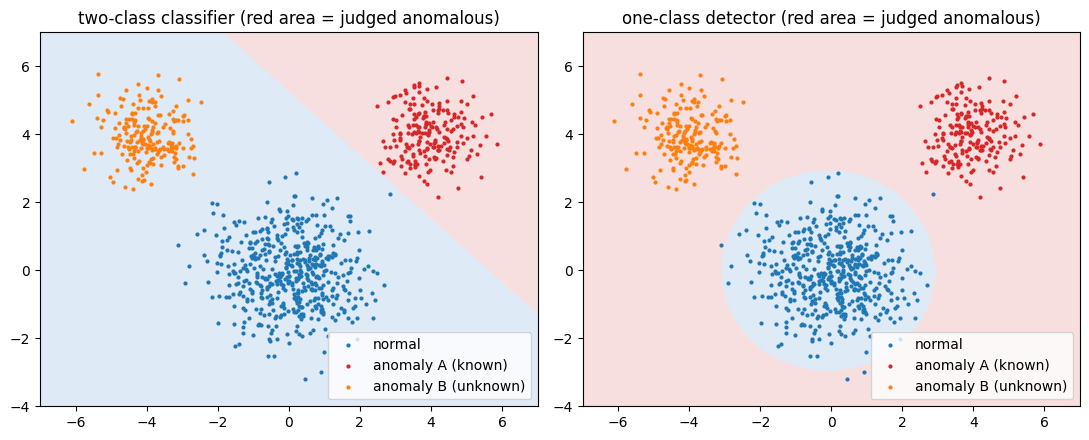

In [1]:
# 2次元の人工データで、2クラス分類と1クラス検知を比べる（未知の異常Bをどちらが見つけるか）
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

rng = np.random.default_rng(0)
normal_tr = rng.normal([0, 0], 1.0, (500, 2))
anom_a_tr = rng.normal([4, 4], 0.7, (20, 2))      # 既知の異常A（学習に使える数は少ない）
normal_te = rng.normal([0, 0], 1.0, (500, 2))
anom_a_te = rng.normal([4, 4], 0.7, (200, 2))
anom_b_te = rng.normal([-4, 4], 0.7, (200, 2))    # 未知の異常B（学習時には存在しない）

# 2クラス分類: 正常と異常Aで学習する
clf = LogisticRegression().fit(np.r_[normal_tr, anom_a_tr], np.r_[np.zeros(500), np.ones(20)])
# 1クラス検知: 正常だけから中心と広がりを求め、中心からの距離が正常の99%点を超えたら異常とする
mu, sd = normal_tr.mean(0), normal_tr.std(0)
dist = lambda X: np.sqrt((((X - mu) / sd) ** 2).sum(1))
thr = np.quantile(dist(normal_tr), 0.99)

for name, X in [("normal", normal_te), ("anomaly A (known)", anom_a_te), ("anomaly B (unknown)", anom_b_te)]:
    print(f"{name:20s} classifier says anomaly: {clf.predict(X).mean():5.1%}   one-class says anomaly: {(dist(X) > thr).mean():5.1%}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
gx, gy = np.meshgrid(np.linspace(-7, 7, 200), np.linspace(-4, 7, 200))
G = np.c_[gx.ravel(), gy.ravel()]
for a, Z, title in [(ax[0], clf.predict_proba(G)[:, 1] > 0.5, "two-class classifier"), (ax[1], dist(G) > thr, "one-class detector")]:
    a.contourf(gx, gy, Z.reshape(gx.shape), levels=[-0.5, 0.5, 1.5], colors=["#dfeaf7", "#f7dfdf"])
    a.scatter(*normal_te.T, s=4, c="tab:blue", label="normal")
    a.scatter(*anom_a_te.T, s=4, c="tab:red", label="anomaly A (known)")
    a.scatter(*anom_b_te.T, s=4, c="tab:orange", label="anomaly B (unknown)")
    a.set_title(title + " (red area = judged anomalous)"); a.legend(loc="lower right")
plt.tight_layout(); plt.show()

結果の読み方

- 分類器は、既知の異常Aをほぼすべて見つけるが、未知の異常Bは見逃す
  - 分類器が学習するのは「正常と異常Aを分ける境界線」である
  - 異常Bは、その境界線に対して正常の側にあるので、正常と判定される
- 1クラスの検知器は、AもBも見つける
  - 学習するのは「正常が占める領域」であり、その外に出たものは、種類を問わず異常になる
- 代わりに、1クラスの検知器は正常の約1%を異常と判定する
  - しきい値を正常の99%点に置いたからである
  - しきい値を上げれば誤報は減るが、正常の近くに現れる異常を見逃す

この「誤報と見逃しの釣り合いを、しきい値で決める」という構造は、本テキストのすべての手法に共通する

## 異常スコアとしきい値を分けて考える

異常検知の仕組みは、2つの部品に分けて考える

- **スコアを作る部品**: 正常と異常を、数値の大小でどれだけきれいに並べられるか
  - これはAUCで測る（しきい値に依存しない）
- **しきい値を決める部品**: 並べたものの、どこで線を引くか
  - これは誤報をどれだけ許せるか、という現場の事情で決まる

第3部では、まずスコアを作る部品を何通りも作ってAUCで比べ、その後でしきい値の決め方を扱う

<img src="https://class.west.sd.keio.ac.jp/dataai/text/asd-score-threshold.png" width=600>

上の図は、2つの部品の関係を表している
- スコアを作る部品の良し悪しは、正常と異常の2つの山がどれだけ離れているかで決まる
- しきい値を決める部品は、山が重なった部分のどこに線を引くかを決める 線の右に出た正常が誤報、線の左に残った異常が見逃しである

# 現場で起きる難しさ

研究用のデータで高い性能が出ても、現場に持ち込むと性能が落ちることが多い
原因はほぼ決まっている

- **環境雑音**
  - 工場には、他の機械、空調、フォークリフト、人の声、警報音がある
  - 対象の機械の音より雑音の方が大きいこともある
  - 雑音が変わっただけで「正常から外れた」と判定してしまう
- **機種や個体の差**
  - 同じ型番のポンプでも、1台ずつ音が違う 取り付け、配管、経年が異なるためである
  - ある個体で作った正常のモデルは、別の個体にはそのまま使えないことが多い
- **運転条件の変化**
  - 回転数、負荷、流す液体、気温が変わると、正常な音そのものが変わる
  - 学習時と運用時でデータの分布が変わることを**ドメインシフト**（domain shift）と呼ぶ
  - 異常検知は「学習時と違う」ことを検知する仕組みなので、ドメインシフトと異常を原理的に区別しにくい
- **マイクの位置と種類**
  - マイクを10cm動かす、別の製品に替える、だけで周波数特性と音量が変わる
  - 保全作業の後でマイクの位置が少しずれた、というのは実際によく起きる

これらに共通するのは、**「正常」の範囲が、思っているより広く、しかも動く**ということである
- 第3部では、まず条件のそろった公開データで手法の基本を押さえる
- 第4部で、条件を変えたときに何が起きるかを実験し、対処を試す

<img src="https://class.west.sd.keio.ac.jp/dataai/text/asd-field-difficulties.png" width=700>

上の図のとおり、これらはどれも機械が正常なまま、マイクに届く音だけを変える

---

# 第2部 音の見方（機械音に特化）

# 機械音の特徴

G章では、犬の鳴き声や雨音のような環境音を扱った
機械の音は、それらと比べて**構造がはっきりしている**
機械は決まった速さで同じ動きを繰り返すので、音にもその周期がそのまま現れるからである

## 回転数と高調波

モータ、ポンプ、ファンのような回転機械では、軸が1秒間に回る回数が音の基本になる

- 回転数が毎分 $N$ 回転（rpm）のとき、**回転周波数**は $f_r = N / 60$ [Hz] である
  - 1800 rpm なら $f_r = 30$ Hz
- 軸の重心がわずかにずれている（不釣り合い）と、1回転に1回の力がかかり、$f_r$ の成分が出る
- 実際の振動は正弦波からゆがむので、$2f_r, 3f_r, \dots$ の**高調波**（harmonics）も出る
- 回転に同期した部品は、$f_r$ の整数倍の位置に成分を作る
  - 歯数 $Z$ のギア: **かみ合い周波数** $Z f_r$
  - 羽根が $B$ 枚のファンやポンプ: **羽根通過周波数** $B f_r$
- かみ合い周波数の両側には、$f_r$ だけ離れた位置に**側帯波**（sideband）が出る
  - かみ合いの強さが1回転の周期でゆらぐ（振幅変調される）ためである

つまり、正常な回転機械のスペクトルは、**$f_r$ で決まる位置に線が並んだ形**になる
スペクトログラムでは、時間方向に伸びた横縞として見える

<img src="https://class.west.sd.keio.ac.jp/dataai/text/asd-machine-spectrum.png" width=700>

上の図は、回転機械のスペクトルの成り立ちを模式的に描いたものである
- 左端の線の並びが回転周波数と高調波、中央がかみ合い周波数と側帯波である
- 右の盛り上がりは、次に述べる軸受の傷で現れる共振帯域である

## 欠陥はどこに出るか

| 欠陥 | 音の変化 | 現れる場所 |
| --- | --- | --- |
| 不釣り合い、軸のずれ | 回転周波数とその高調波の強さが変わる | 低い周波数（$f_r$ の数倍まで） |
| ギアの摩耗、欠け | かみ合い周波数の側帯波が増える | かみ合い周波数の周辺 |
| 軸受の傷 | 傷を転動体が通るたびに小さな衝撃が起き、機械の構造が共振して鳴る | 数kHzの共振帯域 衝撃の周期は低い |
| 回転数の変化（負荷、すべり） | すべての線が同じ比率でずれる | 全体 |
| 異物、こすれ、漏れ | 広い帯域の雑音が増える、不規則な突発音が出る | 高い周波数まで広く |

軸受の傷は、少し説明が要る
- 外輪に傷があると、転動体（玉）が傷の上を通るたびに衝撃が起きる
- 衝撃が起きる周波数は、軸受の寸法で決まる 外輪の傷の場合は次の式になる

$$ f_{\mathrm{BPFO}} = \frac{n}{2} f_r \left(1 - \frac{d}{D}\cos\phi\right) $$

- $n$ は転動体の数、$d$ は転動体の直径、$D$ は転動体の中心が描く円の直径、$\phi$ は接触角である
- BPFOは ball pass frequency of the outer race の略である
- $n=9$、$d/D=0.207$、$\phi=0$ なら $f_{\mathrm{BPFO}} = 3.57 f_r$ となる 整数倍にならないのが特徴である
- 1回の衝撃は短く弱いが、機械の構造を「たたく」ので、数kHzの共振が短く鳴る
- したがって、**高い帯域に、低い周期で繰り返す衝撃音**として現れる

<img src="https://class.west.sd.keio.ac.jp/dataai/text/asd-bearing-impact.png" width=650>

上の図は、軸受の傷による音を時間の波形として描いたものである
- 細かく振動しているのが共振の音（数kHz）で、それが衝撃のたびに鳴っては減衰する
- 外形をなぞった線（包絡線）は、衝撃の間隔 $1/f_{\mathrm{BPFO}}$ で繰り返す この見方は、後のエンベロープ解析で使う

## 定常音と突発音

機械音は、時間的な性質で2つに分けられる

- **定常音**: ファン、ポンプ、モータのように、同じ音が鳴り続ける
  - どの時刻を切り出しても似ている 時間方向に平均しても情報が失われにくい
- **突発音**（非定常音）: バルブの開閉、スライダの往復、プレスのように、短い音が間をおいて鳴る
  - 鳴っている時間は全体のごく一部である 時間方向に平均すると薄まる
  - 異常が「鳴るべきときに鳴らない」「鳴り方が違う」という形で現れる

<img src="https://class.west.sd.keio.ac.jp/dataai/text/asd-stationary-vs-transient.png" width=680>

上の図は、2種類の音のスペクトログラムを模式的に描いたものである
- 定常音では、異常による変化（赤）が全時間にわたって現れるので、時間方向に平均しても残る
- 突発音では、異常による変化は短い時間にしか現れないので、平均すると薄まる

この違いは、第3部で手法の得意、不得意としてはっきり現れる
- 本テキストの実習では、定常音の代表としてポンプ、突発音の代表としてバルブを使う

## 機械音を合成して確かめる

実際の録音を見る前に、中身がわかっている音を自分で合成して、欠陥がどう見えるかを確かめる
合成するのは、次の成分を足し合わせた音である

- 回転周波数30Hzとその高調波（5次まで）
- かみ合い周波数600Hz（歯数20）と、その側帯波
- 広帯域の雑音（低域ほど強い）

これに、欠陥を模した3種類の変化を加える

- `bearing`: 軸受外輪の傷 $3.57 f_r \approx 107$ Hz の周期で衝撃が起き、3kHzの共振が短く鳴る
- `harmonic`: 2次と3次の高調波が強まる（軸のずれを想定）
- `shift`: 回転数が3%下がる（負荷の増加を想定）

まず、本書を通して使うライブラリと、対数メルスペクトログラムを計算する関数を用意する
- メルスペクトログラムの考え方はG章を参照
- G章では `librosa.feature.melspectrogram` を使ったが、ここでは後でGPUでまとめて計算するために、`torch.stft` とメルフィルタバンクの積として自分で書く

In [2]:
# 本書を通して使うライブラリを読み込み、乱数シードと計算デバイスを決める
import os, glob, math, time, shutil, subprocess, zipfile
from concurrent.futures import ThreadPoolExecutor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.signal as sps
import scipy.stats as spstats
import soundfile as sf
import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, roc_curve

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True     # 同じ環境で実行し直したときに、学習結果ができるだけ変わらないようにする
torch.backends.cudnn.benchmark = False
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SR = 16000   # 本書で扱う音のサンプリング周波数 [Hz]
print("device:", device)
assert device.type == "cuda", "GPUが見つからない  Colabでは「ランタイム」→「ランタイムのタイプを変更」→「T4 GPU」を選んでから、最初から実行し直す"


device: cuda


In [3]:
# 対数メルスペクトログラムを計算する関数を作る（STFT → パワー → メルフィルタバンク → dB）
def make_logmel(n_fft=1024, hop=512, n_mels=128, sr=SR):
    fb = torch.tensor(librosa.filters.mel(sr=sr, n_fft=n_fft, n_mels=n_mels), dtype=torch.float32)
    win = torch.hann_window(n_fft)
    def f(x):
        # x: (バッチ, サンプル数) のテンソル  戻り値: (バッチ, メル数, フレーム数) [dB]
        X = torch.stft(x, n_fft, hop, window=win.to(x.device), return_complex=True).abs() ** 2
        return 10 * torch.log10(fb.to(x.device) @ X + 1e-10)
    return f

def logmel_np(x, **kw):
    # numpyの1次元波形を受け取り、(メル数, フレーム数) のnumpy配列を返す
    return make_logmel(**kw)(torch.from_numpy(np.asarray(x, dtype=np.float32))[None])[0].numpy()

In [4]:
# 回転機械の音を合成する関数（回転成分＋ギアのかみ合い成分＋雑音）と、欠陥を模した3種類の変化
F_ROT = 30.0     # 軸の回転周波数 [Hz]（1800 rpm）
N_TEETH = 20     # ギアの歯数  かみ合い周波数は N_TEETH × F_ROT = 600 Hz
BPFO = 3.57      # 軸受外輪の欠陥が1回転あたりに起こす衝撃の回数（軸受の寸法で決まる）
F_RES = 3000.0   # 衝撃でたたかれて鳴る、構造の共振周波数 [Hz]

def synth_machine(dur=4.0, fault=None, level=1.0, rng=None, sr=SR):
    # fault: None（正常） "bearing"（周期的な衝撃） "harmonic"（高調波の変化） "shift"（周波数のずれ）
    rng = np.random.default_rng(0) if rng is None else rng
    t = np.arange(int(dur * sr)) / sr
    fr = F_ROT * (1 + 0.003 * rng.standard_normal())           # 個々の録音で回転数は少しゆらぐ
    if fault == "shift":
        fr *= 1 - 0.03 * level                                 # 回転数が3%下がる
    amp = np.array([1.0, 0.5, 0.3, 0.2, 0.1]) * (1 + 0.1 * rng.standard_normal(5))
    if fault == "harmonic":
        amp[1:3] *= 1 + 1.5 * level                            # 2次と3次の高調波が強まる
    x = sum(a * np.sin(2 * np.pi * (k + 1) * fr * t + rng.uniform(0, 2 * np.pi)) for k, a in enumerate(amp))
    # ギアのかみ合い成分と、回転周波数だけ離れた側帯波
    fm = N_TEETH * fr
    x += 0.4 * np.sin(2 * np.pi * fm * t) * (1 + 0.3 * np.sin(2 * np.pi * fr * t))
    # 広帯域の雑音（低域ほど強い）
    noise = sps.lfilter([1], [1, -0.9], rng.standard_normal(len(t)))
    x += 0.15 * (1 + 0.1 * rng.standard_normal()) * noise
    if fault == "bearing":
        # 欠陥を転動体が通過するたびに衝撃が起き、共振が短く鳴って減衰する
        period = 1 / (BPFO * fr)
        hits = np.arange(0, dur, period) + 0.02 * period * rng.standard_normal(int(np.ceil(dur / period)))
        tt = np.arange(int(0.01 * sr)) / sr
        burst = np.exp(-tt / 0.001) * np.sin(2 * np.pi * F_RES * tt)
        imp = np.zeros(len(t))
        imp[np.clip((hits * sr).astype(int), 0, len(t) - 1)] = 1 + 0.2 * rng.standard_normal(len(hits))
        x += 0.5 * level * np.convolve(imp, burst)[:len(t)]
    return (0.1 * x).astype(np.float32)

FAULTS = [None, "bearing", "harmonic", "shift"]
demo = {str(f): synth_machine(fault=f, rng=np.random.default_rng(1)) for f in FAULTS}
print({k: v.shape for k, v in demo.items()})

{'None': (64000,), 'bearing': (64000,), 'harmonic': (64000,), 'shift': (64000,)}


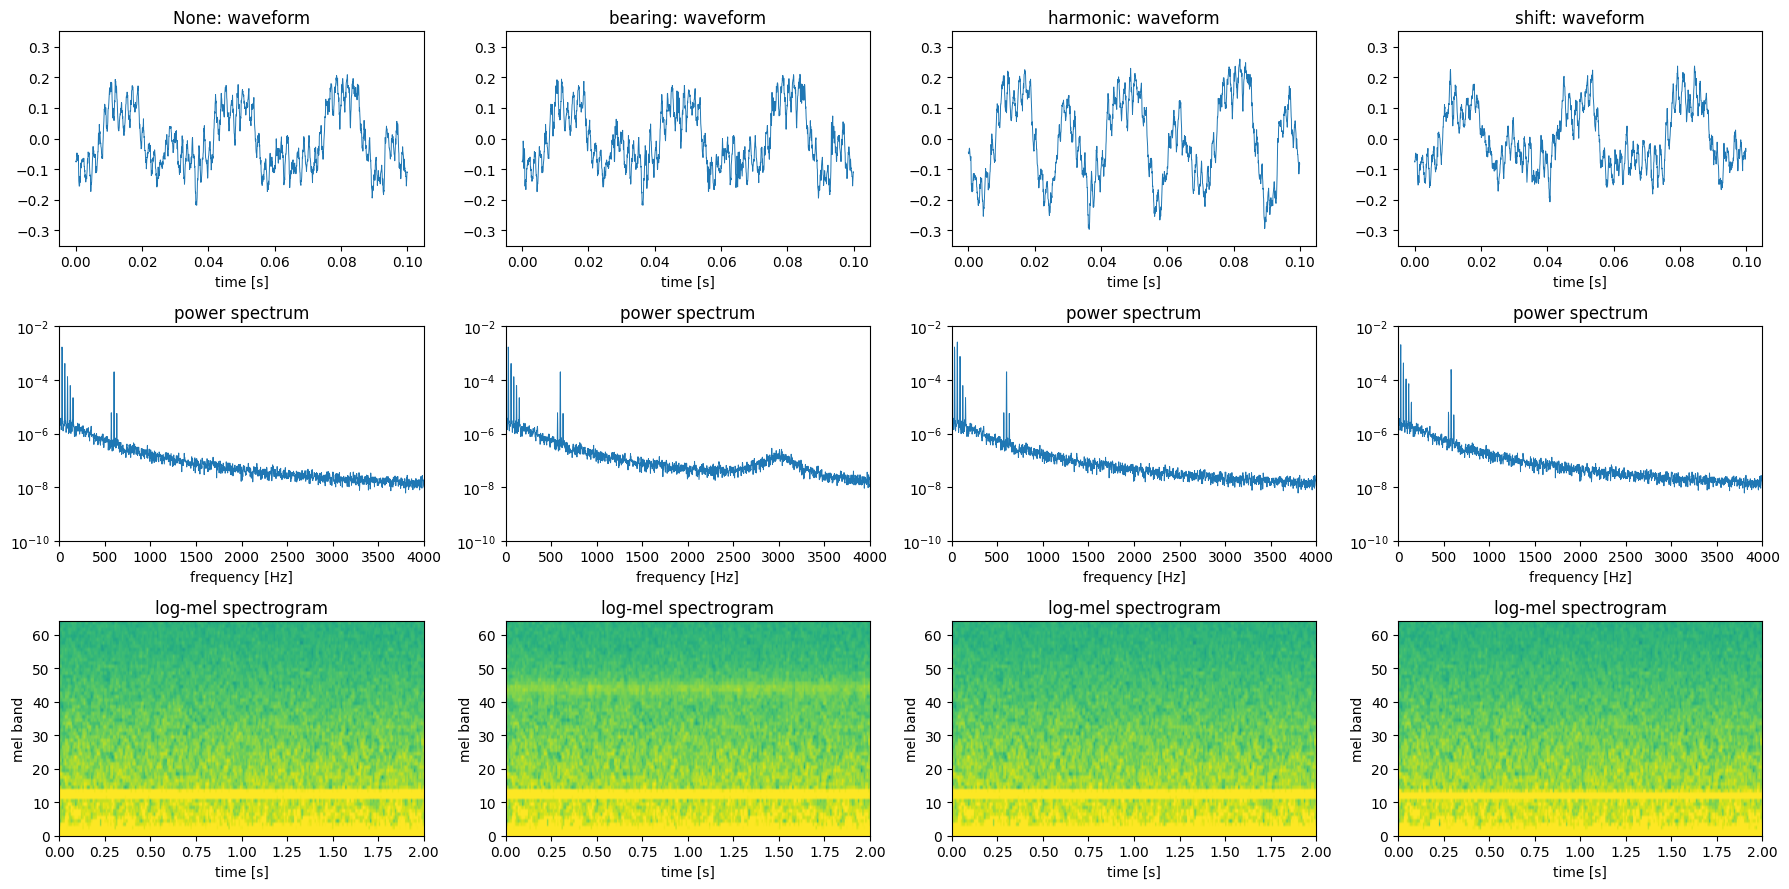

In [5]:
# 正常と3種類の欠陥について、波形（0.1秒分）、スペクトル、スペクトログラムを並べて見る
fig, ax = plt.subplots(3, 4, figsize=(18, 9))
for j, (name, x) in enumerate(demo.items()):
    ax[0, j].plot(np.arange(1600) / SR, x[:1600], lw=0.7)
    ax[0, j].set_title(f"{name}: waveform"); ax[0, j].set_xlabel("time [s]"); ax[0, j].set_ylim(-0.35, 0.35)
    f, P = sps.welch(x, SR, nperseg=8192)
    ax[1, j].semilogy(f, P, lw=0.7); ax[1, j].set_xlim(0, 4000); ax[1, j].set_ylim(1e-10, 1e-2)
    ax[1, j].set_title("power spectrum"); ax[1, j].set_xlabel("frequency [Hz]")
    S = logmel_np(x, n_fft=512, hop=128, n_mels=64)
    ax[2, j].imshow(S[:, :250], origin="lower", aspect="auto", vmin=-80, vmax=-10, extent=[0, 250 * 128 / SR, 0, 64])
    ax[2, j].set_title("log-mel spectrogram"); ax[2, j].set_xlabel("time [s]"); ax[2, j].set_ylabel("mel band")
plt.tight_layout(); plt.show()

図の読み方

- 上段（波形）
  - どの状態も、30Hz（周期約33ms）の大きなうねりに細かい振動が乗っている
  - `harmonic` は振幅が大きくなり、形も変わるので波形でわかる
  - `bearing` と `shift` は、波形を見ても正常と区別がつかない
- 中段（スペクトル）
  - 左端の線の集まりが回転周波数と高調波、600Hzの線がかみ合い周波数である
  - `bearing` では、3kHzの周辺がなだらかに盛り上がる 共振が鳴っている帯域である
  - `harmonic` と `shift` の違いは、この縮尺では見えない
- 下段（対数メルスペクトログラム）
  - 回転成分とかみ合い成分が、横縞として見える
  - `bearing` では、高い帯域に新しい横縞が加わる
  - メル尺度は高い周波数ほど帯域が広いので、低域の細かい線は1本の太い縞にまとまる

低い周波数を拡大して、`harmonic` と `shift` の違いを確かめる

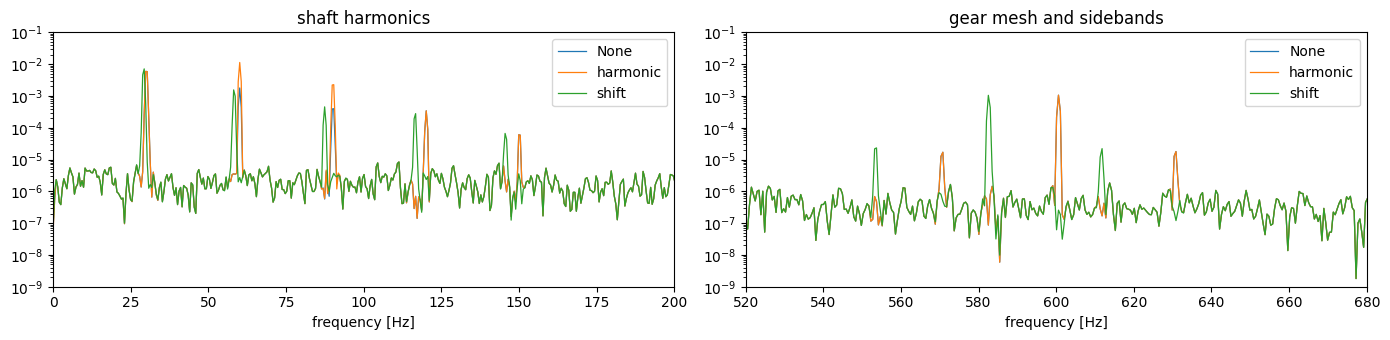

In [6]:
# 低い周波数を拡大して、高調波の変化と周波数のずれを確かめる
fig, ax = plt.subplots(1, 2, figsize=(14, 3.5))
for name in ["None", "harmonic", "shift"]:
    f, P = sps.welch(demo[name], SR, nperseg=32768)
    ax[0].semilogy(f, P, lw=0.9, label=name)
    ax[1].semilogy(f, P, lw=0.9, label=name)
ax[0].set_xlim(0, 200); ax[1].set_xlim(520, 680)
for a in ax:
    a.set_ylim(1e-9, 1e-1); a.set_xlabel("frequency [Hz]"); a.legend()
ax[0].set_title("shaft harmonics"); ax[1].set_title("gear mesh and sidebands")
plt.tight_layout(); plt.show()

- 左図: `harmonic` では60Hzと90Hzの線が高くなる 線の位置は変わらない
- 左図: `shift` では、線の位置が左にずれる ずれの大きさは高調波の次数に比例する（30Hzでは0.9Hz、150Hzでは4.5Hz）
- 右図: かみ合い周波数は600Hzから582Hzへ、18Hzずれる 側帯波も一緒にずれる

ここから、特徴量を設計するうえで大事な点が2つわかる

- 周波数のずれは、**高い次数の成分ほど大きく見える**
  - 回転数の変化を見つけたいなら、基本周波数よりも、かみ合い周波数のような高次の成分を見る方が有利である
- 3%のずれを見分けるには、**それより細かい周波数分解能**が要る
  - 600Hz付近で18Hzの差を分けるには、周波数ビンの幅が18Hzより十分に細かくなければならない

# 古典的な信号処理による診断

深層学習を使う前から、機械の診断には信号処理の手法が使われてきた
今でも現場の標準であり、深層学習の結果を解釈するときの足場にもなる

## 時間領域の指標

波形から直接計算する、簡単な指標がある

- **実効値**（RMS）: 音の大きさ 全体的な劣化で上がる
- **波高率**（crest factor）: 最大値を実効値で割ったもの 衝撃があると上がる
- **尖度**（kurtosis）: 分布のとがり具合 正規分布なら3で、衝撃があると大きくなる

合成音で計算してみる
- 全帯域の波形と、共振帯域（2〜4kHz）だけを取り出した波形の両方で計算する

In [7]:
# 古典的な時間領域の指標: 実効値、波高率、尖度を、状態ごとに20回ずつ合成して比べる
def bandpass(x, band=(2000, 4000), sr=SR):
    return sps.sosfiltfilt(sps.butter(4, band, btype="bandpass", fs=sr, output="sos"), x)

def time_indicators(x):
    rms = np.sqrt(np.mean(x ** 2))
    return dict(rms=rms, crest=np.abs(x).max() / rms, kurtosis=spstats.kurtosis(x, fisher=False))

rng = np.random.default_rng(SEED)
ind = []
for f in FAULTS:
    for _ in range(20):
        x = synth_machine(fault=f, rng=rng)
        ind.append(dict(state=str(f), **time_indicators(x), **{k + "_band": v for k, v in time_indicators(bandpass(x)).items()}))
ind = pd.DataFrame(ind)
print("full band")
print(ind.groupby("state", sort=False)[["rms", "crest", "kurtosis"]].mean().round(3))
print("\n2-4 kHz band only")
print(ind.groupby("state", sort=False)[["rms_band", "crest_band", "kurtosis_band"]].mean().round(3))

full band
            rms  crest  kurtosis
state                           
None      0.095  3.186     2.455
bearing   0.095  3.341     2.455
harmonic  0.136  3.007     2.577
shift     0.095  3.226     2.485

2-4 kHz band only
          rms_band  crest_band  kurtosis_band
state                                        
None         0.007       4.499          3.002
bearing      0.011       6.439          6.103
harmonic     0.007       4.415          3.002
shift        0.007       4.437          2.991


結果の読み方

- 全帯域で計算すると、`bearing` の尖度は正常と変わらない
  - 回転成分が圧倒的に強く、弱い衝撃が埋もれるためである
- 2〜4kHzの帯域だけを取り出すと、`bearing` の尖度が正常の約2倍（3.0から6.1）、波高率が約1.4倍（4.5から6.4）になる
  - 衝撃が鳴る帯域では、回転成分が弱いので、衝撃が目立つ
- `harmonic` は実効値が上がる
- `shift` は、どの指標もほとんど変わらない 音の大きさも形も変わらず、周波数だけが動くからである

**どの帯域を見るかを決めるだけで、同じ指標の感度が大きく変わる**
これは、後で深層学習の手法を使うときにも成り立つ

## エンベロープ解析

軸受の診断で最もよく使われるのが、**エンベロープ解析**（envelope analysis）である

軸受の傷による衝撃は「3kHzの音が、107Hzの周期で鳴ったり止んだりする」という形をしている
- 普通のスペクトルを見ても、107Hzの位置には何も出ない 鳴っている音の周波数は3kHzだからである
- 知りたいのは「どの周期で鳴ったり止んだりしているか」である

そこで、次の3段階で処理する

1. 帯域通過フィルタで、共振帯域（ここでは2〜4kHz）だけを取り出す
2. その波形の**包絡線**（envelope、振幅の外形）を求める ヒルベルト変換を使う
3. 包絡線をフーリエ変換する これを**エンベロープスペクトル**と呼ぶ

<img src="https://class.west.sd.keio.ac.jp/dataai/text/asd-envelope-flow.png" width=780>

上の図は、この3段階で波形がどう変わるかを示している
- もとの波形では回転成分に埋もれていた衝撃が、帯域通過フィルタで取り出され、包絡線でその外形だけになる
- 最後のフーリエ変換で、衝撃が繰り返す周期が線として現れる

包絡線は「鳴ったり止んだり」の周期で上下するので、そのスペクトルには衝撃の周期が線として現れる

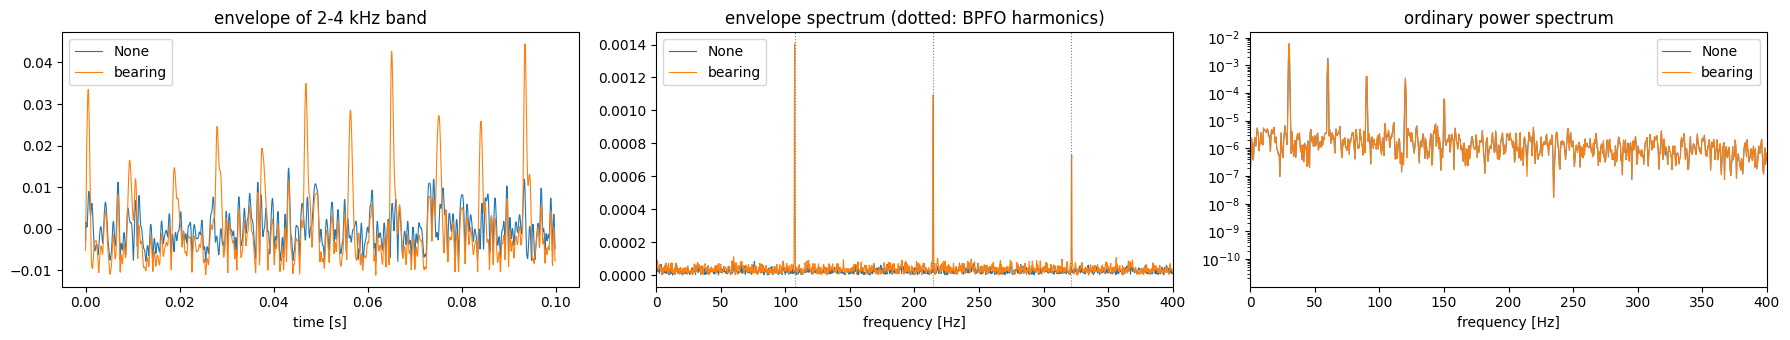

peak of envelope spectrum: 107.2 Hz (BPFO x rotation = 107.1 Hz)


In [8]:
# エンベロープ解析: 共振帯域を取り出し、包絡線を求め、そのスペクトルを見る
def envelope_spectrum(x, band=(2000, 4000), sr=SR):
    env = np.abs(sps.hilbert(bandpass(x, band, sr)))        # ヒルベルト変換で包絡線を得る
    env = env - env.mean()
    spec = np.abs(np.fft.rfft(env * np.hanning(len(env)))) / len(env)
    return np.fft.rfftfreq(len(env), 1 / sr), spec, env

fig, ax = plt.subplots(1, 3, figsize=(18, 3.5))
for name in ["None", "bearing"]:
    f, spec, env = envelope_spectrum(demo[name])
    ax[0].plot(np.arange(1600) / SR, env[:1600], lw=0.8, label=name)
    ax[1].plot(f, spec, lw=0.8, label=name)
f0, P0 = sps.welch(demo["None"], SR, nperseg=32768); f1, P1 = sps.welch(demo["bearing"], SR, nperseg=32768)
ax[2].semilogy(f0, P0, lw=0.8, label="None"); ax[2].semilogy(f1, P1, lw=0.8, label="bearing")
for k in range(1, 4):
    ax[1].axvline(k * BPFO * F_ROT, color="gray", ls=":", lw=0.8)
ax[0].set_title("envelope of 2-4 kHz band"); ax[0].set_xlabel("time [s]"); ax[0].legend()
ax[1].set_title("envelope spectrum (dotted: BPFO harmonics)"); ax[1].set_xlim(0, 400); ax[1].set_xlabel("frequency [Hz]"); ax[1].legend()
ax[2].set_title("ordinary power spectrum"); ax[2].set_xlim(0, 400); ax[2].set_xlabel("frequency [Hz]"); ax[2].legend()
plt.tight_layout(); plt.show()
f, spec, _ = envelope_spectrum(demo["bearing"])
print("peak of envelope spectrum: %.1f Hz (BPFO x rotation = %.1f Hz)" % (f[spec.argmax()], BPFO * F_ROT))

結果の読み方

- 左図: `bearing` の包絡線には、約9ms（1/107秒）ごとに鋭い山が立つ
- 中央図: エンベロープスペクトルには、107Hzとその2倍、3倍の位置に明確な線が立つ
  - 正常ではこの線が無い
  - 線の位置が $f_{\mathrm{BPFO}}$ と一致するので、「外輪の傷である」と**部品まで特定できる**
- 右図: 普通のスペクトルでは、同じ0〜400Hzを見ても、正常と `bearing` の差がわからない

エンベロープ解析の強みと弱みをまとめる

- 強み: 欠陥の周波数がわかっていれば、弱い欠陥でも見つけられ、原因の部品まで言える
- 弱み: 軸受の寸法と回転数を知っている必要がある 想定していない種類の異常には反応しない

これは、第1部で見た「既知の異常には強いが、未知の異常を見逃す」という構図と同じである
- 機械学習による異常検知は、機械の知識が無くても使え、未知の異常にも反応する
- 代わりに、「なぜ異常と判定したか」は自分で調べなければならない
- 現場では、両方を組み合わせるのがよい 機械学習で「いつもと違う」に気づき、信号処理で原因を調べる

# 特徴量

機械学習の手法に入力する特徴量を決める
本テキストでは、**対数メルスペクトログラム**（log-mel spectrogram）を共通の特徴量にする
- 計算の仕組みはG章を参照
- 人の聴覚に合わせた尺度が機械音に最適とは限らないが、次元を減らす効果が大きく、異常音検知でも標準的に使われている

対数メルスペクトログラムは（メル数）×（フレーム数）の2次元配列である
これを手法に渡す形は、主に3通りある

- **統計量**: 帯域ごとに、時間方向の平均と標準偏差を計算する
  - 10秒の音が、メル数の2倍の長さのベクトル1本になる
  - 時間の順序は捨てる 定常音に向く
  - 第3部の古典的な外れ値検知で使う
- **フレームの連結**: 連続する数フレームを1本のベクトルにつなぐ
  - 5フレーム×128帯域なら640次元 短い時間の変化を含められる
  - 第3部のAutoEncoderで使う
- **画像として扱う**: 2次元のままCNNやTransformerに入力する
  - 第3部の識別型の手法と、事前学習済みモデルで使う

<img src="https://class.west.sd.keio.ac.jp/dataai/text/asd-feature-forms.png" width=740>

上の図は、同じ対数メルスペクトログラムを3通りの形で手法に渡す様子を示している

## 窓長、ホップ長、メル数は何を変えるか

対数メルスペクトログラムには、決めるべき値が3つある

- **窓長**（`n_fft`）: 1回のフーリエ変換に使うサンプル数
  - 周波数ビンの幅は $f_s / n_{\mathrm{fft}}$ である 16kHzで `n_fft=1024` なら約15.6Hz
  - 窓を長くすると周波数は細かく分けられるが、その窓の中の時間変化は平均されて見えなくなる
  - 周波数分解能と時間分解能は、**一方を上げると他方が下がる**
- **ホップ長**（`hop`）: 窓をずらす幅
  - 小さいほど時間方向に細かくなるが、フレーム数（データ量）が増える
- **メル数**（`n_mels`）: 周波数方向をいくつの帯域にまとめるか
  - 少ないと隣り合う成分が1つの帯域に混ざる
  - 多いと次元が増え、少ないデータでは正常の範囲を正しく推定しにくくなる

<img src="https://class.west.sd.keio.ac.jp/dataai/text/asd-window-hop.png" width=740>

上の図の左は、窓長とホップ長の意味を示している 窓をホップ長ずつずらしながら、1窓ごとにフーリエ変換する
上の図の右は、窓長による違いである 短い窓は時間方向に細かく周波数方向に粗い 長い窓はその逆である

同じ `bearing` の音を、窓長だけ変えて見てみる

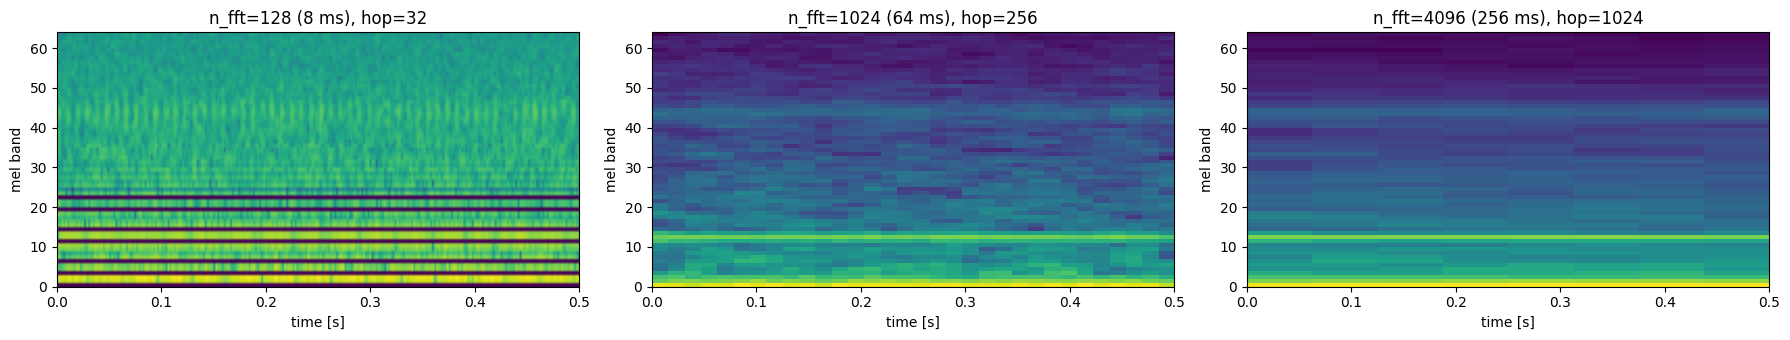

In [9]:
# 窓長とホップ長を変えて、同じ音（軸受の欠陥、0.5秒分）のスペクトログラムがどう変わるかを見る
import warnings
warnings.filterwarnings("ignore", message="Empty filters detected")   # 窓が短いと空のメルフィルタができる（下で説明する）
fig, ax = plt.subplots(1, 3, figsize=(18, 3.5))
for a, n_fft in zip(ax, [128, 1024, 4096]):
    S = logmel_np(demo["bearing"][:SR // 2], n_fft=n_fft, hop=n_fft // 4, n_mels=64)
    a.imshow(S, origin="lower", aspect="auto", extent=[0, 0.5, 0, 64])
    a.set_title(f"n_fft={n_fft} ({1000 * n_fft / SR:.0f} ms), hop={n_fft // 4}")
    a.set_xlabel("time [s]"); a.set_ylabel("mel band")
plt.tight_layout(); plt.show()

- 左（窓長8ms）: 縦の細い筋が見える 1回ずつの衝撃が分かれて見えている
  - 衝撃の間隔は約9msなので、それと同程度の短い窓でなければ分かれない
  - 低い帯域に、値の無い暗い横線が何本も入る
    - 窓が短いと周波数ビンの幅が125Hzと粗くなり、幅の狭い低域のメルフィルタに1つもビンが入らないためである
    - `librosa` はこのとき `Empty filters detected` という警告を出す
- 中央（窓長64ms）: 衝撃は時間方向につながり、横縞になる 600Hzのかみ合い成分は細い線として見える
- 右（窓長256ms）: 周波数方向はさらに細かくなるが、時間方向の変化はほぼ消える

**どの設定がよいかは、見つけたい異常によって変わる**
これを数値で確かめる

## 設定を変えて検知のしやすさを測る

合成音で、次の実験を行う

- 正常音200個で「正常の範囲」を学習する
- 正常音100個と、弱い欠陥を加えた音100個ずつを用意する 欠陥は、上の図よりかなり弱くしてある
- 特徴量は、帯域ごとの時間平均と標準偏差
- 検知器はマハラノビス距離（第3部で説明する） 正常の分布の中心から、ばらつきを考慮してどれだけ離れているかを測る
- 窓長とメル数を変えて、欠陥ごとにAUCを測る

In [10]:
# 弱い欠陥を混ぜた合成データを作り、特徴量の設定ごとに検知のしやすさ（AUC）を測る
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import LedoitWolf

def synth_set(n, fault, level, seed):
    rng = np.random.default_rng(seed)
    return np.stack([synth_machine(dur=2.0, fault=fault, level=level, rng=rng) for _ in range(n)])

WEAK = {"bearing": 0.2, "harmonic": 0.3, "shift": 0.5}   # 欠陥の強さ（1.0が上の図の強さ）
syn_train = synth_set(200, None, 0, 10)
syn_test = {None: synth_set(100, None, 0, 11), **{f: synth_set(100, f, lv, 12 + i) for i, (f, lv) in enumerate(WEAK.items())}}

def stat_features(X, **kw):
    # 帯域ごとの時間平均と標準偏差
    S = make_logmel(**kw)(torch.from_numpy(X))
    return torch.cat([S.mean(2), S.std(2)], 1).numpy()

def maha_auc(feat_fn):
    # 正常の特徴量だけで平均と共分散を推定し、マハラノビス距離を異常スコアにしてAUCを測る
    sc = StandardScaler().fit(feat_fn(syn_train))
    cov = LedoitWolf().fit(sc.transform(feat_fn(syn_train)))
    s0 = cov.mahalanobis(sc.transform(feat_fn(syn_test[None])))
    out = {}
    for f in WEAK:
        s1 = cov.mahalanobis(sc.transform(feat_fn(syn_test[f])))
        out[f] = roc_auc_score(np.r_[np.zeros(len(s0)), np.ones(len(s1))], np.r_[s0, s1])
    return out

grid = []
for n_fft in [128, 512, 2048, 8192]:
    for n_mels in [16, 64, 128]:
        grid.append(dict(n_fft=n_fft, hop=n_fft // 2, n_mels=n_mels,
                         **maha_auc(lambda X: stat_features(X, n_fft=n_fft, hop=n_fft // 2, n_mels=n_mels))))
grid_df = pd.DataFrame(grid)
print(grid_df.round(3).to_string(index=False))

 n_fft  hop  n_mels  bearing  harmonic  shift
   128   64      16    0.744     0.722  0.905
   128   64      64    0.771     0.753  0.860
   128   64     128    0.721     0.675  0.816
   512  256      16    0.648     0.772  0.963
   512  256      64    0.651     0.758  0.829
   512  256     128    0.566     0.745  0.774
  2048 1024      16    0.633     0.751  0.954
  2048 1024      64    0.588     0.800  0.937
  2048 1024     128    0.516     0.666  0.914
  8192 4096      16    0.635     0.780  0.963
  8192 4096      64    0.617     0.795  0.816
  8192 4096     128    0.619     0.756  0.891


結果の読み方（数値は上の出力のとおり）

- `bearing`（周期的な衝撃）は、**最も短い窓（`n_fft=128`）でAUCが最も高い**（0.72〜0.77）
  - 窓を長くすると0.52〜0.65に下がる
  - 短い窓では衝撃が1回ずつ分かれ、帯域の時間方向の標準偏差が大きくなる これが手がかりになる
- `harmonic`（高調波の変化）は、窓長による差が小さい（0.67〜0.80）
  - 帯域のエネルギーが変わるだけなので、どの窓でも時間平均に現れる
- `shift`（周波数のずれ）は、どの設定でも比較的見つけやすい（0.77〜0.96）
  - 線が隣の帯域へ移るので、帯域ごとのエネルギーの配分が変わる
- **メル数は多いほどよい、とはならない**
  - 128帯域（特徴量256次元）にすると、多くの場合で16帯域や64帯域より下がる
  - 学習用の正常音は200個しかない 次元が増えると、正常のばらつき方（共分散）の推定が不正確になる
  - 細かく見ることの利点より、推定が荒れることの損が上回っている

この実験から持ち帰ること

- 特徴量の設定に「万能の正解」は無い 見つけたい異常の性質（定常か突発か、どの帯域か）で決まる
- 何もわからない段階では、`n_fft=1024`、`hop=512`、`n_mels=128`（16kHzの場合）のような標準的な設定から始めるのが無難である
  - 第3部でもこの設定を使う
- 突発音や衝撃を狙うなら窓とホップを短くする、という調整を後から試す（章末の課題）

## 欠陥の周波数を知っている場合との比較

最後に、同じ弱い `bearing` の欠陥を、エンベロープ解析で検知してみる
- エンベロープスペクトルの、$f_{\mathrm{BPFO}}$ 付近の高さを指標にする
- これは「どこを見ればよいかを知っている」場合のやり方である

In [11]:
# 欠陥の周波数を知っている場合: エンベロープスペクトルのBPFO付近の高さを指標にして、同じ弱い欠陥を検知する
def bpfo_indicator(x):
    f, spec, _ = envelope_spectrum(x)
    near = (f > BPFO * F_ROT * 0.97) & (f < BPFO * F_ROT * 1.03)     # 回転数のゆらぎの分だけ幅を持たせる
    return spec[near].max() / np.median(spec[(f > 50) & (f < 400)])

i0 = np.array([bpfo_indicator(x) for x in syn_test[None]])
i1 = np.array([bpfo_indicator(x) for x in syn_test["bearing"]])
k0 = np.array([spstats.kurtosis(bandpass(x), fisher=False) for x in syn_test[None]])
k1 = np.array([spstats.kurtosis(bandpass(x), fisher=False) for x in syn_test["bearing"]])
yy = np.r_[np.zeros(len(i0)), np.ones(len(i1))]
print("weak bearing fault, AUC")
print("  envelope spectrum at BPFO : %.3f" % roc_auc_score(yy, np.r_[i0, i1]))
print("  kurtosis of 2-4 kHz band  : %.3f" % roc_auc_score(yy, np.r_[k0, k1]))
print("  best log-mel statistics   : %.3f" % grid_df.bearing.max())

weak bearing fault, AUC
  envelope spectrum at BPFO : 0.846
  kurtosis of 2-4 kHz band  : 0.645
  best log-mel statistics   : 0.771


- エンベロープスペクトルの指標は、AUC 0.85で、対数メルの統計量で最もよかった設定（0.77）を上回る
- 共振帯域の尖度（0.65）は、欠陥が弱いと効きにくい
- 機械の知識を使って「見る場所」を絞ると、少ないデータでも弱い異常を見つけられる
- ただし、この指標は `harmonic` や `shift` にはまったく反応しない

**知識で絞り込む手法は狭く深く、データから学ぶ手法は広く浅い**
本テキストの残りでは、後者を扱う

---

# 第3部 手法を作って比べる

ここからは実際の機械の録音を使い、5系統の手法を同じ条件で実装して比べる

| 手法 | 正常のモデル | 異常スコア | 学習 |
| --- | --- | --- | --- |
| 古典的な外れ値検知 | 統計量の分布（平均と共分散、決定木、混合ガウス） | 分布からの外れ具合 | 数秒 |
| AutoEncoder | 正常音を圧縮して復元するネットワーク | 再構成誤差 | 必要 |
| 識別型 | 個体IDを当てるCNNの埋め込み | 確信度の低さ、埋め込みの距離 | 必要 |
| 事前学習済みモデル | 大規模データで学習済みの音響モデルの埋め込み | 埋め込みの距離 | 不要 |

<img src="https://class.west.sd.keio.ac.jp/dataai/text/asd-methods-compare.png" width=780>

上の図は、同じ内容を、正常のモデル、異常スコア、学習の要否の3点で並べたものである

# 実習に使うデータ

## データセット

**DCASE 2020 Challenge Task 2 の開発用データセット**を使う
- DCASE（Detection and Classification of Acoustic Scenes and Events）は、音響イベントの検出と分類を競う国際的なコンテストである
- Task 2 は「機械の状態監視のための教師なし異常音検知」で、本テキストと同じ問題設定である
- 6機種（ファン、ポンプ、スライダ、バルブ、おもちゃの車、おもちゃのコンベア）の音が含まれる
  - 前の4機種は **MIMII Dataset**（実際の産業機械の録音）から、後の2機種は **ToyADMOS**（小型の模型の録音）から作られている

本テキストでは、このうち**ポンプ**（pump）と**バルブ**（valve）の2機種を使う
- ポンプは定常音、バルブは突発音の代表である 第2部で述べた違いが結果に現れる
- 2機種で約2GB 6機種すべてを取得すると約8GBになるので絞っている

| 項目 | 内容 |
| --- | --- |
| 配布元 | Zenodo `https://zenodo.org/records/3678171` |
| ライセンス | Creative Commons Attribution-NonCommercial-ShareAlike 4.0（CC BY-NC-SA 4.0） |
| 形式 | 16kHz、モノラル、1ファイル約10秒のWAV |
| 個体 | 機種ごとに4台（ID 00、02、04、06） |
| 学習用 | 正常音だけ 個体あたり約600〜1000ファイル |
| テスト用 | 個体あたり正常音100ファイルと、異常音100〜143ファイル |
| 異常の内容 | 実際の機械をわざと損傷させて録音したもの（汚れの混入、漏れ、回転の不釣り合いなど） |
| 雑音 | 実際の工場で録った環境雑音が重ねられている |

出典は次のとおりである（詳細は章末の参考文献）
- Koizumi et al. (2020): DCASE 2020 Task 2 の課題とデータの説明
- Purohit et al. (2019): MIMII Dataset
- Koizumi et al. (2019): ToyADMOS

利用上の注意
- ライセンスは**非営利の利用に限る**ものである 講義や研究での利用はできるが、製品に組み込む用途には使えない
- このデータを使った結果を発表するときは、上の出典を示す

## データの取得

Zenodoから機種ごとのzipファイル（各約1GB）を取得して展開する
- Zenodoは、1本の接続あたりの転送速度が遅いことがある
- そこで、ファイルを8つの範囲に分けて並列に取得し、後で1つにつなぐ
- すでに展開済みなら何もしないので、このセルは何度実行してもよい

In [12]:
# 公開データのうち、使う機種の分だけを取得して展開する（取得済みなら何もしない）
DATA_DIR = "asd_data"
MACHINES = ["pump", "valve"]
URL = "https://zenodo.org/records/3678171/files/dev_data_{}.zip?download=1"

def fetch(url, out, n_conn=8):
    # ファイルをn_conn個の範囲に分け、curlで並列に取得してから1つにつなぐ
    head = subprocess.run(["curl", "-sIL", url], capture_output=True, text=True).stdout.lower()
    size = int([l.split()[1] for l in head.splitlines() if l.startswith("content-length")][-1])
    step = math.ceil(size / n_conn)
    procs = [subprocess.Popen(["curl", "-sL", "--retry", "10", "-r",
                               f"{i * step}-{min((i + 1) * step, size) - 1}", "-o", f"{out}.{i:02d}", url])
             for i in range(n_conn)]
    assert all(p.wait() == 0 for p in procs), "download failed"
    with open(out, "wb") as w:
        for i in range(n_conn):
            with open(f"{out}.{i:02d}", "rb") as r:
                shutil.copyfileobj(r, w)
            os.remove(f"{out}.{i:02d}")
    assert os.path.getsize(out) == size, "size mismatch"

os.makedirs(DATA_DIR, exist_ok=True)
for m in MACHINES:
    if os.path.isdir(os.path.join(DATA_DIR, m, "train")):
        print(m, ": already exists")
        continue
    t0 = time.time()
    zpath = os.path.join(DATA_DIR, m + ".zip")
    fetch(URL.format(m), zpath)
    with zipfile.ZipFile(zpath) as z:
        z.extractall(DATA_DIR)
    os.remove(zpath)
    print(f"{m}: done in {time.time() - t0:.0f} s")

pump : already exists
valve : already exists


## ファイルの一覧表を作る

ファイル名は `normal_id_00_00000000.wav` のように、正常か異常か、個体ID、通し番号を含んでいる
これを読み取って、1ファイルを1行とする表 `meta` を作る

ここで、学習用の正常音の1割を**検証用**（`val`）に取り分ける
- 検証用は、モデルの学習には使わない
- なお、このデータの学習用とテスト用は、配布元によってあらかじめ分けられている
  - 自分でデータを分けるときは、同じ録音から切り出したクリップが学習用とテスト用にまたがらないようにする（「MLライブラリの基礎」の章の「分割の仕方によるリーク：グループ」を参照）
- 後で、**しきい値を決める**ために使う
- しきい値を決めるには「学習に使っていない正常音が、どのくらいのスコアになるか」を知る必要がある
  - 学習に使った音のスコアは、使っていない音より小さく出るので、そのままでは使えない

以降、3種類のデータを次のように使い分ける

| 名前 | 中身 | 用途 |
| --- | --- | --- |
| `train` | 正常音 | 正常のモデルを作る |
| `val` | 正常音 | しきい値を決める |
| `test` | 正常音と異常音 | 性能を測る |

<img src="https://class.west.sd.keio.ac.jp/dataai/text/asd-data-split.png" width=700>

上の図は、3種類のデータの分け方と用途を示している 異常音はテスト用にしか無いので、学習にも、しきい値の決定にも使えない

In [13]:
# ファイル名から機種、個体ID、正常・異常を読み取り、一覧表を作る
rows = []
for m in MACHINES:
    for sp in ["train", "test"]:
        for p in sorted(glob.glob(f"{DATA_DIR}/{m}/{sp}/*.wav")):
            kind, _, mid, _ = os.path.basename(p).split("_")   # 例: normal_id_00_00000000.wav
            rows.append(dict(path=p, machine=m, mid=mid, split=sp, label=int(kind == "anomaly")))
meta = pd.DataFrame(rows)
meta["unit"] = meta.machine + "_" + meta.mid

# 学習用の正常音の1割を、しきい値を決めるための検証用（val）に取り分ける
rng = np.random.default_rng(SEED)
meta.loc[(meta.split == "train") & (rng.random(len(meta)) < 0.1), "split"] = "val"
UNITS = sorted(meta.unit.unique())

def rows_of(split, unit=None, machine=None):
    # 条件に合う行番号を返す  splitは "train" "val" "test" またはそのリスト
    m = meta.split.isin([split] if isinstance(split, str) else split)
    if unit is not None:
        m &= meta.unit == unit
    if machine is not None:
        m &= meta.machine == machine
    return np.where(m.values)[0]

print(meta.groupby(["machine", "mid", "split", "label"]).size().unstack(["split", "label"]).fillna(0).astype(int))

split       test      train  val
label          0    1     0    0
machine mid                     
pump    00   100  143   827   79
        02   100  111   800  105
        04   100  100   524   78
        06   100  102   852   84
valve   00   100  119   791  100
        02   100  120   546   62
        04   100  120   792  108
        06   100  120   814   78


- 列は `split`（用途）と `label`（0が正常、1が異常）の組合せ、行は機種と個体である
- 異常音は `test` にしか無い これが異常検知の問題設定である

以降、機種と個体の組（例: `pump_00`）を「個体」と呼び、**個体ごとに正常のモデルを作る**
- 第1部で述べたとおり、同じ機種でも個体によって音が違うからである

## 特徴量を計算しておく

全ファイルの対数メルスペクトログラムを計算し、1つの配列 `LM` にまとめる
- 設定は `n_fft=1024`（64ms）、`hop=512`（32ms）、`n_mels=128`
- 10秒の音が、128×313の配列になる
- 約8400ファイルあるので、GPUでまとめて計算し、結果をファイルに保存して再利用する

In [14]:
# 全ファイルの対数メルスペクトログラムを計算する（GPUでまとめて計算し、結果を保存しておく）
N_FFT, HOP, N_MELS = 1024, 512, 128
logmel = make_logmel(N_FFT, HOP, N_MELS)

def load_wave(path, sr=SR, dur=10.0):
    # 音声ファイルを読み、モノラル、sr [Hz]、dur [s] にそろえる
    x, fs = sf.read(path, dtype="float32")
    if x.ndim > 1:
        x = x.mean(1)
    if fs != sr:
        x = librosa.resample(x, orig_sr=fs, target_sr=sr)
    n = int(sr * dur)
    return np.pad(x[:n], (0, max(0, n - len(x))))

def extract_logmel(paths, wave_fn=load_wave, batch=128, fe=None):
    # fe: 特徴量を計算する関数（省略時は上で作ったlogmel）
    fe = logmel if fe is None else fe
    out = []
    with ThreadPoolExecutor(8) as ex:
        for i in range(0, len(paths), batch):
            x = torch.from_numpy(np.stack(list(ex.map(wave_fn, paths[i:i + batch])))).to(device)
            out.append(fe(x).cpu())
    return torch.cat(out)

t0 = time.time()
if os.path.exists("logmel_cache.npy"):
    LM = torch.from_numpy(np.load("logmel_cache.npy").astype(np.float32))
else:
    LM = extract_logmel(meta.path.tolist())
    np.save("logmel_cache.npy", LM.numpy().astype(np.float16))
assert len(LM) == len(meta)
print(LM.shape, f"{time.time() - t0:.0f} s")

torch.Size([8375, 128, 313]) 5 s


## 音を見て、聞く

手法を作る前に、必ずデータを自分の目と耳で確かめる
- ポンプとバルブについて、同じ個体の正常音と異常音を並べる

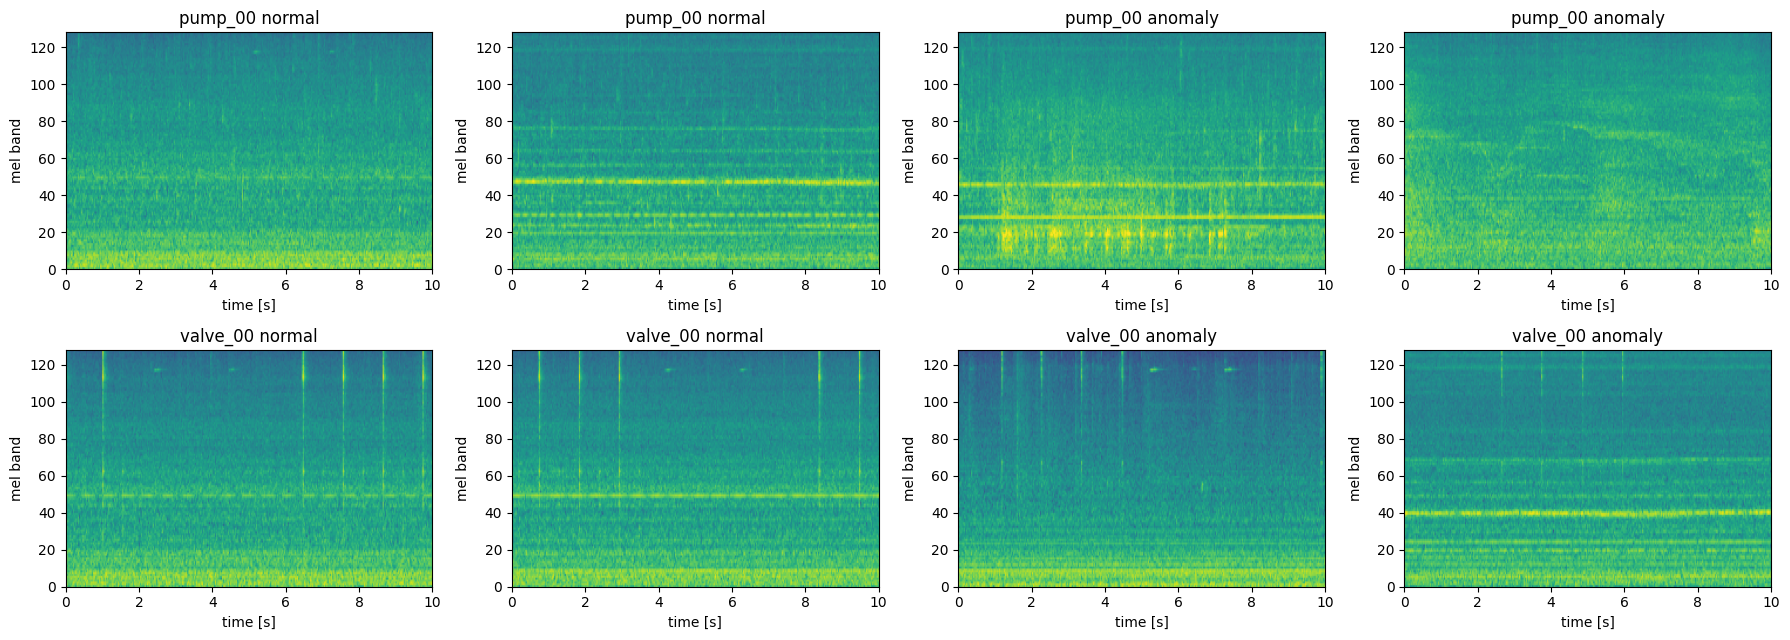

In [15]:
# ポンプとバルブについて、同じ個体の正常音と異常音のスペクトログラムを2つずつ並べる
fig, ax = plt.subplots(2, 4, figsize=(18, 6.5))
for i, u in enumerate(["pump_00", "valve_00"]):
    te = rows_of("test", unit=u); y = meta.label.values[te]
    picks = [(te[y == 0][0], "normal"), (te[y == 0][1], "normal"), (te[y == 1][0], "anomaly"), (te[y == 1][1], "anomaly")]
    for j, (k, name) in enumerate(picks):
        ax[i, j].imshow(LM[k].numpy(), origin="lower", aspect="auto", vmin=-70, vmax=0, extent=[0, 10, 0, N_MELS])
        ax[i, j].set_title(f"{u} {name}"); ax[i, j].set_xlabel("time [s]"); ax[i, j].set_ylabel("mel band")
plt.tight_layout(); plt.show()

- ポンプ（上段）は、横縞が時間方向に続く **定常音**である
  - 正常音どうし（左の2つ）でも、横縞の本数や強さがかなり違う 同じ個体の正常音にも、これだけの幅がある
  - この例の異常音（右の2つ）は、低い帯域に不規則な明るい部分が現れる、横縞がぼやける、といった違いが見える
  - ただし、正常音どうしの違いも大きいので、「どこまでが正常の幅か」は、2つずつ見ただけでは判断できない
- バルブ（下段）は、縦の筋が間をおいて並ぶ **突発音**である
  - 弁が開閉する瞬間だけ音が鳴り、それ以外は工場の環境雑音である 10秒のうち、弁の音が占める時間はごく一部である
  - この例の異常音は、縦の筋が弱い（3つ目）、正常音には無い横縞が加わっている（4つ目）、といった違いが見える
- ここで見たのは各2例だけである 異常の現れ方は、音によって違う

次のセルで音を再生する **必ず自分の耳で聴くこと**
- ポンプとバルブのそれぞれについて、正常音と異常音を聴き比べる
- 「何が違って聞こえるか」を、自分の言葉で書き留める（音の高さ、大きさ、リズム、濁り、鳴っている時間、など）
- 違いがわからなかった場合は、「わからなかった」と書き留める それも大事な観察である
- `te[y == 1][0]` の `0` を別の番号に変えると、別の音を聴ける 少なくとも3組は聴いてみる
- 書き留めた内容は、後の「判断の根拠を見る」の節で、検知器が反応した場所と照らし合わせる

In [16]:
# 音を再生する（Colabやノートブック上で実行したときに再生ボタンが出る）
from IPython.display import Audio, display
for u in ["pump_00", "valve_00"]:
    te = rows_of("test", unit=u); y = meta.label.values[te]
    for k, name in [(te[y == 0][0], "normal"), (te[y == 1][0], "anomaly")]:
        print(u, name)
        display(Audio(load_wave(meta.path[k]), rate=SR))

pump_00 normal


pump_00 anomaly


valve_00 normal


valve_00 anomaly


## 評価の共通部品

すべての手法を同じ物差しで比べるために、評価の関数を先に作っておく

- 各手法は、`val` と `test` の全ファイルに対して異常スコアを出す
- `evaluate` は、**個体ごと**にAUCと部分AUC（pAUC）を計算し、機種ごとの平均を表示する
  - AUCについては「機械学習の基礎」の章を参照 音を対象にした検出の評価（F値、EER）はG章の「音響イベント検出」「話者認識」も参照
  - pAUCは、誤報率が低い範囲だけで測ったAUCである 後の「評価」の節で詳しく説明する
- `per_unit` は、個体ごとに「学習用の正常音で検知器を作り、スコアを出す」という繰り返しをまとめたものである

個体ごとにモデルを作り、個体ごとに評価する設計は、G章の話者認識（話者ごとの埋め込みと照合）と同じ構図である

個体ごとに評価する理由
- スコアの大きさは個体によって違う 複数の個体を混ぜてAUCを計算すると、個体間のスコアの差が混ざり、検知の良し悪しを正しく測れない
- 現場でも、しきい値は個体ごとに決める

In [17]:
# 評価の共通関数: 個体ごとにAUCと部分AUCを計算し、手法名を付けて記録する
scores = {}    # 手法名 -> 異常スコア（metaと同じ並び、未計算の行はNaN）
results = {}   # 手法名 -> 個体別の評価表

def evaluate(name, s, record=True, verbose=True):
    # s: metaと同じ並びの異常スコア  record=Trueなら比較表に載せる
    rows = []
    for u in UNITS:
        idx = rows_of("test", unit=u)
        y = meta.label.values[idx]
        rows.append(dict(machine=u.split("_")[0], unit=u,
                         auc=roc_auc_score(y, s[idx]),
                         pauc=roc_auc_score(y, s[idx], max_fpr=0.1)))
    df = pd.DataFrame(rows)
    if record:
        scores[name], results[name] = s, df
    if verbose:
        avg = df.groupby("machine")[["auc", "pauc"]].mean()
        print(name, " ".join(f"| {m}: AUC {r.auc:.3f} pAUC {r.pauc:.3f}" for m, r in avg.iterrows()))
    return df

def per_unit(X, fit, X_eval=None, X_extra=None):
    # 個体ごとに、学習用の正常音だけで検知器を作り、検証用とテスト用のスコアを求める
    # X_eval: スコアを求める側の特徴量（省略時はX）  X_extra: 学習用に追加する特徴量（metaと同じ並び）
    X_eval = X if X_eval is None else X_eval
    s = np.full(len(meta), np.nan)
    for u in UNITS:
        tr = rows_of("train", unit=u)
        tr = tr[~np.isnan(X[tr]).any(1)]            # 特徴量を計算していない行は使わない
        Xf = X[tr] if X_extra is None else np.r_[X[tr], X_extra[tr]]
        idx = rows_of(["val", "test"], unit=u)
        s[idx] = fit(Xf)(X_eval[idx])
    return s

def machine_auc(s):
    # 機種ごとの平均AUCを返す（比較表には載せない）
    return evaluate("", s, record=False, verbose=False).groupby("machine").auc.mean()

---

# 基準となる手法1: 古典的な外れ値検知

最初に、深層学習を使わない手法を作る
- 学習が数秒で終わり、挙動を理解しやすい
- 後で作る複雑な手法が、本当に複雑にしただけの価値があるかを判断する**基準**になる

## 特徴量: 帯域ごとの統計量

10秒の対数メルスペクトログラム（128×313）を、256次元のベクトル1本にまとめる

- 各帯域の**時間平均**（128次元）: どの周波数が、平均してどれだけ強いか
- 各帯域の**時間方向の標準偏差**（128次元）: その強さが、時間とともにどれだけ変動するか

時間の順序は捨てることになるが、定常音であれば失うものは少ない

## 3つの検知器

**マハラノビス距離**（Mahalanobis distance）
- 正常データの平均 $\boldsymbol{\mu}$ と共分散行列 $\Sigma$ を求め、次の距離をスコアにする

$$ d(\boldsymbol{x}) = \sqrt{(\boldsymbol{x} - \boldsymbol{\mu})^\top \Sigma^{-1} (\boldsymbol{x} - \boldsymbol{\mu})} $$

- 単なるユークリッド距離と違い、**正常データがもともと大きくばらつく方向のずれは小さく、ばらつかない方向のずれは大きく**数える

<img src="https://class.west.sd.keio.ac.jp/dataai/text/asd-mahalanobis.png" width=500>

上の図は、2つの特徴量が一緒に動く（相関がある）正常データの例である
- AとBは、中心からのユークリッド距離が同じである（点線の円の上にある）
- Aは正常データがもともとばらつく方向にあるので、マハラノビス距離は小さい
- Bは正常データがばらつかない方向に外れているので、マハラノビス距離は大きく、異常とみなされる

- 正常データが1つの正規分布に従うと仮定していることになる
- 256次元の共分散行列を数百個のデータから推定すると不安定になるので、Ledoit-Wolfの縮小推定を使う
  - 推定した共分散行列を、単位行列の定数倍に少し近づけて安定させる方法である

**Isolation Forest**
- データをランダムな特徴量とランダムなしきい値で繰り返し分割する木を、多数作る
- 外れた点は、少ない回数の分割で他から切り離される（孤立する）
- 切り離されるまでの分割回数が少ないほど、異常とみなす
- 分布の形を仮定しない

**混合ガウスモデル**（Gaussian mixture model、GMM）
- 正常データを、複数の正規分布の重ね合わせで表す
- 対数尤度の低さをスコアにする
- 正常な状態が複数ある（運転モードが切り替わるなど）場合に、マハラノビス距離より柔軟に表せる
- ここでは、主成分分析で32次元に減らしてから、4つの正規分布を当てはめる

In [18]:
# 古典的な外れ値検知: 帯域ごとの統計量を特徴量にして、3つの検知器を比べる
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import LedoitWolf
from sklearn.ensemble import IsolationForest
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline

def clip_stats(lm):
    # (N, メル数, フレーム数) -> (N, 2×メル数)  各帯域の時間平均と時間方向の標準偏差
    return torch.cat([lm.mean(2), lm.std(2)], 1).numpy()

X_stat = clip_stats(LM)

def fit_maha(Xf):
    sc = StandardScaler().fit(Xf)
    cov = LedoitWolf().fit(sc.transform(Xf))
    return lambda X: cov.mahalanobis(sc.transform(X))

def fit_iforest(Xf):
    m = IsolationForest(n_estimators=200, random_state=SEED).fit(Xf)
    return lambda X: -m.score_samples(X)

def fit_gmm(Xf):
    m = make_pipeline(StandardScaler(), PCA(32, whiten=True, random_state=SEED),
                      GaussianMixture(4, covariance_type="full", reg_covar=1e-3, random_state=SEED)).fit(Xf)
    return lambda X: -m.score_samples(X)

for name, fit in [("Stats+Mahalanobis", fit_maha), ("Stats+IsolationForest", fit_iforest), ("Stats+GMM", fit_gmm)]:
    t0 = time.time()
    evaluate(name, per_unit(X_stat, fit))
    print(f"   {time.time() - t0:.1f} s")

Stats+Mahalanobis | pump: AUC 0.810 pAUC 0.627 | valve: AUC 0.788 pAUC 0.562
   2.2 s
Stats+IsolationForest | pump: AUC 0.728 pAUC 0.554 | valve: AUC 0.665 pAUC 0.519
   7.0 s
Stats+GMM | pump: AUC 0.726 pAUC 0.575 | valve: AUC 0.586 pAUC 0.505
   4.1 s


結果の読み方

- 3つの中では、最も単純な**マハラノビス距離が最もよい**（ポンプ0.810、バルブ0.788）
- Isolation Forest（0.728、0.666）と混合ガウスモデル（0.723、0.585）は、それより低い
  - 柔軟なモデルほどよい、とはならない 個体あたり500〜850個の正常音では、複雑な分布の形を推定するにはデータが足りない
  - Isolation Forestは、1回の分割で1つの特徴量しか見ない 256個の特徴量にまたがる「組合せとしてのずれ」を捉えにくい
  - マハラノビス距離は、特徴量どうしの相関を共分散行列で扱う 隣り合う帯域が一緒に動く、という音の性質に合っている
- pAUCはどれも0.5〜0.63で、AUCに比べて低い 誤報を少なく抑えた設定では、まだ多くの異常を見逃す
- 計算は3つ合わせても数秒で終わる

**まず単純な基準を作る**ことの意味が、ここにある
以降の手法は、AUC 0.80前後というこの基準を上回って初めて、手間をかける価値がある

## 実データで特徴量の設定を変える

第2部では、合成音で「特徴量の設定によって検知のしやすさが変わる」ことを見た
同じことを実際の録音で確かめる
- 窓長、ホップ長、メル数を変えて、統計量を計算し直す
- 検知器は、上で最もよかったマハラノビス距離に固定する
- 設定ごとに全ファイルを読み直すので、少し時間がかかる

In [19]:
# 実データで特徴量の設定を変える: 窓長、ホップ長、メル数を変えて統計量を計算し直し、マハラノビス距離で評価する
def stats_with(n_fft, hop, n_mels):
    f = make_logmel(n_fft, hop, n_mels)
    def fe(x):
        S = f(x)
        return torch.cat([S.mean(2), S.std(2)], 1)      # 対数メルは保存せず、統計量だけを残す
    return extract_logmel(meta.path.tolist(), fe=fe).numpy()

feat_rows = []
for n_fft, hop, n_mels in [(256, 128, 64), (1024, 512, 64), (1024, 512, 128), (1024, 128, 128), (4096, 2048, 128), (4096, 512, 128)]:
    t0 = time.time()
    X = stats_with(n_fft, hop, n_mels)
    a = machine_auc(per_unit(X, fit_maha))
    a_mean = machine_auc(per_unit(X[:, :n_mels], fit_maha))      # 時間平均だけを使った場合
    a_std = machine_auc(per_unit(X[:, n_mels:], fit_maha))       # 時間方向の標準偏差だけを使った場合
    feat_rows.append(dict(n_fft=n_fft, hop=hop, n_mels=n_mels, pump=a["pump"], valve=a["valve"],
                          valve_mean_only=a_mean["valve"], valve_std_only=a_std["valve"],
                          pump_mean_only=a_mean["pump"], pump_std_only=a_std["pump"], sec=round(time.time() - t0)))
print(pd.DataFrame(feat_rows).round(3).to_string(index=False))

 n_fft  hop  n_mels  pump  valve  valve_mean_only  valve_std_only  pump_mean_only  pump_std_only  sec
   256  128      64 0.780  0.707            0.513           0.731           0.782          0.690   30
  1024  512      64 0.793  0.786            0.532           0.818           0.806          0.680   26
  1024  512     128 0.810  0.788            0.545           0.828           0.831          0.700   20
  1024  128     128 0.809  0.787            0.546           0.825           0.831          0.704   16
  4096 2048     128 0.800  0.865            0.610           0.884           0.843          0.660   14
  4096  512     128 0.798  0.865            0.611           0.882           0.843          0.662   14


結果の読み方

- ポンプ（定常音）は、設定を変えてもAUCが0.78〜0.81の範囲でほとんど動かない
- バルブ（突発音）は、設定によって0.71〜0.87と大きく動く
  - **最も長い窓（`n_fft=4096`、256ms）が最もよく、0.865**になる 標準の設定（0.788）より0.08高い
  - 最も短い窓（`n_fft=256`）は0.707で、最も悪い

**本来はどうなるはずか**
- 第2部では、「突発音や衝撃を見るには、短い窓がよい」と述べた 合成音の実験でも、周期的な衝撃は最も短い窓で最も見つけやすかった
- この考えに従えば、突発音であるバルブでは短い窓が有利で、長い窓は不利になるはずである

**なぜここでは逆になったのか** 表の残りの列から、わかることを順に挙げる

- ホップ長は関係していない
  - `n_fft=1024` のままホップを512から128に縮めても、変わらない（0.788と0.787）
  - `n_fft=4096` でホップを2048から512に縮めても、変わらない（どちらも0.865）
  - つまり、効いているのは「時間方向にどれだけ細かく刻むか」ではなく、**窓の長さそのもの**である
- バルブの検知は、ほぼ**時間方向の標準偏差**の特徴量だけで決まっている
  - 標準偏差だけを使うと0.828（標準の設定）、時間平均だけを使うと0.545
  - 弁が鳴っていない時間の方が長いので、時間平均は環境雑音で決まり、異常の情報をほとんど持たない
  - 「各帯域のエネルギーが、時間とともにどれだけ変動するか」に、弁の開閉の強さと回数が現れる
  - 長い窓にすると、この標準偏差だけの場合が0.884まで上がる
- 第2部の合成音とは、状況が違う
  - 合成音の衝撃は約9msの間隔で繰り返していた 1回ずつを分けるには、それより短い窓が必要だった
  - バルブの開閉は、1秒前後の間隔で起きる 標準の窓（64ms）でも256msの窓でも、1回ずつ分かれて見える
  - したがって、短い窓にする利点が、もともと無い

長い窓がなぜ有利なのかについては、要因を2つ考えられる
- 長い窓は周波数ビンが細かい（約3.9Hz） 低い周波数では、メルの帯域の幅が標準の窓のビン幅（約15.6Hz）と同程度しかなく、標準の窓では隣の帯域と区別がつかない 長い窓では、これが分かれる
- 長い窓は、1フレームの中で長い時間を平均する 環境雑音によるフレームごとの細かい変動がならされ、標準偏差が「弁の開閉による変動」をより純粋に表すようになる

**この実験からは、どちらが主な理由かを断定できない**
- 切り分けるには、長い窓のまま周波数方向だけを粗くする、標準の窓のままフレームを時間方向に平均する、といった追加の実験が要る（章末の課題1）
- ここで確かに言えるのは、「突発音には短い窓」という規則が、**何を特徴量にするか（ここでは10秒全体の統計量）と、音の時間的な細かさによって成り立たないことがある**、ということである

以降は、手法どうしを比べやすいように、標準の設定（`n_fft=1024`、`hop=512`、`n_mels=128`）のまま進める

---

# 基準となる手法2: AutoEncoderによる再構成誤差

異常音検知で最も広く使われてきた、深層学習による基準の手法である
- 考え方はB章の「AutoEncoderによる異常検知」と同じである
  - 正常音だけで、入力をそのまま復元するように学習する
  - 正常音は小さい誤差で復元できる 学習していない異常音は復元に失敗し、誤差が大きくなる、と期待する
- DCASE 2020 Task 2 でも、主催者が基準として示した手法がAutoEncoderであった

## 入力: フレームの連結

1フレーム（32ms）だけでは、時間的な変化がわからない
そこで、連続する5フレームを1本のベクトルにつなぎ、640次元（128×5）の入力とする
- 1つの10秒の音から、1フレームずつずらして309本のベクトルが取れる
- 学習時は、ランダムなファイルのランダムな位置から取り出す

## モデル

全結合層だけの小さなAutoEncoderである
- エンコーダ: 640 → 128 → 128 → 128 → 8
- デコーダ: 8 → 128 → 128 → 128 → 640
- 中央の8次元が**ボトルネック**である

機種ごとに1つのモデルを学習する（4つの個体の正常音をまとめて使う）

<img src="https://class.west.sd.keio.ac.jp/dataai/text/asd-frame-concat.png" width=780>

上の図は、入力の作り方からスコアまでの流れである
- スペクトログラムから連続する5フレームを取り出して640次元の入力とし、8次元まで絞ってから復元する
- 入力と復元の差（再構成誤差）を、異常スコアの材料にする

In [20]:
# 全結合のAutoEncoderと、フレームを連結した入力ベクトルを作る関数
N_CTX = 5   # 連結するフレーム数

class DenseAE(nn.Module):
    def __init__(self, d_in=N_MELS * N_CTX, h=128, z=8):
        super().__init__()
        blk = lambda a, b: nn.Sequential(nn.Linear(a, b), nn.BatchNorm1d(b), nn.ReLU())
        self.enc = nn.Sequential(blk(d_in, h), blk(h, h), blk(h, h), blk(h, z))
        self.dec = nn.Sequential(blk(z, h), blk(h, h), blk(h, h), nn.Linear(h, d_in))
    def forward(self, x):
        return self.dec(self.enc(x))

def all_frame_vectors(lm):
    # (B, メル数, T) -> (B, T-N_CTX+1, N_CTX×メル数)  1フレームずつずらして連結する
    return lm.unfold(2, N_CTX, 1).permute(0, 2, 3, 1).flatten(2)

def train_ae(idx, z=8, steps=3000, bs=512, lr=1e-3, seed=SEED, lm_src=None):
    # idxの正常音だけでAutoEncoderを学習する  ランダムな位置から連結フレームを取り出して使う
    # lm_src: 対数メルの置き場所（省略時はLM）
    torch.manual_seed(seed)
    src = LM if lm_src is None else lm_src
    lm = src[idx].to(device)                       # 先にGPUへ移し、正規化はGPU上で行う（CPUのRAMに一時的な複製を作らない）
    mu, sd = lm.mean().item(), lm.std().item()
    lm.sub_(mu).div_(sd)
    model = DenseAE(d_in=src.shape[1] * N_CTX, z=z).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    ar = torch.arange(N_CTX, device=device)
    for step in range(steps):
        ci = torch.randint(0, lm.shape[0], (bs,), device=device)
        ti = torch.randint(0, lm.shape[2] - N_CTX + 1, (bs,), device=device)
        x = lm[ci[:, None], :, ti[:, None] + ar].flatten(1)
        loss = F.mse_loss(model(x), x)
        opt.zero_grad(); loss.backward(); opt.step()
    return model.eval(), (mu, sd)

@torch.no_grad()
def ae_frame_errors(model, norm, idx, bs=64, lm_src=None, with_bias=False):
    # 各クリップの、連結フレームごとの再構成誤差 (N, T-N_CTX+1) を返す
    # with_bias=Trueのときは、残差（復元−入力）を符号付きのまま時間平均してから2乗したもの (N,) も返す
    src = LM if lm_src is None else lm_src
    out, bias = [], []
    for i in range(0, len(idx), bs):
        x = all_frame_vectors(((src[idx[i:i + bs]] - norm[0]) / norm[1]).to(device))
        r = (model(x.flatten(0, 1)) - x.flatten(0, 1)).view(*x.shape)        # 残差 (B, フレーム, 次元)
        out.append((r ** 2).mean(2).cpu())
        bias.append((r.mean(1) ** 2).mean(1).cpu())
    out, bias = torch.cat(out).numpy(), torch.cat(bias).numpy()
    return (out, bias) if with_bias else out

## 学習とスコア

- 1つの音から309個の再構成誤差が得られる
- これを1つのスコアにまとめる方法を2通り試す
  - **時間平均**: 全体として復元しにくい音ほど高くなる
  - **最大値**: 一瞬でも復元しにくい箇所があれば高くなる
- あわせて、正常音、異常音、**別の機種の音**の再構成誤差の平均を比べる

In [21]:
# 機種ごとにAutoEncoderを学習し、再構成誤差の時間平均を異常スコアにする
ae_models, ae_err = {}, {}
s_mean, s_max = np.full(len(meta), np.nan), np.full(len(meta), np.nan)
for m in MACHINES:
    t0 = time.time()
    ae_models[m] = train_ae(rows_of("train", machine=m))
    idx = rows_of(["val", "test"], machine=m)
    e = ae_frame_errors(*ae_models[m], idx)
    s_mean[idx], s_max[idx] = e.mean(1), e.max(1)
    ae_err[m] = (idx, e)
    print(f"{m}: trained and scored in {time.time() - t0:.0f} s")
evaluate("AE (mean error)", s_mean)
evaluate("AE (max error)", s_max)

# 再構成誤差の平均を、正常音、異常音、別の機種の音で比べる
for m, other in [("pump", "valve"), ("valve", "pump")]:
    te = rows_of("test", machine=m); y = meta.label.values[te]
    e_other = ae_frame_errors(*ae_models[m], rows_of("test", machine=other)).mean()
    print(f"AE trained on {m}: error on {m} normal {s_mean[te][y == 0].mean():.3f}, {m} anomaly {s_mean[te][y == 1].mean():.3f}, {other} (different machine) {e_other:.3f}")

pump: trained and scored in 15 s
valve: trained and scored in 13 s
AE (mean error) | pump: AUC 0.722 pAUC 0.595 | valve: AUC 0.557 pAUC 0.503
AE (max error) | pump: AUC 0.666 pAUC 0.565 | valve: AUC 0.688 pAUC 0.523
AE trained on pump: error on pump normal 0.151, pump anomaly 0.176, valve (different machine) 0.201
AE trained on valve: error on valve normal 0.133, valve anomaly 0.135, pump (different machine) 0.168


結果の読み方

- 時間平均のスコアでは、ポンプ0.718、バルブ0.556
  - バルブは、でたらめに答えた場合の0.5とほとんど変わらない
  - どちらも、先ほどのマハラノビス距離（0.810、0.788）に及ばない
  - これは意外な結果である AutoEncoderは異常音検知の標準的な基準であり、単純な統計量には勝つことが期待される この食い違いの理由は、この節の最後の確認実験で調べる
- 最大値のスコアにすると、バルブは0.682に上がり、ポンプは0.663に下がる
  - バルブは突発音で、異常が短い時間にしか現れない 平均すると、309個のうちの数個の大きな誤差が薄まる
  - ポンプは定常音で、異常が全体に現れる 最大値は、たまたま入った雑音に左右される
  - **スコアのまとめ方は、音の時間的な性質に合わせて選ぶ**必要がある
- 再構成誤差の平均を見ると、問題の根がわかる
  - バルブで学習したAutoEncoderの誤差は、正常音0.133に対して異常音0.135 **ほとんど同じ**である
  - ポンプでは、正常音0.150に対して異常音0.174 差はあるが小さい
  - **一度も学習していない別の機種の音**を入力しても、誤差は0.166〜0.200にしかならない

## なぜ異常も再構成できてしまうのか

AutoEncoderによる異常検知は、「学習していない音は復元できない」という期待に基づいている
しかし、上の結果はこの期待が成り立っていないことを示している
理由は3つある

- **AutoEncoderが学ぶのは「正常音」ではなく「音の復元の仕方」である**
  - 対数メルスペクトログラムは、どんな音でも「なめらかで、隣どうしが似た値を持つ」という共通の性質を持つ
  - この性質さえ学べば、見たことのない音もそれなりに復元できる
  - 別の機種の音まで復元できてしまうのは、このためである
- **誤差の大部分は、復元できない雑音が占めている**
  - 工場の環境雑音は不規則で、正常音であっても復元できない
  - 異常による小さな変化は、この大きな雑音の誤差に埋もれる
- **異常が短時間、狭い帯域にしか現れないと、平均で薄まる**
  - バルブで最大値の方が効くのは、このためである

<img src="https://class.west.sd.keio.ac.jp/dataai/text/asd-ae-error-breakdown.png" width=720>

上の図は、再構成誤差の内訳を模式的に描いたものである（長さは実測値ではない）
- 期待していたのは左である 正常音の誤差は小さく、異常音では異常の分だけ大きく増える
- 実際は右に近い 正常音にも復元できない雑音による大きな誤差があり、異常による増加はその上にわずかに乗るだけである

ボトルネックを狭くすれば、異常を復元できなくなるのではないか、と考えたくなる
これを実験で確かめる

In [22]:
# ボトルネックの次元を変えて、再構成誤差による検知性能がどう変わるかを調べる
bn_rows = []
for z in [2, 8, 32, 128]:
    s = np.full(len(meta), np.nan)
    recon = {}
    for m in MACHINES:
        model, norm = train_ae(rows_of("train", machine=m), z=z)
        idx = rows_of(["val", "test"], machine=m)
        s[idx] = ae_frame_errors(model, norm, idx).mean(1)
        recon[m] = s[rows_of("test", machine=m)][meta.label.values[rows_of("test", machine=m)] == 0].mean()
    a = machine_auc(s)
    bn_rows.append(dict(z=z, pump_auc=a["pump"], valve_auc=a["valve"],
                        pump_normal_err=recon["pump"], valve_normal_err=recon["valve"]))
bn_df = pd.DataFrame(bn_rows)
print(bn_df.round(3).to_string(index=False))

  z  pump_auc  valve_auc  pump_normal_err  valve_normal_err
  2     0.713      0.542            0.179             0.170
  8     0.722      0.557            0.151             0.133
 32     0.718      0.598            0.136             0.121
128     0.713      0.597            0.129             0.116


結果の読み方

- ボトルネックを狭くすると、正常音の再構成誤差は増える（8次元で0.150、2次元で0.177 ポンプの場合）
- しかし、AUCはほとんど良くならない
  - ポンプは、2次元で0.734、128次元で0.710 差は0.02程度である
  - バルブは、狭くするとむしろ悪くなる（2次元で0.518、32次元で0.600）
- ボトルネックを狭めると、異常音だけでなく**正常音も復元できなくなる**
  - 正常音の誤差が増えてばらつくと、異常による小さな差がさらに埋もれる
  - バルブのように異常が局所的な場合は、正常な部分を正確に復元できる方が、異常な部分の誤差が目立つ

ボトルネックの次元を調整するだけでは、この問題は解決しない
再構成という課題そのものが、「正常と異常の違い」に注目するようにできていないからである

## 確認実験: なぜこの実装は基準を下回ったのか

ここまでの結果は、通説と食い違って見える
- AutoEncoderは、異常音検知で長く**標準の基準**として使われてきた手法である
- DCASE 2020 Task 2 の主催者による基準もAutoEncoderで、開発用データでのAUCは、ポンプで約0.73、バルブで約0.66と報告されている（Koizumi et al., 2020）
- 本来は、「正常音だけを復元できるネットワーク」が「正常音の平均とばらつき」という単純な統計よりも豊かな正常のモデルになり、上回ることが期待される

それなのに、本テキストのAutoEncoderは、統計量＋マハラノビス距離（0.810、0.788）を下回った
実装や設定に原因があるのか、手法そのものの性質なのかを、設定を1つずつ変えて確かめる

| 疑う原因 | 確かめ方 |
| --- | --- |
| 学習が足りない | 学習のステップ数を5倍にする |
| 比べ方が不公平（基準は個体ごと、AutoEncoderは機種ごとにモデルを作った） | AutoEncoderを個体ごとに作る 逆に、基準を機種ごとに作る |
| 特徴量が違う（主催者の基準はメル数64） | メル数を64にする |
| スコアのまとめ方が合っていない | 平均、最大値、上位1割の平均を比べる |
| 誤差が雑音に埋もれている | 残差を符号付きのまま時間平均してから2乗する（`bias`） |

最後の `bias` について補足する
- 通常のスコアは、フレームごとに誤差を2乗してから平均する 不規則な雑音による誤差も、すべて正の値として積み上がる
- `bias` は、残差（復元−入力）を**先に時間平均する** 不規則な雑音による残差は正負が打ち消し合い、**どのフレームにも共通する、系統的なずれ**だけが残る
- 帯域ごとの時間平均を見ている点で、統計量の手法に近い見方である

この確認実験は、AutoEncoderを16回学習する（うち4回は15000ステップ）ため、GPU（T4）でも10分前後かかる
- 動作させることが本質ではない 設定を1つずつ変えて原因を切り分ける、という進め方と、その結果を読むことが目的である
- 実行したい場合だけ、下のコードを新しいコードセルに貼り付けて実行する

この後に、著者の環境での実行結果を示す

```
# 確認実験: AutoEncoderが基準を下回る理由を切り分ける（学習量、個体別のモデル、メル数、スコアのまとめ方）
def ae_variant(groups, steps=3000, lm_src=None):
    # groups: [(学習に使う行, スコアを出す行)] のリスト  スコアのまとめ方4種類について、機種別の平均AUCを返す
    s = {k: np.full(len(meta), np.nan) for k in ["mean", "max", "top10%", "bias"]}
    for tr, ev in groups:
        model, norm = train_ae(tr, steps=steps, lm_src=lm_src)
        e, b = ae_frame_errors(model, norm, ev, lm_src=lm_src, with_bias=True)
        s["mean"][ev], s["max"][ev], s["bias"][ev] = e.mean(1), e.max(1), b
        s["top10%"][ev] = np.sort(e, 1)[:, -(e.shape[1] // 10):].mean(1)       # 誤差の大きい方から1割のフレームの平均
    return {k: machine_auc(v) for k, v in s.items()}

by_machine = [(rows_of("train", machine=m), rows_of(["val", "test"], machine=m)) for m in MACHINES]
by_unit = [(rows_of("train", unit=u), rows_of(["val", "test"], unit=u)) for u in UNITS]
t0 = time.time()
LM64 = extract_logmel(meta.path.tolist(), fe=make_logmel(N_FFT, HOP, 64))       # メル数64の対数メル（DCASEの基準と同じ）
ae_variants = {
    "base (per machine, 128 mels, 3000 steps)": ae_variant(by_machine),
    "5x longer training (15000 steps)": ae_variant(by_machine, steps=15000),
    "one model per unit": ae_variant(by_unit),
    "64 mels": ae_variant(by_machine, lm_src=LM64),
    "64 mels + 5x longer training": ae_variant(by_machine, steps=15000, lm_src=LM64),
}
del LM64
print(f"{time.time() - t0:.0f} s")
ae_check = pd.DataFrame([dict(variant=name, **{f"{m}_{k}": a[m] for m in MACHINES for k, a in r.items()}) for name, r in ae_variants.items()])
print(ae_check.round(3).to_string(index=False))

# 逆向きの確認: 統計量＋マハラノビス距離を、個体別ではなく機種でまとめて作るとどうなるか
s = np.full(len(meta), np.nan)
for m in MACHINES:
    idx = rows_of(["val", "test"], machine=m)
    s[idx] = fit_maha(X_stat[rows_of("train", machine=m)])(X_stat[idx])
a = machine_auc(s)
print(f"Stats+Mahalanobis fitted per machine type (not per unit): pump {a['pump']:.3f}, valve {a['valve']:.3f}")
```

この実行結果は次の通り

```
1982 s
                                 variant  pump_mean  pump_max  pump_top10%  pump_bias  valve_mean  valve_max  valve_top10%  valve_bias
base (per machine, 128 mels, 3000 steps)      0.722     0.669        0.690      0.805       0.555      0.682         0.675       0.516
        5x longer training (15000 steps)      0.729     0.678        0.698      0.815       0.611      0.741         0.755       0.533
                      one model per unit      0.755     0.698        0.724      0.855       0.644      0.831         0.825       0.533
                                 64 mels      0.694     0.652        0.674      0.778       0.544      0.685         0.671       0.511
            64 mels + 5x longer training      0.708     0.659        0.677      0.811       0.600      0.753         0.758       0.533
Stats+Mahalanobis fitted per machine type (not per unit): pump 0.772, valve 0.733
```

結果の読み方 列は「機種_スコアのまとめ方」、値は個体別AUCの機種平均である

**比べ方が不公平だった**（最も大きな要因）
- AutoEncoderを個体ごとに作ると、時間平均のスコアでポンプ0.718→0.750、バルブ0.556→0.667に上がる
- 逆に、統計量＋マハラノビス距離を機種でまとめて作ると、ポンプ0.810→0.772、バルブ0.788→0.733に下がる
- 同じ「機種ごと」の条件で比べると、0.718対0.772、0.556対0.733 同じ「個体ごと」の条件では、0.750対0.810、0.667対0.788
- 条件をそろえても、時間平均のスコアではAutoEncoderが下回る ただし差は縮まる
- 第3部の最初で述べた「個体ごとに音が違う」ことが、ここに効いている 4台分の正常音を1つのモデルにまとめると、「正常」の範囲が広がり、ある個体の異常が、別の個体の正常の範囲に入ってしまう

**学習が足りなかった**（バルブで効く）
- ステップ数を5倍にすると、バルブは0.556→0.608に上がる ポンプはほとんど変わらない（0.718→0.723）
- 本テキストの3000ステップは、学習用データを約1.5周する程度である 主催者の基準は100周の学習を行っており、それよりずっと少ない

**メル数の違いは原因ではない**
- メル数を64にしても、よくならない（ポンプ0.701、バルブ0.551）

**スコアのまとめ方が、音の性質に合っていなかった**
- バルブでは、最大値（0.682）と上位1割の平均（0.676）が、時間平均（0.556）を大きく上回る
  - 個体ごとのモデルにすると、最大値で**0.844**に達する これは、統計量＋マハラノビス距離（0.788）を上回る
  - 弁の音は10秒のうちの短い時間にしか鳴らない 異常はその時間にだけ現れるので、全フレームで平均すると薄まる
- ポンプでは、`bias`（残差を時間平均してから2乗）が、時間平均（0.718）を大きく上回る
  - 機種ごとのモデルで0.799、個体ごとのモデルで**0.848** これも、統計量＋マハラノビス距離（0.810）を上回る
  - ポンプの異常は、どの時刻にも同じように現れる 残差を先に平均すると、不規則な雑音が打ち消され、この系統的なずれだけが残る
  - 「誤差の大部分は復元できない雑音が占めている」という先ほどの説明を、数値で裏づけている
- バルブでは `bias` が効かず（0.52〜0.54）、ポンプでは最大値が効かない まとめ方の向き不向きは、定常音か突発音かで逆になる

**まとめ: AutoEncoderは、なぜ基準を下回ったのか**
- AutoEncoderという手法が、統計量より本質的に劣っているわけではない
- 最初の実装は、(1) 4台をまとめて1つのモデルにした、(2) 学習が短かった、(3) スコアを一律に時間平均した、という3点で不利だった
- 個体ごとにモデルを作り、音の性質に合ったまとめ方を選べば、ポンプ0.848、バルブ0.844となり、統計量の基準（0.810、0.788）を上回る
- 主催者の報告値（約0.73、約0.66）は、機種ごとのモデルで時間平均のスコアを使ったものである 本テキストで条件が最も近い「64 mels + 5x longer training」は0.706と0.600で、まだ届かない 学習量の差が残っていると考えられるが、ここでは確かめていない

ただし、注意が2つある
- **どのまとめ方がよいかは、異常音が無ければ選べない** ここではテスト用の異常音を見て選んでおり、実際の運用ではこの比較ができない 機械の音が定常か突発かという事前の知識から決めることになる
- それでも、識別型（次の節）には届かない 「復元の難しさ」と「異常であること」が別のものである、という根本の問題は残っている

**基準となる手法を公平に実装することは、新しい手法を作ることと同じくらい難しい**
「提案手法が基準を上回った」という報告を読むときは、基準の側が十分に調整されているかを確かめる習慣を持つとよい

B章でも「異常でも復元できる場合がある」と注意した
再構成誤差は基準としては有用だが、**「復元の難しさ」と「異常であること」は別のもの**だという点を忘れてはならない

---

# 識別型の手法: 個体を当てる補助タスクで表現を学ぶ

## 考え方

AutoEncoderの問題は、復元という課題が「正常と異常の違い」に注目する理由を持たないことだった
では、ネットワークに何を解かせれば、機械の音の**細かい違い**に注目するようになるか

ここで、手元にあるが使っていない情報を思い出す
- 異常のラベルは無いが、**どの個体の音か**というラベルは全ファイルに付いている
- 同じ機種の個体どうしは、音がよく似ている

そこで、**「この音はどの個体のものか」を当てる分類器**を学習する
- これは、本来解きたい問題（異常検知）とは別の問題であり、**補助タスク**（auxiliary task）と呼ぶ
- よく似た個体を聞き分けるには、ネットワークは各個体に固有の、わずかな音の特徴を捉えなければならない
- 環境雑音はどの個体にも共通なので、個体を当てる役に立たない ネットワークは雑音を無視するようになる

学習した分類器から、異常スコアを2通りの方法で作る

- **確信度の低さ**
  - 個体Aの正常音を入力すれば、分類器は高い確信度で「A」と答える
  - 個体Aが異常な音を出すと、「Aらしさ」が崩れ、確信度が下がると期待する
  - スコアは、正しい個体に対する対数確率の符号を反転したもの $-\log p(\text{A} \mid x)$
- **埋め込みからの距離**
  - 分類器の最終層の手前のベクトル（**埋め込み**、embedding）を取り出す
  - 個体Aの学習用の正常音の埋め込みを保存しておき、新しい音の埋め込みがそこからどれだけ離れているかを測る
  - 距離の測り方は、k近傍法（近いものk個までの平均距離）とマハラノビス距離を試す

<img src="https://class.west.sd.keio.ac.jp/dataai/text/asd-id-auxiliary.png" width=780>

上の図の上段が学習、下段が検知である
- 学習では、正常音と個体のラベルだけを使い、個体を当てる分類を解く
- 検知では、学習済みのCNNで新しい音の埋め込みを求め、確信度の低さ、または正常音の埋め込みからの距離をスコアにする

異常のラベルを使わずに、データ自身が持つ情報から課題を作って学習するという点で、これは自己教師あり学習と同じ発想である
- C章の「自己教師あり学習」では、同じ画像の2つの見え方を近づける対照学習（SimCLR）で表現を学び、線形評価で質を測った
- ここでは、補助タスクが「個体の識別」であり、表現の質は異常検知のAUCで測る
- 学習した埋め込みどうしの距離で判定する点は、G章の話者認識（話者埋め込みと照合）とも同じである

## モデル

対数メルスペクトログラムから、64フレーム（約2秒）を切り出して入力する小さなCNNである
- 残差ブロック4段で、128次元の埋め込みを出す
- その上に、8クラス（ポンプ4台とバルブ4台）の分類層を置く
- CNNの基本はG章と「CNN」の章を参照

In [23]:
# 個体IDを当てるCNNを定義する（埋め込みベクトルも取り出せるようにする）
CROP = 64   # 1回に入力するフレーム数（約2秒）

class ResBlock(nn.Module):
    def __init__(self, cin, cout, stride):
        super().__init__()
        self.c1 = nn.Conv2d(cin, cout, 3, stride, 1, bias=False); self.b1 = nn.BatchNorm2d(cout)
        self.c2 = nn.Conv2d(cout, cout, 3, 1, 1, bias=False);     self.b2 = nn.BatchNorm2d(cout)
        self.sc = nn.Sequential(nn.Conv2d(cin, cout, 1, stride, bias=False), nn.BatchNorm2d(cout))
    def forward(self, x):
        h = F.relu(self.b1(self.c1(x)))
        return F.relu(self.b2(self.c2(h)) + self.sc(x))

class IDNet(nn.Module):
    def __init__(self, n_cls, d=128, w=32):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv2d(1, w, 3, 1, 1, bias=False), nn.BatchNorm2d(w), nn.ReLU())
        self.body = nn.Sequential(ResBlock(w, w, 2), ResBlock(w, 2 * w, 2), ResBlock(2 * w, 4 * w, 2), ResBlock(4 * w, 8 * w, 2))
        self.emb = nn.Sequential(nn.Linear(8 * w, d), nn.BatchNorm1d(d))
        self.cls = nn.Linear(d, n_cls)
    def forward(self, x):
        # x: (B, メル数, CROP)  戻り値: ロジット (B, n_cls) と埋め込み (B, d)
        h = self.body(self.stem(x[:, None])).mean((2, 3))
        e = self.emb(h)
        return self.cls(e), e

## 学習

- 学習用の正常音から、ランダムな位置の2秒を切り出して入力する
- `mixup` という引数は、第4部のデータ拡張の実験で使う ここでは使わない
- スコアを出すときは、10秒の音を0.5秒ずつずらしながら切り出して16個の入力を作り、出力を平均する

In [24]:
# 個体IDの分類を学習する関数と、学習済みモデルからスコアの材料を取り出す関数
unit_id = meta.unit.map({u: i for i, u in enumerate(UNITS)}).values

def train_idnet(lm, y, steps=2000, bs=64, lr=2e-3, mixup=0.0, width=32, seed=SEED, log=True):
    # lm: 学習に使う対数メル (N, メル数, T)  y: 個体の番号 (N,)  mixup: Beta分布のパラメータ（0で無効）
    torch.manual_seed(seed)
    lm = lm.to(device, copy=True)                  # 先にGPUへ移し、正規化はGPU上で行う（CPUのRAMに一時的な複製を作らない）
    mu, sd = lm.mean().item(), lm.std().item()
    lm.sub_(mu).div_(sd)
    y_all = torch.as_tensor(y).to(device)
    model = IDNet(len(UNITS), w=width).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, lr, total_steps=steps)
    ar = torch.arange(CROP, device=device)
    for step in range(steps):
        ci = torch.randint(0, lm.shape[0], (bs,), device=device)
        ti = torch.randint(0, lm.shape[2] - CROP + 1, (bs,), device=device)
        x = lm[ci[:, None], :, ti[:, None] + ar].transpose(1, 2)   # (B, メル数, CROP)
        y = F.one_hot(y_all[ci], len(UNITS)).float()
        if mixup > 0:
            lam = torch.distributions.Beta(mixup, mixup).sample((bs, 1)).to(device)
            perm = torch.randperm(bs, device=device)
            x = lam[:, :, None] * x + (1 - lam[:, :, None]) * x[perm]
            y = lam * y + (1 - lam) * y[perm]
        logits, _ = model(x)
        loss = -(y * F.log_softmax(logits, 1)).sum(1).mean()
        opt.zero_grad(); loss.backward(); opt.step(); sched.step()
        if log and (step + 1) % 500 == 0:
            print(f"step {step + 1}: loss {loss.item():.4f}")
    return model.eval(), (mu, sd)

@torch.no_grad()
def idnet_outputs(model, norm, lm, bs=64, hop=16):
    # 各クリップを時間方向にずらしながら切り出して入力し、対数確率 (N, 個体数) と埋め込み (N, d) の平均を返す
    logp, emb = [], []
    for i in range(0, len(lm), bs):
        x = ((lm[i:i + bs] - norm[0]) / norm[1]).to(device)
        crops = x.unfold(2, CROP, hop).permute(0, 2, 1, 3)           # (B, 切り出し数, メル数, CROP)
        lo, e = model(crops.flatten(0, 1))
        logp.append(F.log_softmax(lo, 1).view(*crops.shape[:2], -1).mean(1).cpu())
        emb.append(e.view(*crops.shape[:2], -1).mean(1).cpu())
    return torch.cat(logp).numpy(), torch.cat(emb).numpy()

In [25]:
# 全個体の正常音で個体ID分類を学習し、検証用の正常音で分類の正解率を確かめる
t0 = time.time()
TR = rows_of("train")
idnet, id_norm = train_idnet(LM[TR], unit_id[TR])
print(f"training: {time.time() - t0:.0f} s")
ALL = np.arange(len(meta))
id_logp, id_emb = idnet_outputs(idnet, id_norm, LM)
v = rows_of("val")
print("ID accuracy on held-out normal clips:", (id_logp[v].argmax(1) == unit_id[v]).mean().round(4))

step 500: loss 0.2333
step 1000: loss 0.1163
step 1500: loss 0.0996
step 2000: loss 0.0870
training: 234 s
ID accuracy on held-out normal clips: 0.9957


- 検証用の正常音に対する個体の正解率は、ほぼ100%になる
- よく似た個体どうしでも、聞き分けられるだけの違いがあり、ネットワークはそれを捉えている

## 3通りのスコアを比べる

In [26]:
# 識別型のスコア2種類: 自分の個体IDに対する確信度の低さと、埋め込み空間での正常音からの距離
def knn_score(Ef, E, k=2):
    # コサイン距離で、学習用の正常音のうち近いk個までの平均距離を返す
    a = torch.from_numpy(E / np.linalg.norm(E, axis=1, keepdims=True)).float().to(device)
    b = torch.from_numpy(Ef / np.linalg.norm(Ef, axis=1, keepdims=True)).float().to(device)
    return (1 - (a @ b.T).topk(k, dim=1).values).mean(1).cpu().numpy()

s_conf = -id_logp[ALL, unit_id]
s_conf[rows_of("train")] = np.nan
evaluate("ID classifier (confidence)", s_conf)
knn_fit = lambda Ef: (lambda E: knn_score(Ef, E))
evaluate("ID classifier (emb+kNN)", per_unit(id_emb, knn_fit))
evaluate("ID classifier (emb+Mahalanobis)", per_unit(id_emb, fit_maha));

ID classifier (confidence) | pump: AUC 0.889 pAUC 0.813 | valve: AUC 0.649 pAUC 0.531
ID classifier (emb+kNN) | pump: AUC 0.935 pAUC 0.868 | valve: AUC 0.954 pAUC 0.844
ID classifier (emb+Mahalanobis) | pump: AUC 0.914 pAUC 0.804 | valve: AUC 0.885 pAUC 0.744


結果の読み方

- **埋め込み＋k近傍法が、ここまでで最もよい**（ポンプ0.932、バルブ0.952）
  - マハラノビス距離による基準（0.810、0.788）、AutoEncoder（0.718、0.556）を大きく上回る
  - pAUCも0.873と0.851で、誤報を少なく抑えた設定でも多くの異常を見つけられる
  - AutoEncoderの時間平均のスコアではほとんど検知できなかったバルブで、特に差が大きい
- 埋め込み＋マハラノビス距離は、それよりやや低い（0.908、0.882）
  - 埋め込みの分布は、1つの正規分布では表しきれない形をしていると考えられる k近傍法は分布の形を仮定しない
- **確信度のスコアは、バルブでは効かない**（0.656）
  - 分類器は、検証用の正常音をほぼ100%当てる ほとんどの入力に対して、確信度が1に張り付いている
  - 異常音が入っても「どの個体か」は依然として明らかなので、確信度は下がらない
  - 最終的な答え（確信度）には異常の情報が残っていなくても、その手前の埋め込みには残っている

数値の再現性について
- 最初のセルでcuDNNを決定的な動作に設定してあるので、同じ環境で実行し直せば同じ数値になる（著者の環境で2回の通し実行が一致することを確かめた）
- GPUの種類やライブラリの版が違うと、ネットワークの学習結果がわずかに変わり、AUCが0.01程度ずれることがある

## なぜ再構成より効くことが多いのか

- **注目する場所が違う**
  - 再構成は、入力のすべてを等しく復元しようとする 誤差の大部分は、エネルギーの大きい成分と雑音で決まる
  - 個体の識別は、個体間で**違いが出る成分だけ**に注目する 機械に固有の成分が強調され、共通の雑音は無視される
- **「正常らしさ」の基準が厳しい**
  - 再構成では、復元さえできれば正常とみなされる
  - 識別では、「その個体らしい」音でなければ埋め込みが正常の集まりから外れる

<img src="https://class.west.sd.keio.ac.jp/dataai/text/asd-embedding-space.png" width=720>

上の図は、この違いを模式的に描いたものである（実測の分布ではない）
- 左: 再構成誤差では、雑音や音量の違いで正常音が広くばらつき、異常（★）がその中に埋もれる
- 右: 個体の識別で学んだ埋め込みでは、個体ごとに正常音が狭く固まり、異常はその固まりから外れる

一方で、弱点もある

- **比べる相手が必要である**
  - 個体が1台しか無いと、補助タスクが作れない
  - 個体どうしがあまりに違うと、分類が簡単になりすぎ、細かい特徴を学ばない
- **補助タスクと異常検知が一致する保証は無い**
  - 個体の識別に役立たない種類の変化は、埋め込みに現れない
- 学習が必要で、個体が増えるたびに学習し直すことになる

---

# 事前学習済みの音響モデルの埋め込みを使う

## 考え方

識別型の手法は、手元の正常音でネットワークを学習した
では、**すでに大量の音で学習済みのモデル**を借りてくれば、学習なしで済むのではないか
- 画像の転移学習（C章を参照）と同じ発想である
- G章の「音響イベント検出」の「事前学習済みの音響モデルの利用」では、同じASTでタグ付けを行い、CLAPの埋め込みをゼロショット分類と線形分類器に転用した ここでは、埋め込みを**異常検知**に転用する
- 大規模なデータで学習されたモデルは、音の一般的な特徴を取り出す能力を持っている
- その埋め込みを特徴量とし、正常音の埋め込みからの距離を異常スコアにする

手順は次のとおりで、**ネットワークの学習は一切行わない**

1. 学習用の正常音を事前学習済みモデルに入力し、埋め込みを保存する
2. 新しい音の埋め込みを求める
3. 保存した埋め込みとの距離（k近傍法、またはマハラノビス距離）を異常スコアにする

<img src="https://class.west.sd.keio.ac.jp/dataai/text/asd-pretrained-pipeline.png" width=760>

上の図は、この手順を示している 事前学習済みモデルの重みは変えず、正常音の埋め込みを参照として保存するだけである

## 使うモデル: AST

**AST**（Audio Spectrogram Transformer）を使う
- 対数メルスペクトログラムを小さなパッチに分け、Vision Transformer（K章を参照）と同じ構造で処理するモデルである
- AudioSet（YouTubeの動画から集めた約200万個の音に、527種類のラベルを付けたデータ）で、音の種類を分類するように学習されている
- Hugging Faceで公開されており、鍵なしで取得できる（`MIT/ast-finetuned-audioset-10-10-0.4593`）
- 入力は16kHzで約10秒 本書のデータにそのまま合う

埋め込みの取り出し方
- ASTは12層のTransformerで、各層が約1200個のトークン（時間×周波数のパッチ）を出力する
- 各層の出力をトークン方向に平均し、768次元のベクトルにする
- 層ごとに保存しておき、どの層がよいかを後で比べる

計算時間を抑えるため、学習用の正常音は個体あたり300個だけを使う
- 学習をしないので、参照する正常音は少なくても動く

計算時間と、次のセルの動き
- 埋め込みを求めるクリップは約4800個で、GPU（T4）なら数分で終わる 進み具合と残り時間の見込みを途中で表示する
- 求めた埋め込みはファイル `ast_emb_cache.npz`（約200MB）に保存し、2回目以降は読み込むだけにする 計算し直したいときはこのファイルを消す
- モデルの読み込み時に、`classifier.dense.weight` などが `UNEXPECTED` と報告されることがある 配布されている重みは527クラスの分類器まで含むが、本書は埋め込みだけを使うので、分類ヘッド（`classifier.*`）を読み込まないためである 動作には影響しないので、次のセルではこの表示を抑えている

In [27]:
# 事前学習済みの音響モデル（AST）で埋め込みを取り出す  追加の学習は行わない
import logging, warnings
warnings.filterwarnings("ignore", message="At least one mel filter")   # 特徴量抽出器の無害な警告を出さない
from transformers import ASTFeatureExtractor, ASTModel, logging as hf_logging
hf_logging.set_verbosity_error()                            # 分類ヘッドを読み込まない旨の報告（UNEXPECTED）を表示しない
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
AST_NAME = "MIT/ast-finetuned-audioset-10-10-0.4593"
ast_fe = ASTFeatureExtractor.from_pretrained(AST_NAME)
ast = ASTModel.from_pretrained(AST_NAME).to(device).eval()
print(f"AST: {sum(p.numel() for p in ast.parameters()) / 1e6:.0f} M parameters, {ast.config.num_hidden_layers} layers, hidden size {ast.config.hidden_size}")

@torch.no_grad()
def ast_embed(paths, wave_fn=load_wave, bs=16):
    # 戻り値: 各層の出力をトークン方向に平均したもの (N, 層数+1, 768) と、最終層のトークン方向の標準偏差 (N, 768)
    out, out_sd, t0 = [], [], time.time()
    with ThreadPoolExecutor(8) as ex:
        for i in range(0, len(paths), bs):
            waves = list(ex.map(wave_fn, paths[i:i + bs]))
            x = ast_fe(waves, sampling_rate=SR, return_tensors="pt").input_values.to(device)
            with torch.autocast(device.type, enabled=device.type == "cuda"):
                hs = ast(x, output_hidden_states=True).hidden_states
            out.append(torch.stack([h.float().mean(1) for h in hs], 1).cpu())
            out_sd.append(hs[-1].float().std(1).cpu())
            done = min(i + bs, len(paths))
            if i == 0 or done % (bs * 25) == 0 or done == len(paths):     # 進み具合と残り時間の見込みを表示する
                el = time.time() - t0
                print(f"  {done}/{len(paths)} clips  {el:.0f} s elapsed, about {el / done * (len(paths) - done):.0f} s left")
    return torch.cat(out).numpy(), torch.cat(out_sd).numpy()

# 埋め込みを求めるクリップを選ぶ  学習用の正常音は個体あたりN_EMB個だけ使う（参照の数が性能に与える影響は後で調べる）
N_EMB = 300
rng = np.random.default_rng(SEED)
emb_rows = np.sort(np.concatenate([rng.permutation(rows_of("train", unit=u))[:N_EMB] for u in UNITS] + [rows_of(["val", "test"])]))

AST_CACHE = "ast_emb_cache.npz"     # 求めた埋め込みの保存先  2回目以降は読み込むだけで済む
E_ast = np.full((len(meta), 13, 768), np.nan, dtype=np.float32)
E_ast_sd = np.full((len(meta), 768), np.nan, dtype=np.float32)
t0 = time.time()
if os.path.exists(AST_CACHE):
    z = np.load(AST_CACHE)
    emb_rows = z["rows"]
    E_ast[emb_rows], E_ast_sd[emb_rows] = z["mean"], z["std"]
    print(f"loaded the embeddings of {len(emb_rows)} clips from {AST_CACHE} (delete the file to recompute)")
else:
    E_ast[emb_rows], E_ast_sd[emb_rows] = ast_embed(meta.path.values[emb_rows].tolist())
    np.savez(AST_CACHE, rows=emb_rows, mean=E_ast[emb_rows], std=E_ast_sd[emb_rows])
    print(f"{len(emb_rows)} clips embedded in {time.time() - t0:.0f} s, saved to {AST_CACHE}")
assert not np.isnan(E_ast[emb_rows]).any(), "embedding failed"
E_last = E_ast[:, -1]               # 最終層の埋め込み (N, 768)  以降の節で使う


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

AST: 86 M parameters, 12 layers, hidden size 768
loaded the embeddings of 4829 clips from ast_emb_cache.npz (delete the file to recompute)


## どの層の埋め込みを使うか

事前学習済みモデルでは、**最終層が最もよいとは限らない**
- 最終層に近いほど、事前学習の課題（AudioSetの527種類の分類）に特化した情報になる
- 浅い層ほど、音の細かい特徴を残している
- 機械の異常検知に必要なのは「これは機械の音だ」という分類ではなく、同じ機械の音の中の細かい違いである

In [28]:
# ASTの埋め込みに、k近傍法とマハラノビス距離を当てる  どの層の出力がよいかも調べる
layer_rows = []
for L in range(13):
    a = machine_auc(per_unit(E_ast[:, L], knn_fit))
    layer_rows.append(dict(layer=L, pump=a["pump"], valve=a["valve"]))
layer_df = pd.DataFrame(layer_rows)
print(layer_df.round(3).to_string(index=False))

 layer  pump  valve
     0 0.710  0.508
     1 0.750  0.538
     2 0.760  0.546
     3 0.775  0.638
     4 0.786  0.639
     5 0.800  0.652
     6 0.803  0.673
     7 0.817  0.669
     8 0.813  0.685
     9 0.814  0.701
    10 0.810  0.706
    11 0.808  0.729
    12 0.803  0.742


In [29]:
# 最終層の埋め込みを使った結果を、他の手法と比べるために記録する
evaluate("AST emb+kNN", per_unit(E_last, knn_fit))
evaluate("AST emb+Mahalanobis", per_unit(E_last, fit_maha));

AST emb+kNN | pump: AUC 0.803 pAUC 0.655 | valve: AUC 0.742 pAUC 0.527
AST emb+Mahalanobis | pump: AUC 0.834 pAUC 0.656 | valve: AUC 0.819 pAUC 0.541


結果の読み方

- 層による違い
  - 入力に近い層（0〜2層）は低い 局所的な音の情報だけでは足りない
  - ポンプは7層目（0.817）が最もよく、最終層（0.803）では少し下がる
  - バルブは深い層ほどよく、最終層（0.742）が最もよい
  - 最適な層は機種によって違う 異常音が無ければ層を選べないので、実際には最終層か、複数の層を並べて使うことが多い
- 最終層の埋め込みの結果
  - k近傍法: ポンプ0.803、バルブ0.742
  - マハラノビス距離: ポンプ0.833、バルブ0.819
- **一切の学習なしで、対数メルの統計量による基準（0.810、0.788）をやや上回り、AutoEncoder（0.718、0.556）を大きく上回る**
- 一方で、手元の正常音で学習した識別型（0.932、0.952）には届かない
  - ASTが学習したのは「犬の声か、音楽か、エンジン音か」といった大まかな区別である
  - 同じポンプの、正常と異常のわずかな違いを見分けるようには学習されていない
  - この説明が正しいかどうかは、この節の最後の確認実験で確かめる
- pAUCは0.53〜0.66と低い 誤報を少なく抑えた設定では、まだ見逃しが多い

## 時間方向のまとめ方を変える

平均は、短い時間にだけ現れる異常を薄めてしまう
そこで、トークン方向の**標準偏差**も並べた1536次元の埋め込みを試す
- 標準偏差は「場所によってどれだけ違うか」を表すので、一部にだけ現れる変化を拾える可能性がある

In [30]:
# 時間方向の平均だけでは短い異常音が薄まるかもしれないので、トークン方向の標準偏差も並べた埋め込みを試す
E_ms = np.concatenate([E_last, E_ast_sd], 1)
evaluate("AST mean+std emb+kNN", per_unit(E_ms, knn_fit))
evaluate("AST mean+std emb+Mahalanobis", per_unit(E_ms, fit_maha));

AST mean+std emb+kNN | pump: AUC 0.808 pAUC 0.658 | valve: AUC 0.742 pAUC 0.526
AST mean+std emb+Mahalanobis | pump: AUC 0.847 pAUC 0.669 | valve: AUC 0.816 pAUC 0.538


- マハラノビス距離では、ポンプが0.833から0.847にわずかに上がるが、バルブは0.819から0.816で変わらない
- k近傍法では、ほとんど変わらない（ポンプ0.808、バルブ0.742）
- バルブの検知が苦手なのは、まとめ方のせいというより、埋め込みそのものが異常による違いを強く表していないためと考えられる

## 参照する正常音はどれだけ必要か

事前学習済みモデルの利点は、学習が不要なことである
では、正常音が少ししか無い場合でも使えるだろうか
- 参照する正常音を、個体あたり10個、30個、100個、300個と変えて、k近傍法のAUCを測る

In [31]:
# 参照する正常音の数を減らすと、事前学習済みモデル＋k近傍法の性能はどう変わるか
n_rows = []
for n in [10, 30, 100, 300]:
    s = np.full(len(meta), np.nan)
    for u in UNITS:
        tr = np.intersect1d(rows_of("train", unit=u), emb_rows)[:n]
        idx = rows_of(["val", "test"], unit=u)
        s[idx] = knn_score(E_last[tr], E_last[idx], k=min(2, n))
    a = machine_auc(s)
    n_rows.append(dict(n_reference=n, pump=a["pump"], valve=a["valve"]))
print(pd.DataFrame(n_rows).round(3).to_string(index=False))

 n_reference  pump  valve
          10 0.764  0.638
          30 0.764  0.660
         100 0.788  0.719
         300 0.803  0.742


- 参照する正常音が10個でも、ポンプで0.764、バルブで0.638が得られる
- 300個まで増やすと、0.803と0.742に上がる 増やすほどよくなるが、伸びはゆるやかである
- 学習が必要な手法は、正常音が10個では学習そのものが成り立たない
- **正常音がまだ少ししか無い、設置直後の時期**には、事前学習済みモデルが実用的な選択肢になる

## 確認実験: 識別型との差はどこから来るのか

ASTは、8600万個のパラメータを持ち、約200万個の音で学習されている
手元の約6000個の正常音で学習した126万パラメータのCNNより、豊かな特徴を持っていることが期待される
それでも、検知性能は識別型（0.932、0.952）に届かなかった

差の原因として、2つが考えられる
- (a) ASTの埋め込みには、異常を見分ける情報がそもそも入っていない
- (b) 情報は入っているが、768次元の中で、異常と関係のない方向（雑音や録音ごとの違い）のばらつきに埋もれている

(b)であれば、**個体の違いが現れる方向だけを取り出せば**、性能が上がるはずである
- 識別型のCNNが使ったのと同じ「個体ID」のラベルを使い、ASTの埋め込みに**線形判別分析**（linear discriminant analysis、LDA）をかける
- LDAは、クラス（ここでは個体）どうしを最もよく分ける軸を求める方法である 8個体なので7本の軸が得られる
- ASTの重みは変えない 学習するのは768次元から7次元への線形の射影だけで、1秒もかからない

In [32]:
# 確認実験: ASTの埋め込みに、個体IDのラベルを使った線形の射影（線形判別分析）をかけてから距離を測る
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
tr_emb = np.intersect1d(TR, emb_rows)
lda = LinearDiscriminantAnalysis(solver="eigen", shrinkage="auto").fit(E_last[tr_emb], unit_id[tr_emb])
E_lda = np.full((len(meta), len(UNITS) - 1), np.nan, dtype=np.float32)
E_lda[emb_rows] = lda.transform(E_last[emb_rows])                # 個体を分ける7本の軸への射影
print("unit ID accuracy of LDA on held-out normal clips:", (lda.predict(E_last[rows_of("val")]) == unit_id[rows_of("val")]).mean().round(4))
evaluate("AST emb+LDA(ID)+kNN", per_unit(E_lda, knn_fit))
evaluate("AST emb+LDA(ID)+Mahalanobis", per_unit(E_lda, fit_maha));

unit ID accuracy of LDA on held-out normal clips: 0.9986
AST emb+LDA(ID)+kNN | pump: AUC 0.850 pAUC 0.716 | valve: AUC 0.936 pAUC 0.848
AST emb+LDA(ID)+Mahalanobis | pump: AUC 0.847 pAUC 0.704 | valve: AUC 0.941 pAUC 0.833


結果の読み方

- LDAで射影した7次元の空間では、検証用の正常音の個体をほぼ100%当てられる ASTの埋め込みは、個体を見分ける情報を持っている
- 射影してから距離を測ると、検知性能が大きく上がる
  - バルブは、k近傍法で0.742→**0.936**、マハラノビス距離で0.819→0.941 識別型のCNN（0.952）にほぼ並ぶ
  - ポンプは、k近傍法で0.803→0.850 上がるが、識別型のCNN（0.932）にはまだ届かない
- したがって、少なくともバルブについては **(b)** が当たっている
  - 異常を見分ける情報は、ASTの埋め込みの中に**入っていた**
  - しかし、768次元の大部分は、異常と関係のない違いを表している その中で距離を測ると、異常による違いが埋もれる
  - 個体のラベルという手がかりで「見るべき方向」を7本に絞ると、埋もれていた違いが現れる
- 識別型のCNNが強かった理由も、ここからわかる
  - ネットワークが大きいからでも、対数メルから直接学習したからでもない
  - **「個体を見分ける」という課題によって、機械に固有の違いが出る方向に表現を絞り込んだ**ことが効いている
- ポンプで差が残る理由は、この実験からは断定できない 考えられる要因を挙げる
  - ASTの重みは固定したままで、変えたのは最後の線形の射影だけである ポンプの異常を表す情報が、ASTの途中の層で捨てられている可能性がある
  - トークン方向に平均した埋め込みを使っている ポンプの異常が、平均で消える種類の違いである可能性がある
  - ASTの重みも含めて補助タスクで微調整すれば差が縮まるかは、ここでは試していない

事前学習済みモデルの使いどころをまとめる

- 利点: 学習が不要、正常音が少なくても動く、個体が1台しか無くても使える
- 欠点: モデルが大きく（約8600万パラメータ）、計算が重い そのままの埋め込みでは、手元のデータで学習した手法に及ばないことがある
- 個体や運転条件のラベルがあれば、軽い射影を足すだけで大きく改善することがある
- 発展: 事前学習済みモデルを、手元の正常音と補助タスクで微調整する（ファインチューニング、C章を参照）と、両方の利点を得られる 近年のDCASEの上位の手法の多くは、この組合せである

---

# 評価

ここまでに作った全手法の結果は、`results` に記録されている
これをまとめて比べる

## 全手法の比較

In [33]:
# 全手法の結果を1つの表にまとめる（機種ごとの平均AUCと平均pAUC）
def summary_table():
    rows = []
    for name, df in results.items():
        a = df.groupby("machine")[["auc", "pauc"]].mean()
        rows.append(dict(method=name, pump_auc=a.loc["pump", "auc"], pump_pauc=a.loc["pump", "pauc"],
                         valve_auc=a.loc["valve", "auc"], valve_pauc=a.loc["valve", "pauc"],
                         mean_auc=df.auc.mean(), mean_pauc=df.pauc.mean()))
    return pd.DataFrame(rows).set_index("method")

summary = summary_table()
print(summary.round(3).to_string())

                                 pump_auc  pump_pauc  valve_auc  valve_pauc  mean_auc  mean_pauc
method                                                                                          
Stats+Mahalanobis                   0.810      0.627      0.788       0.562     0.799      0.594
Stats+IsolationForest               0.728      0.554      0.665       0.519     0.697      0.537
Stats+GMM                           0.726      0.575      0.586       0.505     0.656      0.540
AE (mean error)                     0.722      0.595      0.557       0.503     0.640      0.549
AE (max error)                      0.666      0.565      0.688       0.523     0.677      0.544
ID classifier (confidence)          0.889      0.813      0.649       0.531     0.769      0.672
ID classifier (emb+kNN)             0.935      0.868      0.954       0.844     0.944      0.856
ID classifier (emb+Mahalanobis)     0.914      0.804      0.885       0.744     0.900      0.774
AST emb+kNN                   

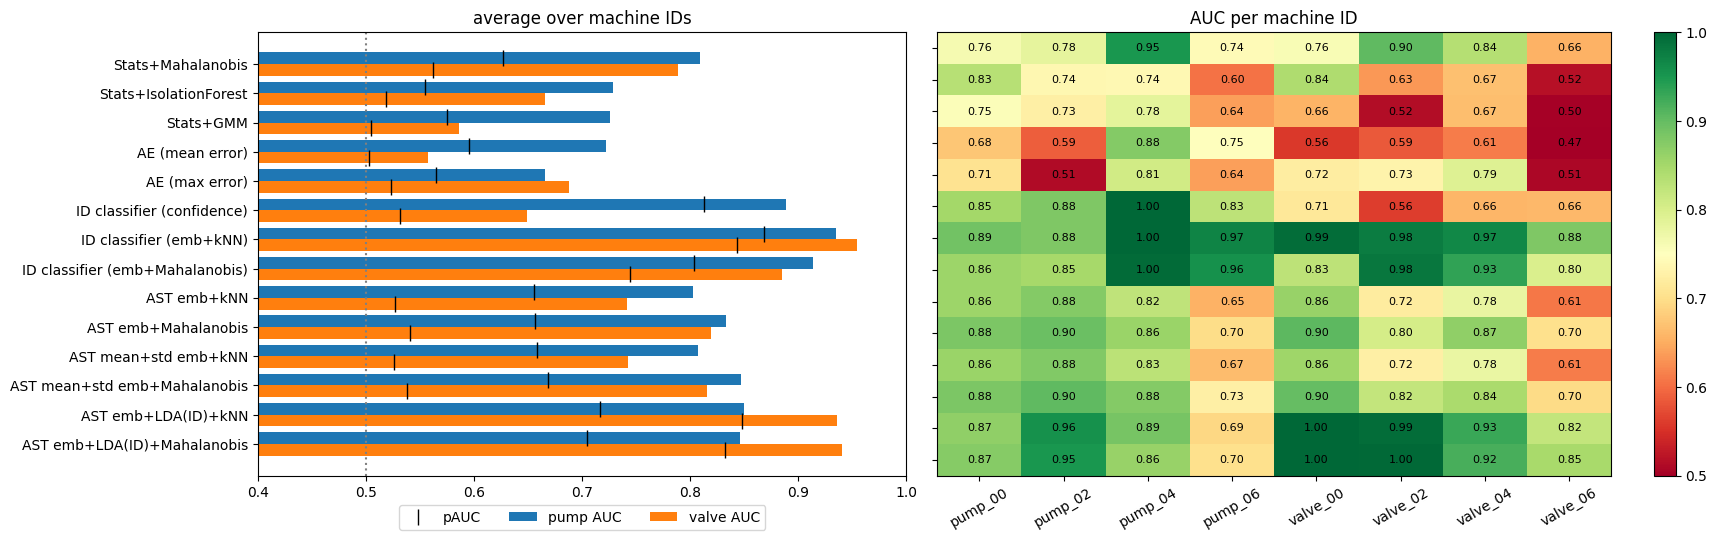

In [34]:
# 比較の図: 機種別の平均（左）と、個体別のAUC（右）
fig, ax = plt.subplots(1, 2, figsize=(18, 5.5), gridspec_kw=dict(width_ratios=[1, 1.3]))
names = list(results)
yy = np.arange(len(names))
ax[0].barh(yy - 0.2, summary.pump_auc, 0.4, label="pump AUC")
ax[0].barh(yy + 0.2, summary.valve_auc, 0.4, label="valve AUC")
ax[0].plot(summary.pump_pauc, yy - 0.2, "k|", ms=12, label="pAUC")
ax[0].plot(summary.valve_pauc, yy + 0.2, "k|", ms=12)
ax[0].axvline(0.5, color="gray", ls=":")
ax[0].set_yticks(yy); ax[0].set_yticklabels(names); ax[0].invert_yaxis(); ax[0].set_xlim(0.4, 1.0)
ax[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=3)
ax[0].set_title("average over machine IDs")

A = np.array([results[n].auc.values for n in names])
im = ax[1].imshow(A, vmin=0.5, vmax=1.0, cmap="RdYlGn", aspect="auto")
for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        ax[1].text(j, i, f"{A[i, j]:.2f}", ha="center", va="center", fontsize=8)
ax[1].set_xticks(range(len(UNITS))); ax[1].set_xticklabels(UNITS, rotation=30)
ax[1].set_yticks(yy); ax[1].set_yticklabels([])
ax[1].set_title("AUC per machine ID"); plt.colorbar(im, ax=ax[1])
plt.tight_layout(); plt.show()

この実行で得られた結果を、表にまとめておく（個体別AUCの、機種ごとの平均）

| 手法 | ポンプ AUC | ポンプ pAUC | バルブ AUC | バルブ pAUC | 平均 AUC | 平均 pAUC |
| --- | --- | --- | --- | --- | --- | --- |
| 統計量＋マハラノビス距離 | 0.810 | 0.627 | 0.788 | 0.562 | 0.799 | 0.594 |
| 統計量＋Isolation Forest | 0.728 | 0.553 | 0.666 | 0.519 | 0.697 | 0.536 |
| 統計量＋GMM | 0.723 | 0.576 | 0.585 | 0.505 | 0.654 | 0.541 |
| AutoEncoder（誤差の平均） | 0.718 | 0.601 | 0.556 | 0.502 | 0.637 | 0.552 |
| AutoEncoder（誤差の最大値） | 0.663 | 0.579 | 0.682 | 0.521 | 0.673 | 0.550 |
| 識別型（確信度） | 0.880 | 0.813 | 0.656 | 0.533 | 0.768 | 0.673 |
| 識別型（埋め込み＋k近傍法） | **0.932** | **0.873** | **0.952** | **0.851** | **0.942** | **0.862** |
| 識別型（埋め込み＋マハラノビス距離） | 0.908 | 0.805 | 0.882 | 0.745 | 0.895 | 0.775 |
| AST（埋め込み＋k近傍法） | 0.803 | 0.655 | 0.742 | 0.527 | 0.772 | 0.591 |
| AST（埋め込み＋マハラノビス距離） | 0.833 | 0.656 | 0.819 | 0.541 | 0.826 | 0.599 |
| AST（平均＋標準偏差、k近傍法） | 0.808 | 0.658 | 0.742 | 0.526 | 0.775 | 0.592 |
| AST（平均＋標準偏差、マハラノビス距離） | 0.847 | 0.669 | 0.816 | 0.539 | 0.831 | 0.604 |
| AST＋個体IDによる射影（k近傍法） | 0.850 | 0.716 | 0.936 | 0.848 | 0.893 | 0.782 |
| AST＋個体IDによる射影（マハラノビス距離） | 0.847 | 0.704 | 0.941 | 0.832 | 0.894 | 0.768 |

- 条件: DCASE 2020 Task 2 開発用データのポンプとバルブ、各4個体 学習用の正常音の9割で学習し、テスト用データで評価
- AutoEncoderの2行は、最初の実装（機種ごとのモデル、3000ステップ）の値である 確認実験で個体ごとのモデルにした場合は、ポンプ0.848（`bias`）、バルブ0.844（最大値）まで上がる
- GPUやライブラリの版が違う環境では、学習を伴う手法の数値が0.01程度ずれることがある
- この表は、本テキストの設定での結果である コンテストの上位の手法は、モデルや学習を大きく工夫しており、これより高い

結果からわかること

- **識別型（埋め込み＋k近傍法）が、AUCでもpAUCでも最もよい** 平均AUCは0.942
- **ASTの埋め込みに個体IDによる射影をかけたもの**（0.893〜0.894）が、それに続く ASTの重みは学習していない
- **学習なしのAST**（0.826〜0.831）と、**数秒で終わる統計量＋マハラノビス距離**（0.799）が、その次である
- **AutoEncoder**（0.637〜0.673）は、最初の実装では単純な統計量の基準を下回った 理由は確認実験で見たとおりである
- 上位の手法に共通するのは、**個体のラベルを使っている**ことである ネットワークの大きさや事前学習の規模よりも、「何を手がかりに表現を絞り込むか」が効いている
- 機種による違い
  - 定常音のポンプでは、手法間の差が比較的小さい（0.66〜0.93）
  - 突発音のバルブでは、差が大きい（0.56〜0.95） 時間方向に平均する手法は苦手で、個体のラベルを使う手法だけが高い
- 個体による違い（右の図）
  - 同じ手法でも、個体によってAUCが0.5台から1.0まで変わる
  - `pump_04` はほとんどの手法で検知しやすく、`valve_06` と `pump_06` は多くの手法で難しい
  - **平均だけを見ていると、まったく検知できていない個体を見落とす** 評価は必ず個体別にも見る
- 同じ埋め込みでも、距離の測り方で結果が変わる
  - 識別型の埋め込みではk近傍法が、ASTのそのままの埋め込みではマハラノビス距離がよい
  - どちらがよいかは埋め込みの分布の形で決まり、事前にはわからない 両方を試す

## 部分AUC: なぜ誤報率の低い領域を重視するのか

AUCは、ROC曲線の下の面積であり、誤報率（偽陽性率、FPR）が0から1までの全範囲を等しく数える
しかし、現場で使える範囲はその一部でしかない

- 異常検知は、ほとんどの時間、正常な音を判定し続ける
- 誤報率が20%の検知器は、5回に1回は誤って警報を出す
- 誤報が多いと、担当者は警報を信用しなくなり、やがて確認しなくなる いわゆる**オオカミ少年**の状態である
- つまり、誤報率が高い領域で検知率がいくら高くても、その設定は使われない

そこで、**誤報率が低い範囲だけで測ったAUC**を使う これを**部分AUC**（partial AUC、pAUC）と呼ぶ
- DCASEの異常音検知では、誤報率0〜0.1の範囲のpAUCを、AUCと並ぶ評価指標にしている
- 本テキストでも同じ範囲を使う `roc_auc_score(y, s, max_fpr=0.1)` で計算できる
  - この関数は、でたらめな検知器が0.5、完全な検知器が1.0になるように値を換算して返す

AUCが同じでも、ROC曲線の左端の立ち上がり方によってpAUCは大きく変わる

<img src="https://class.west.sd.keio.ac.jp/dataai/text/asd-pauc-region.png" width=480>

上の図は、pAUCが見る範囲（色を付けた部分）を示している
- 検知器Aと検知器Bは、曲線全体の下の面積（AUC）には大きな差が無い
- しかし、誤報率が低い左端では、Aの方が検知率が高い 現場で使えるのはこの範囲なので、Aの方が役に立つ

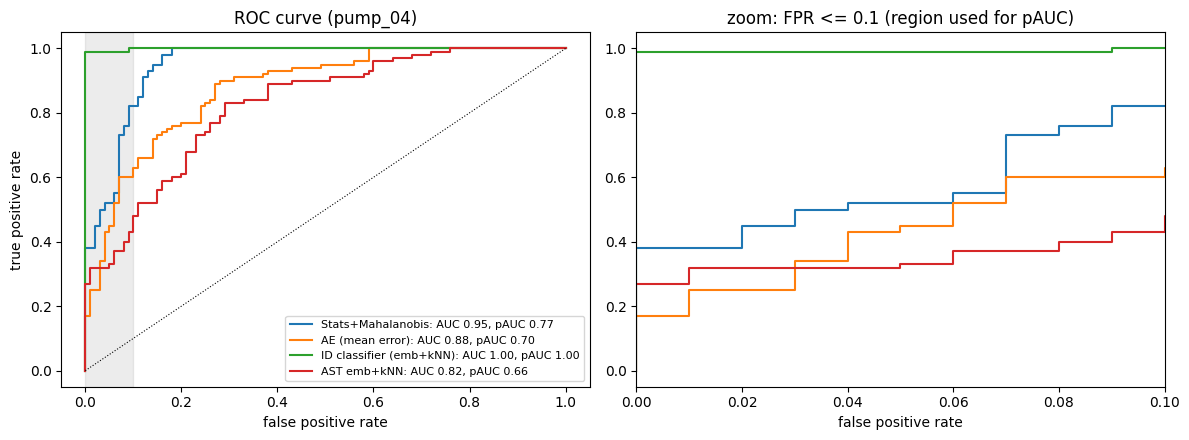

In [35]:
# ROC曲線の左端（誤報率10%以下）を拡大して、AUCと部分AUCの違いを見る
u = "pump_04"
te = rows_of("test", unit=u); y = meta.label.values[te]
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for name in ["Stats+Mahalanobis", "AE (mean error)", "ID classifier (emb+kNN)", "AST emb+kNN"]:
    fpr, tpr, _ = roc_curve(y, scores[name][te])
    lab = f"{name}: AUC {roc_auc_score(y, scores[name][te]):.2f}, pAUC {roc_auc_score(y, scores[name][te], max_fpr=0.1):.2f}"
    ax[0].plot(fpr, tpr, label=lab); ax[1].plot(fpr, tpr, label=name)
ax[0].axvspan(0, 0.1, color="gray", alpha=0.15); ax[0].plot([0, 1], [0, 1], "k:", lw=0.8)
ax[0].set_title(f"ROC curve ({u})"); ax[0].set_xlabel("false positive rate"); ax[0].set_ylabel("true positive rate"); ax[0].legend(fontsize=8)
ax[1].set_xlim(0, 0.1); ax[1].set_title("zoom: FPR <= 0.1 (region used for pAUC)"); ax[1].set_xlabel("false positive rate")
plt.tight_layout(); plt.show()

図の読み方（個体 `pump_04` の例）

- 左図の灰色の部分が、誤報率0.1以下の範囲である pAUCはこの範囲だけで計算する
- 右図は、その範囲を拡大したものである
- 統計量＋マハラノビス距離は、AUCは0.95と高いが、pAUCは0.77にとどまる
  - 誤報率を上げていけばほとんどの異常を見つけられるが、誤報率を数%に抑えると検知率は4〜5割になる
- AutoEncoderは、AUC 0.87に対してpAUC 0.71、ASTのk近傍法は、AUC 0.82に対してpAUC 0.66
- 識別型は、AUCもpAUCも1.00で、誤報がほぼ0の点から検知率が1に近い

AUCだけで手法を選ぶと、**現場で使う設定での性能を見誤る**
AUCとpAUCは、必ず両方を報告する

## しきい値の決め方

ここまでは、しきい値を決めずにスコアの良し悪しだけを比べてきた
実際に警報を出すには、しきい値を決めなければならない

異常音が手元に無い以上、しきい値は**正常音のスコアだけ**から決めることになる
- 検証用の正常音（学習に使っていないもの）のスコアを並べる
- その**分位点**をしきい値にする
  - 95%点にすれば、正常音の約5%がしきい値を超える つまり誤報率を約5%に設定したことになる
- 検知率がいくらになるかは、異常が来てみるまでわからない

<img src="https://class.west.sd.keio.ac.jp/dataai/text/asd-threshold-quantile.png" width=600>

上の図は、この決め方を示している 手元にあるのは正常音のスコアの分布だけで、その上位5%の位置に線を引く

最もよかった識別型（埋め込み＋k近傍法）で試す

In [36]:
# しきい値の決め方1: 検証用の正常音のスコアの分位点をしきい値にして、テストでの誤報率と検知率を測る
def threshold_report(name, q=0.95, use_gamma=False):
    rows = []
    for u in UNITS:
        sv = scores[name][rows_of("val", unit=u)]
        if use_gamma:
            thr = spstats.gamma.ppf(q, *spstats.gamma.fit(sv))     # ガンマ分布を当てはめて分位点を求める
        else:
            thr = np.quantile(sv, q)
        te = rows_of("test", unit=u); y = meta.label.values[te]; s = scores[name][te]
        rows.append(dict(unit=u, n_val=len(sv), threshold=thr, fpr=(s[y == 0] > thr).mean(), tpr=(s[y == 1] > thr).mean()))
    return pd.DataFrame(rows)

BEST = "ID classifier (emb+kNN)"
print(threshold_report(BEST, q=0.95).round(3).to_string(index=False))

    unit  n_val  threshold  fpr   tpr
 pump_00     79      0.025 0.10 0.727
 pump_02    105      0.042 0.03 0.369
 pump_04     78      0.030 0.04 0.990
 pump_06     84      0.037 0.03 0.902
valve_00    100      0.034 0.03 0.899
valve_02     62      0.036 0.05 0.908
valve_04    108      0.036 0.03 0.717
valve_06     78      0.020 0.14 0.733


結果の読み方

- 誤報率（`fpr`）は、5%を狙って設定した 実際のテストでは、個体によって1%〜8%とばらつく
  - 検証用の正常音は個体あたり62〜108個しかない その95%点は、上から数個目の値で決まるので、不安定である
  - **しきい値を安定して決めるには、検証用の正常音がもっと必要**である
- 検知率（`tpr`）は、個体によって0.39〜1.00と大きく違う
  - `pump_04` は異常をすべて検知する `pump_02` は4割、`valve_04` と `valve_06` は5〜6割にとどまる
  - 同じ手法、同じ誤報率の設定でも、個体によって見逃しの多さが大きく違う

## 誤報率から逆算する

「誤報率5%」は妥当な設定だろうか
10秒ごとに判定を続けると、1日の判定回数は8640回になる
- 誤報率5%なら、1日に約430回の誤報が出る これでは使えない
- 「誤報は1日に1回まで」と決めるなら、必要な誤報率は約0.012%、分位点にして99.988%点である

しかし、この分位点を検証用データから直接求めることはできない
- 検証用の正常音は、個体あたり100個程度しかない
- 100個のデータから求められるのは、せいぜい99%点までである それより上は、最大値を返すだけになる

対処の1つは、スコアの分布に**確率分布を当てはめて、外側へ延長する**ことである
- DCASEの基準の手法では、ガンマ分布を当てはめている
- ただし、分布の裾の形が合っている保証は無い

In [37]:
# しきい値の決め方2: 許せる誤報の回数から、必要な誤報率と分位点を逆算する
clip_sec = 10.0
judgments_per_day = 24 * 3600 / clip_sec
for alarms_per_day in [100, 10, 1]:
    target_fpr = alarms_per_day / judgments_per_day
    print(f"{alarms_per_day:4d} false alarms/day -> FPR per judgment {target_fpr:.5f} -> quantile {1 - target_fpr:.5f}")

# 分位点を上げていったとき、経験分位点とガンマ分布の当てはめで、誤報率と検知率がどうなるか
rows = []
for q in [0.9, 0.95, 0.99, 0.999, 1 - 1 / judgments_per_day]:
    for g in [False, True]:
        r = threshold_report(BEST, q, use_gamma=g)
        rows.append(dict(quantile=f"{q:.5f}", method="gamma fit" if g else "empirical", fpr=r.fpr.mean(), tpr=r.tpr.mean()))
print(pd.DataFrame(rows).round(3).to_string(index=False))

 100 false alarms/day -> FPR per judgment 0.01157 -> quantile 0.98843
  10 false alarms/day -> FPR per judgment 0.00116 -> quantile 0.99884
   1 false alarms/day -> FPR per judgment 0.00012 -> quantile 0.99988
quantile    method   fpr   tpr
 0.90000 empirical 0.116 0.859
 0.90000 gamma fit 0.071 0.615
 0.95000 empirical 0.056 0.781
 0.95000 gamma fit 0.051 0.542
 0.99000 empirical 0.022 0.603
 0.99000 gamma fit 0.021 0.425
 0.99900 empirical 0.012 0.494
 0.99900 gamma fit 0.011 0.317
 0.99988 empirical 0.012 0.489
 0.99988 gamma fit 0.005 0.260


結果の読み方

- 経験分位点（`empirical`）は、99%点より先では頭打ちになる
  - 99.9%点も99.988%点も、検証用データの最大値とほぼ同じになり、実際の誤報率は1.5%前後から下がらない
  - **手元のデータの数で決まる限界より厳しい誤報率は、経験分位点では設定できない**
- ガンマ分布の当てはめ（`gamma fit`）は、外側へ延長するので、誤報率をさらに下げられる
  - 99.988%点で、実際の誤報率は0.4%まで下がる それでも、狙った0.012%には遠い
  - 当てはめた分布の裾が、実際のスコアの裾より軽いためである
- 誤報率を下げるほど、検知率も下がる
  - 誤報率約4%（経験分位点の95%点）で検知率0.72、誤報率約3%（99%点）で0.58、ガンマ分布の99.988%点では0.29
  - 「誤報を1日1回に抑える」という要求は、この検知器の1回の判定だけでは、検知率を大きく犠牲にしなければ満たせない

しきい値について、ここまでのまとめ

- しきい値の一般的な決め方は、「MLライブラリの基礎」の章の「費用を考慮したしきい値の決定」も参照
- 異常スコアは確率ではない 「スコア0.05」は「異常である確率が5%」を意味しない 確率として読める値にするには校正が要る（同章の「確率の校正」を参照）が、校正には異常のデータが必要である

- しきい値は、学習に使っていない正常音のスコアから決める
- 許せる誤報の回数から、必要な誤報率を逆算する
- 厳しい誤報率を1回の判定だけで達成するのは難しい 第4部で、複数回の判定を組み合わせて誤報を抑える方法を扱う
- 異常音が少しでも手に入ったら、それを使って検知率を確認し、しきい値を見直す

---

# 判断の根拠を見る

異常スコアは1つの数値でしかない
警報が出たとき、担当者が知りたいのは「**いつ、どの周波数が、いつもと違ったのか**」である
- 根拠が見えれば、原因の部品を推測できる（第2部の知識が役に立つ）
- 根拠が機械と無関係な場所（環境雑音など）にあれば、誤報だと判断できる
- 検知器そのものの点検にもなる

## 再構成誤差の地図

AutoEncoderは、根拠を示しやすい手法である
- 再構成誤差は、時間と周波数の各点について計算される
- それをそのまま地図として描けば、どこが復元できなかったかがわかる

バルブの正常音と異常音を比べる

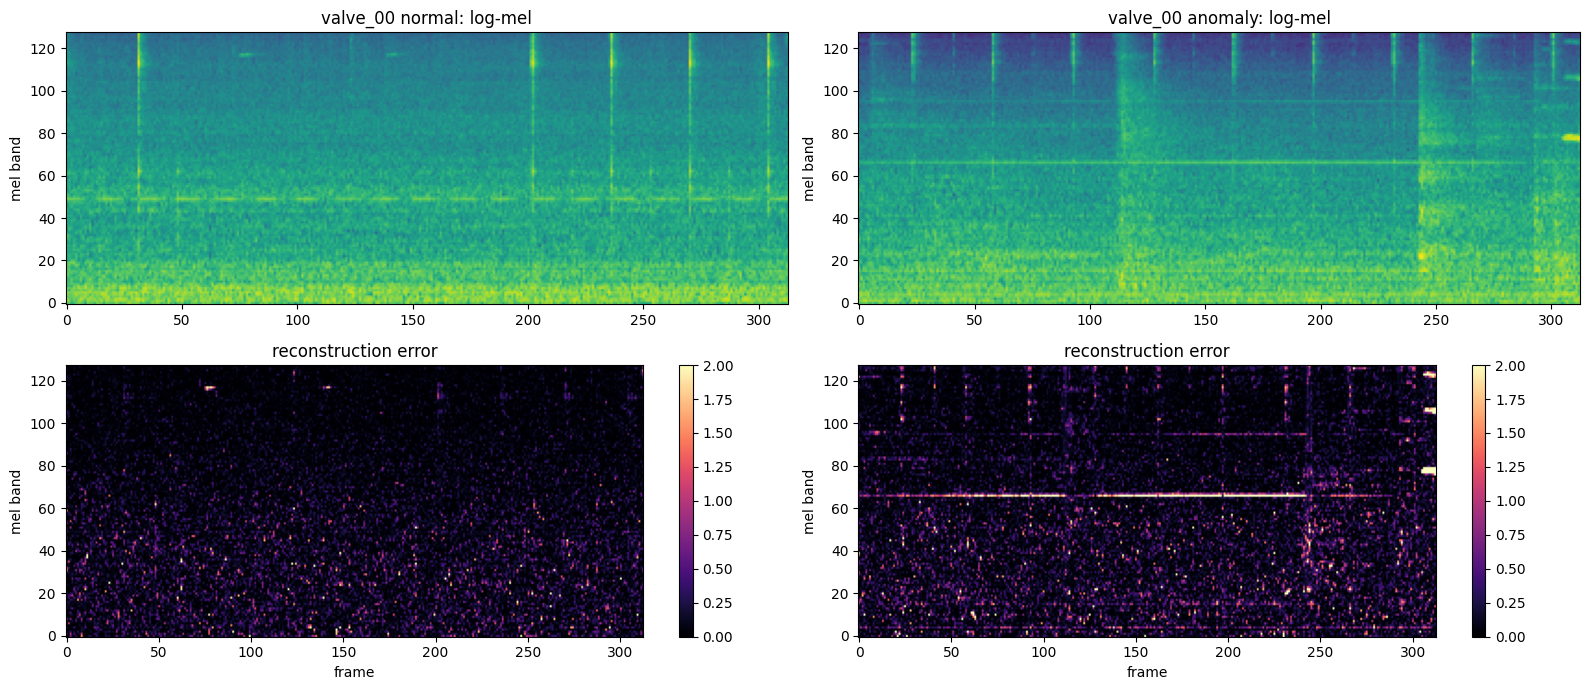

In [38]:
# 根拠の可視化1: AutoEncoderの再構成誤差を、時間と周波数の地図として描く
@torch.no_grad()
def ae_error_map(model, norm, lm_clip):
    # 連結フレームごとの誤差を、各フレームの位置に戻して平均する  戻り値: (メル数, T)
    x = all_frame_vectors(((lm_clip[None] - norm[0]) / norm[1]).to(device))[0]      # (T-N_CTX+1, N_CTX×メル数)
    err = ((model(x) - x) ** 2).view(-1, N_CTX, N_MELS).cpu()
    out = torch.zeros(lm_clip.shape[1], N_MELS); cnt = torch.zeros(lm_clip.shape[1], 1)
    for c in range(N_CTX):
        out[c:c + err.shape[0]] += err[:, c]; cnt[c:c + err.shape[0]] += 1
    return (out / cnt).T.numpy()

u = "valve_00"
te = rows_of("test", unit=u); y = meta.label.values[te]
k_anom = te[y == 1][np.argmax(scores["AE (max error)"][te][y == 1])]     # 誤差の最大値が最も大きい異常音
k_norm = te[y == 0][0]
fig, ax = plt.subplots(2, 2, figsize=(16, 7))
for j, (k, title) in enumerate([(k_norm, "normal"), (k_anom, "anomaly")]):
    ax[0, j].imshow(LM[k].numpy(), origin="lower", aspect="auto", vmin=-70, vmax=0)
    ax[0, j].set_title(f"{u} {title}: log-mel"); ax[0, j].set_ylabel("mel band")
    im = ax[1, j].imshow(ae_error_map(*ae_models["valve"], LM[k]), origin="lower", aspect="auto", vmin=0, vmax=2, cmap="magma")
    ax[1, j].set_title("reconstruction error"); ax[1, j].set_xlabel("frame"); ax[1, j].set_ylabel("mel band")
    plt.colorbar(im, ax=ax[1, j])
plt.tight_layout(); plt.show()

図の読み方

- 上段が入力の対数メルスペクトログラム、下段が再構成誤差である 明るいほど誤差が大きい
- 正常音（左）では、誤差は全体に薄く散らばっている これは復元できない雑音の分である
- 異常音（右）では、**帯域65付近に、時間方向に長く伸びた明るい線**が見える
  - 入力を見ると、同じ位置に、正常音には無い細い横線がある 一定の高さの音が鳴り続けている
  - 右端の高い帯域にも、明るい点がある
- この音は、弁の開閉の音（縦の筋）も正常音と違って見えるが、誤差の地図で最も目立つのは横線の方である
- AutoEncoderは、平均スコアでは検知が苦手だったが、**誤差の地図は「どこがいつもと違うか」を示す道具として役に立つ**

## 遮蔽による感度分析

識別型の手法や事前学習済みモデルでは、誤差の地図は直接は得られない
そこで、どの手法にも使える方法として、**遮蔽**（occlusion）による感度分析を使う

- 入力のスペクトログラムの一部（ここでは16帯域×16フレームの区画）を、「いつもの音」（その個体の正常音の平均）で塗りつぶす
- 塗りつぶした入力で異常スコアを計算し直す
- **スコアが大きく下がった区画が、異常の根拠**である その区画を正常に戻すと異常でなくなる、ということだからである
- すべての区画について繰り返し、スコアの下がり幅を地図にする

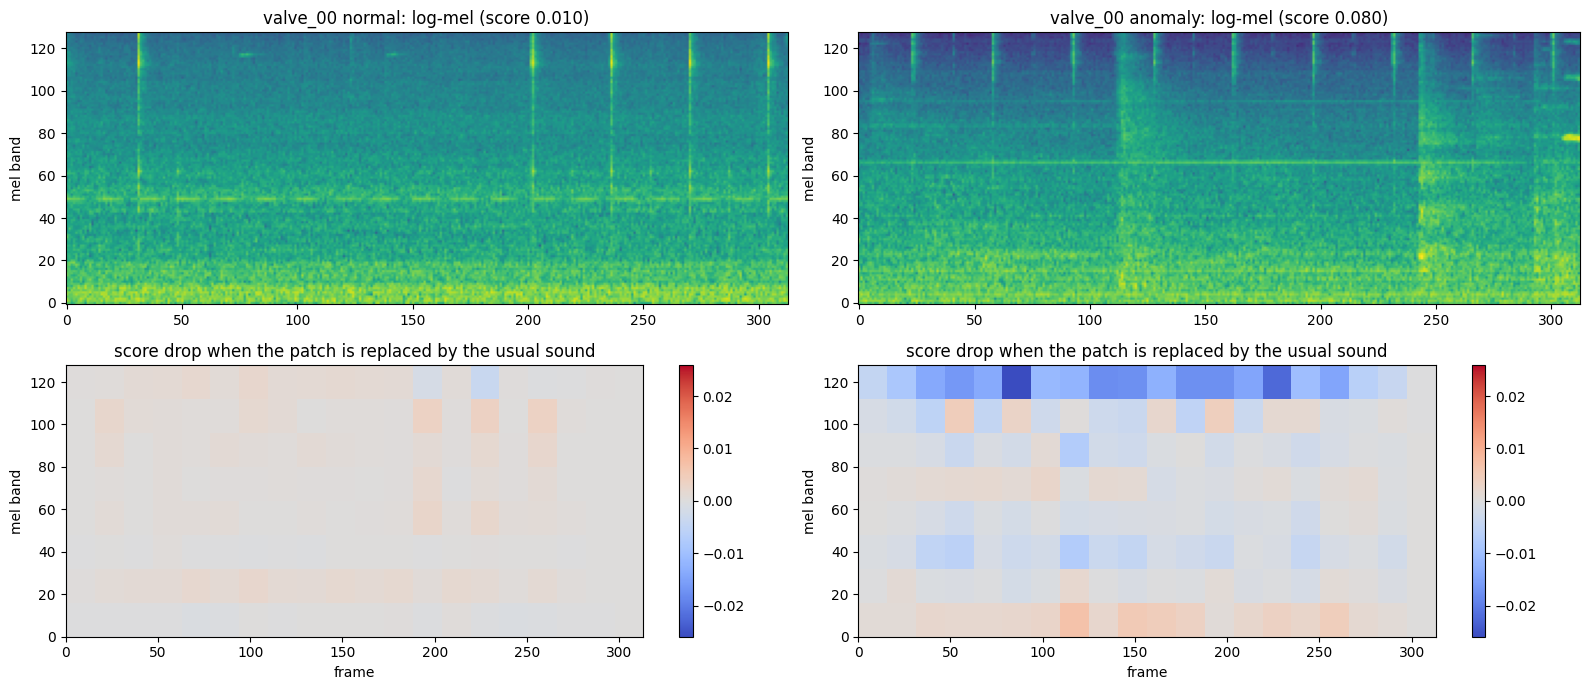

In [39]:
# 根拠の可視化2: 入力の一部を「いつもの音」で塗りつぶし、スコアがどれだけ下がるかを調べる（遮蔽による感度分析）
def occlusion_map(lm_clip, unit, ph=16, pw=16):
    tr = rows_of("train", unit=unit)
    base = LM[tr].mean((0, 2))                       # その個体の正常音の、帯域ごとの平均
    M, T = lm_clip.shape
    variants = [lm_clip]
    for i in range(0, M, ph):
        for j in range(0, T, pw):
            v = lm_clip.clone()
            v[i:i + ph, j:j + pw] = base[i:i + ph, None]
            variants.append(v)
    _, e = idnet_outputs(idnet, id_norm, torch.stack(variants))
    s = knn_score(id_emb[tr], e)
    return (s[0] - s[1:]).reshape(M // ph, -1), s[0]   # スコアの下がり幅  正の値: その領域が異常の根拠

fig, ax = plt.subplots(2, 2, figsize=(16, 7))
omaps = [occlusion_map(LM[k], u) for k in (k_norm, k_anom)]
vmax = np.abs(omaps[1][0]).max()
for j, (k, title) in enumerate([(k_norm, "normal"), (k_anom, "anomaly")]):
    omap, s0 = omaps[j]
    ax[0, j].imshow(LM[k].numpy(), origin="lower", aspect="auto", vmin=-70, vmax=0)
    ax[0, j].set_title(f"{u} {title}: log-mel (score {s0:.3f})"); ax[0, j].set_ylabel("mel band")
    im = ax[1, j].imshow(omap, origin="lower", aspect="auto", cmap="coolwarm", vmin=-vmax, vmax=vmax,
                         extent=[0, LM.shape[2], 0, N_MELS])
    ax[1, j].set_title("score drop when the patch is replaced by the usual sound"); ax[1, j].set_xlabel("frame"); ax[1, j].set_ylabel("mel band")
    plt.colorbar(im, ax=ax[1, j])
plt.tight_layout(); plt.show()

図の読み方

- 赤い区画は、そこを「いつもの音」に戻すとスコアが下がる場所、つまり**異常の根拠になっている場所**である
- 青い区画は、戻すと逆にスコアが上がる場所である
- 正常音（左）は、もとのスコアが約0.01と小さく、どの区画を変えてもほとんど動かない
- 異常音（右、スコア約0.09）では、**最も低い帯域（0〜16）が、ほぼ全時間にわたって赤い**
  - 入力を見ると、この音は低い帯域のエネルギーの出方が正常音と違っている（正常音は一様に明るいが、異常音はまだらである）
  - 帯域96〜112にも、赤い区画がいくつかある
  - 再構成誤差の地図が強く反応した帯域65の横線には、こちらはあまり反応していない
- 最も高い帯域（112〜128）は青い ここを正常音の平均で塗ると、スコアが上がる
  - 塗りつぶしによって、周囲とつながらない不自然な入力ができたため、とも考えられる
  - **青い区画は「正常らしい場所」を意味するとは限らない** 遮蔽という操作そのものの副作用が混ざる
- 1区画あたりのスコアの下がり幅は、最大でも0.01程度で、もとのスコアの1割ほどである
  - この異常は、1か所ではなく、広い範囲の違いの積み重ねとして検知されている

2つの手法は、同じ異常音の**別の場所**を根拠にしている
- どちらかが間違っているのではなく、手法によって「いつもと違う」の捉え方が違う
- 複数の手法の根拠を並べて見ると、音のどこに変化があるかを多面的に知ることができる
- 「音を見て、聞く」の節で書き留めた、自分の耳で聞いた違いと照らし合わせてみるとよい 検知器が反応した場所は、耳で気づいた違いと同じだろうか

根拠の可視化を使うときの注意

- 地図は「モデルが何に反応したか」を示すのであって、「機械のどこが壊れたか」を直接示すのではない
- 区画の大きさで見え方が変わる 小さくすると細かく見えるが、1区画を消しただけではスコアが動かなくなる
- 複数の区画が組み合わさって初めて効く場合、1区画ずつ消す方法では捉えられない

---

# 第4部 現場に入れる

第3部では、条件のそろった公開データで、AUC 0.9を超える検知器を作れた
しかし、これを現場に置いてそのまま動くとは限らない
第4部では、現場に入れるときに必ず出会う問題を順に扱う

# ドメインシフトへの対処

## 何が起きるかを実験で示す

第1部で述べた「学習時と運用時で条件が変わる」という問題を、実際に起こしてみる
テスト用の音を加工して、3種類の変化を模擬する

| 条件 | 加工 | 想定する現場の出来事 |
| --- | --- | --- |
| `gain -6dB` | 音量を半分にする | マイクが機械から遠ざかった、マイクを交換した |
| `noise 0dB` | 機械音と同じ大きさの、学習時に無かった雑音を重ねる | 隣に別の機械が設置された |
| `speed +3%` | 再生速度を3%上げる（周波数も3%上がる） | 回転数や負荷の設定が変わった |

- いずれも、機械は**正常なまま**である
- 異常音にも同じ加工をする つまり「新しい条件のもとでの正常と異常」を作る
- 速度の変更は、第2部の `shift` と同じく、すべての周波数成分を同じ比率でずらす

<img src="https://class.west.sd.keio.ac.jp/dataai/text/asd-domain-shift-scores.png" width=620>

実験の前に、何が起きると予想されるかを上の図に示す
- 条件が変わると、機械が正常なままでも、正常音のスコアの分布が大きい方へ動く
- しきい値は元の条件で決めたままなので、動いた分布のうちしきい値を超えた部分がすべて誤報になる

In [40]:
# 録音条件の変化を模した加工: 音量の変化、雑音の重畳、速度（ピッチ）の変更
import zlib

def shift_wave(x, gain_db=0.0, snr_db=None, speed=1.0, seed=0):
    n = len(x)
    if speed != 1.0:
        # 再標本化して同じサンプリング周波数で扱うと、速度と周波数がともにspeed倍になる
        x = np.resize(sps.resample_poly(x, 1000, int(round(1000 * speed))), n)
    if snr_db is not None:
        # 学習時には無かった騒音源: 低域のうなりと、1.2 kHzの連続音
        rng = np.random.default_rng(seed)
        noise = sps.lfilter([1], [1, -0.95], rng.standard_normal(n))
        noise = noise / noise.std() + np.sin(2 * np.pi * 1200 * np.arange(n) / SR)
        x = x + noise * np.sqrt(np.mean(x ** 2) / np.mean(noise ** 2)) * 10 ** (-snr_db / 20)
    return (x * 10 ** (gain_db / 20)).astype(np.float32)

CONDS = {"gain -6dB": dict(gain_db=-6.0), "noise 0dB": dict(snr_db=0.0), "speed +3%": dict(speed=1.03)}

# 検証用とテスト用の全ファイルを、条件ごとに加工して対数メルを計算する
EV = rows_of(["val", "test"])
t0 = time.time()
lm_shift = {c: extract_logmel(meta.path.values[EV].tolist(),
                              wave_fn=lambda p, kw=kw: shift_wave(load_wave(p), seed=zlib.crc32(p.encode()), **kw))
            for c, kw in CONDS.items()}
print({c: tuple(v.shape) for c, v in lm_shift.items()}, f"{time.time() - t0:.0f} s")

{'gain -6dB': (2429, 128, 313), 'noise 0dB': (2429, 128, 313), 'speed +3%': (2429, 128, 313)} 40 s


まず、第3部の「統計量＋マハラノビス距離」の検知器に、加工した音を入力する
- 検知器は元の条件の正常音で作ったまま、変えない
- しきい値も、元の条件の検証用データの95%点のまま、変えない

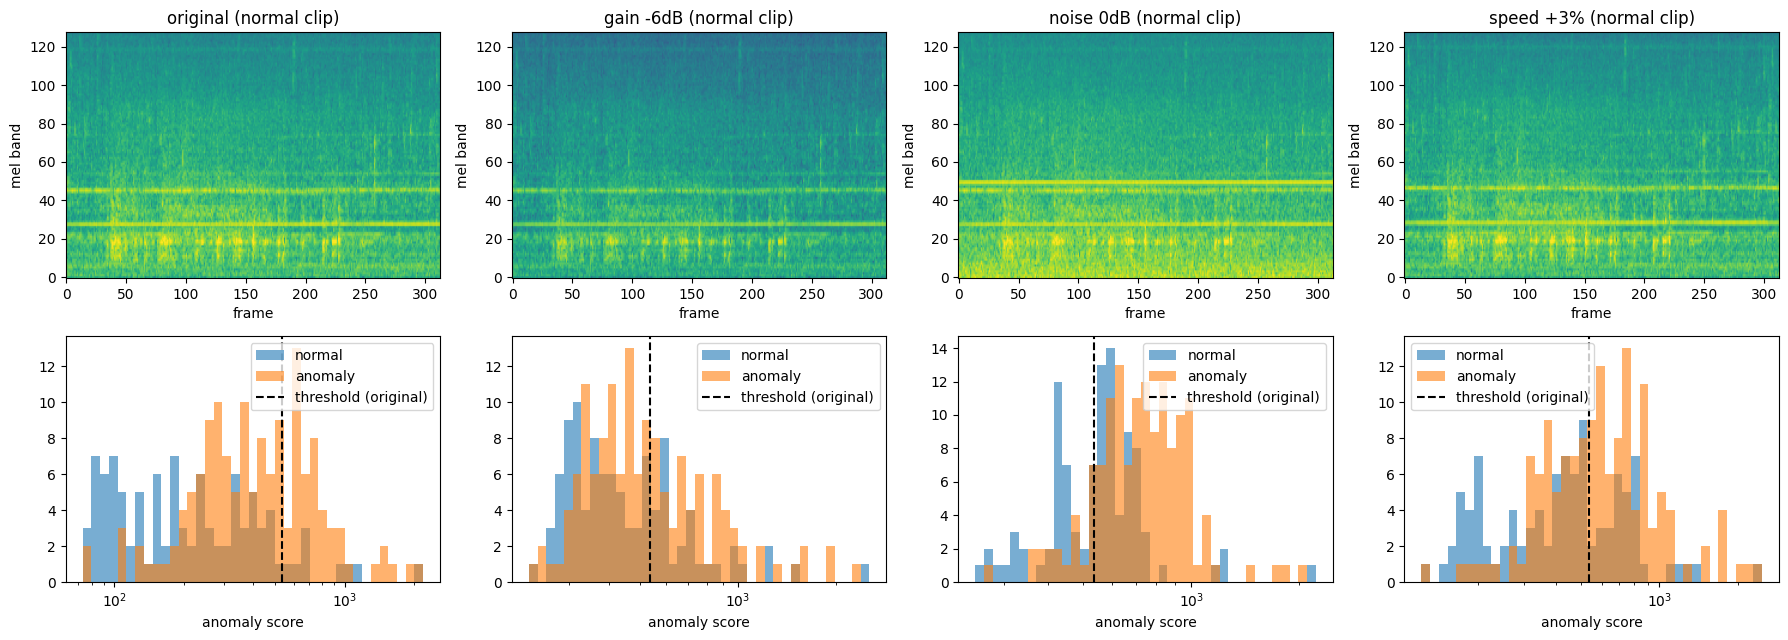

In [41]:
# 条件が変わると、同じ音のスペクトログラムとスコアがどう変わるかを見る
def full_like_meta(values, idx, d=None):
    # idxの行にだけ値を入れた、metaと同じ長さの配列を作る
    out = np.full((len(meta),) + values.shape[1:], np.nan, dtype=np.float32)
    out[idx] = values
    return out

X_shift = {c: full_like_meta(clip_stats(v), EV) for c, v in lm_shift.items()}
s_stat_shift = {c: per_unit(X_stat, fit_maha, X_eval=X_shift[c]) for c in CONDS}

u = "pump_00"
k = rows_of("test", unit=u)[0]
fig, ax = plt.subplots(2, 4, figsize=(18, 6.5))
for j, c in enumerate(["original"] + list(CONDS)):
    S = LM[k] if c == "original" else lm_shift[c][np.where(EV == k)[0][0]]
    ax[0, j].imshow(S.numpy(), origin="lower", aspect="auto", vmin=-70, vmax=0)
    ax[0, j].set_title(f"{c} (normal clip)"); ax[0, j].set_xlabel("frame"); ax[0, j].set_ylabel("mel band")
    s = scores["Stats+Mahalanobis"] if c == "original" else s_stat_shift[c]
    te = rows_of("test", unit=u); y = meta.label.values[te]
    thr = np.quantile(scores["Stats+Mahalanobis"][rows_of("val", unit=u)], 0.95)
    bins = np.geomspace(np.nanmin(s[te]), np.nanmax(s[te]), 40)
    ax[1, j].hist(s[te][y == 0], bins, alpha=0.6, label="normal"); ax[1, j].hist(s[te][y == 1], bins, alpha=0.6, label="anomaly")
    ax[1, j].axvline(thr, color="k", ls="--", label="threshold (original)")
    ax[1, j].set_xscale("log"); ax[1, j].set_xlabel("anomaly score"); ax[1, j].legend()
plt.tight_layout(); plt.show()

図の読み方（個体 `pump_00`）

- 上段は、同じ正常音の、条件ごとのスペクトログラムである
  - `gain -6dB` は全体が暗くなる `noise 0dB` は低域が明るくなり、帯域50付近に新しい横線（1.2kHzの連続音）が入る
  - `speed +3%` は、見た目ではほとんど区別がつかない
- 下段は、テスト用の正常音（青）と異常音（橙）のスコアの分布である 破線は、元の条件で決めたしきい値である
  - 横軸の範囲は図ごとに違う 破線の位置を基準にして、その右にどれだけあるかを見る
  - 元の条件では、正常音の大部分がしきい値の左にある
  - 条件が変わると、**正常音の分布がしきい値の方へ動き、超えるものが増える**
  - 人の目にはほとんど同じに見える `speed +3%` でも、分布は大きく動く

これを全個体について数値にまとめる 見る指標は2つである

- **誤報率**: 新しい条件の正常音が、元のしきい値を超える割合 **運用で最初に困るのはこれ**である
- **AUC**: 新しい条件の正常音と異常音を、スコアで分けられるか しきい値を決め直せば使えるかどうかを表す

In [42]:
# 条件が変わったときの性能を、AUCと誤報率でまとめる関数
def shift_report(name, s_orig, s_by_cond, q=0.95):
    # しきい値は、元の条件の検証用スコアの分位点で決めたまま動かさない
    out = []
    for c, s in [("original", s_orig)] + list(s_by_cond.items()):
        r = []
        for u in UNITS:
            thr = np.quantile(s_orig[rows_of("val", unit=u)], q)
            te = rows_of("test", unit=u); y = meta.label.values[te]
            r.append((roc_auc_score(y, s[te]), (s[te][y == 0] > thr).mean()))
        auc, fpr = np.mean(r, 0)
        out.append(dict(method=name, condition=c, auc=auc, fpr=fpr))
    return pd.DataFrame(out)

def show_shift(reports):
    df = pd.concat(reports)
    order = ["original"] + list(CONDS)
    print("AUC (anomaly vs normal, both under the same condition)")
    print(df.pivot(index="method", columns="condition", values="auc")[order].reindex(df.method.unique()).round(3))
    print("\nFalse alarm rate on normal clips (threshold fixed at the original 95% point)")
    print(df.pivot(index="method", columns="condition", values="fpr")[order].reindex(df.method.unique()).round(3))

shift_reports = [shift_report("Stats+Mahalanobis", scores["Stats+Mahalanobis"], s_stat_shift)]
show_shift(shift_reports)

AUC (anomaly vs normal, both under the same condition)
condition          original  gain -6dB  noise 0dB  speed +3%
method                                                      
Stats+Mahalanobis     0.799      0.757      0.754      0.593

False alarm rate on normal clips (threshold fixed at the original 95% point)
condition          original  gain -6dB  noise 0dB  speed +3%
method                                                      
Stats+Mahalanobis      0.06      0.146      0.293      0.381


結果の読み方

- **誤報率は、設定した約6%から、音量の変化で15%、雑音で29%、速度の変化で38%に増える**
  - 機械は正常なのに、3回に1回は警報が出る これでは使えない
- AUCも下がる 特に速度の変化では0.799から0.593になる
  - 新しい条件のデータでしきい値を決め直しても、正常と異常をうまく分けられない
  - 周波数が3%ずれると、帯域ごとのエネルギーの配分が変わる 正常音どうしのばらつき方も変わり、元の共分散行列が合わなくなる
- わずか3%の速度の違いは、人が聞いてもほとんどわからない **検知器は、人が気づかない条件の変化にも反応する**

## 対処1: 正規化

変化の種類がわかっていて、それを打ち消す変換があるなら、特徴量の段階で取り除くのが最も確実である

- 音量の変化は、対数メルスペクトログラムでは**全体に一定値が足される**だけである（-6dBなら全要素が約6下がる）
- そこで、クリップごとに全体の平均を引く これで音量の違いは消える

In [43]:
# 対処1 正規化: クリップごとに全体の平均レベルを引いてから統計量を計算する
level_norm = lambda lm: lm - lm.mean((1, 2), keepdim=True)
X_stat_n = clip_stats(level_norm(LM))
X_shift_n = {c: full_like_meta(clip_stats(level_norm(v)), EV) for c, v in lm_shift.items()}
shift_reports.append(shift_report("+ level normalization", per_unit(X_stat_n, fit_maha),
                                  {c: per_unit(X_stat_n, fit_maha, X_eval=X_shift_n[c]) for c in CONDS}))
show_shift(shift_reports)

AUC (anomaly vs normal, both under the same condition)
condition              original  gain -6dB  noise 0dB  speed +3%
method                                                          
Stats+Mahalanobis         0.799      0.757      0.754      0.593
+ level normalization     0.787      0.787      0.729      0.581

False alarm rate on normal clips (threshold fixed at the original 95% point)
condition              original  gain -6dB  noise 0dB  speed +3%
method                                                          
Stats+Mahalanobis         0.060      0.146      0.293      0.381
+ level normalization     0.054      0.054      0.166      0.379


結果の読み方

- 音量の変化（`gain -6dB`）に対しては、**完全に効く** 誤報率もAUCも、元の条件と同じ値（0.054、0.787）になる
- 雑音に対しては、誤報率が0.293から0.165に下がるが、まだ高い
- 速度の変化に対しては、まったく効かない（誤報率0.379）
- 元の条件でのAUCは、0.799から0.787にわずかに下がる
  - 音量そのものが異常の手がかりになっている場合、正規化はその手がかりを捨てることになる

正規化は、**狙った種類の変化だけ**を確実に取り除く それ以外の変化には効かない

## 対処2: データ拡張

打ち消す変換が無い変化に対しては、**起こりうる変化を、あらかじめ「正常」として学習させておく**
- 学習用の正常音に、ランダムな音量の変化、雑音、速度の変化を加えたものを作る
- 元の正常音と合わせて「正常」とし、検知器を作り直す
- 音のデータ拡張の基本はG章を参照 ここでは「ラベルを保つ変換」ではなく「**正常であり続ける変化**」を選ぶ点が異なる

拡張の範囲は、音量±9dB、雑音のSN比0〜20dB、速度±5%とする
- テストで使った条件（-6dB、0dB、+3%）を含むが、同じ値そのものではない

In [44]:
# 対処2 データ拡張: 学習用の正常音に、ランダムな音量・雑音・速度の変化を加えたものを作る
def random_aug(p):
    rng = np.random.default_rng(zlib.crc32(p.encode()))
    return shift_wave(load_wave(p), gain_db=rng.uniform(-9, 9), snr_db=rng.uniform(0, 20),
                      speed=rng.uniform(0.95, 1.05), seed=int(rng.integers(1 << 30)))

t0 = time.time()
lm_aug = extract_logmel(meta.path.values[TR].tolist(), wave_fn=random_aug)
print(tuple(lm_aug.shape), f"{time.time() - t0:.0f} s")

# 元の正常音と加工した正常音の両方を「正常」として、検知器を作り直す
X_aug = full_like_meta(clip_stats(lm_aug), TR)
shift_reports.append(shift_report("+ augmentation", per_unit(X_stat, fit_maha, X_extra=X_aug),
                                  {c: per_unit(X_stat, fit_maha, X_eval=X_shift[c], X_extra=X_aug) for c in CONDS}))
show_shift(shift_reports)

(5946, 128, 313) 87 s
AUC (anomaly vs normal, both under the same condition)
condition              original  gain -6dB  noise 0dB  speed +3%
method                                                          
Stats+Mahalanobis         0.799      0.757      0.754      0.593
+ level normalization     0.787      0.787      0.729      0.581
+ augmentation            0.773      0.773      0.791      0.711

False alarm rate on normal clips (threshold fixed at the original 95% point)
condition              original  gain -6dB  noise 0dB  speed +3%
method                                                          
Stats+Mahalanobis         0.060      0.146      0.293      0.381
+ level normalization     0.054      0.054      0.166      0.379
+ augmentation            0.059      0.061      0.016      0.099


結果の読み方

- 誤報率は、3つの条件すべてで大きく下がる（音量0.061、雑音0.016、速度0.099）
- 新しい条件でのAUCも、雑音で0.791、速度で0.711まで戻る
- 代わりに、**元の条件でのAUCは0.799から0.773に下がる**
  - 「正常」とみなす範囲を広げたので、その中に入ってしまう異常が増えた
  - データ拡張は、条件の変化への強さと、検知の鋭さを引き換えにする
- 拡張の範囲は、現場で実際に起こりうる変化に合わせて決める 広げすぎれば、何も検知しなくなる

## 対処3: 少数の新条件データで適応する

条件が変わった後で、新しい条件の正常音を**少しだけ**集められることが多い
- 設定変更の直後や、保全作業の直後は、機械は正常だとわかっている
- その数個の音を使って、正常の基準を移し替える

ここでは最も簡単な方法を試す
- 新しい条件の正常音K個の特徴量の平均と、元の正常音の平均との**差**を求める
- 新しい音の特徴量からその差を引いてから、元の検知器に入力する
- 共分散（ばらつき方）は元のまま使う K個では推定できないからである

In [45]:
# 対処3 少数データでの適応: 新しい条件の正常音をK個だけ使い、正常の中心を移し替える
def adapt_scores(X_new, K=10):
    s = np.full(len(meta), np.nan)
    for u in UNITS:
        tr, va, te = rows_of("train", unit=u), rows_of("val", unit=u), rows_of("test", unit=u)
        score_fn = fit_maha(X_stat[tr])
        delta = X_new[va[:K]].mean(0) - X_stat[tr].mean(0)     # 新旧の条件での、特徴量の平均のずれ
        idx = np.r_[va[K:], te]
        s[idx] = score_fn(X_new[idx] - delta)
        s[va[:K]] = np.nanmedian(s[idx])                        # 適応に使ったクリップは評価から外す（表示用の埋め草）
    return s

for K in [3, 10, 30]:
    shift_reports.append(shift_report(f"+ adaptation (K={K})", scores["Stats+Mahalanobis"],
                                      {c: adapt_scores(X_shift[c], K) for c in CONDS}))
show_shift(shift_reports)

AUC (anomaly vs normal, both under the same condition)
condition              original  gain -6dB  noise 0dB  speed +3%
method                                                          
Stats+Mahalanobis         0.799      0.757      0.754      0.593
+ level normalization     0.787      0.787      0.729      0.581
+ augmentation            0.773      0.773      0.791      0.711
+ adaptation (K=3)        0.799      0.804      0.826      0.694
+ adaptation (K=10)       0.799      0.804      0.825      0.700
+ adaptation (K=30)       0.799      0.802      0.822      0.707

False alarm rate on normal clips (threshold fixed at the original 95% point)
condition              original  gain -6dB  noise 0dB  speed +3%
method                                                          
Stats+Mahalanobis         0.060      0.146      0.293      0.381
+ level normalization     0.054      0.054      0.166      0.379
+ augmentation            0.059      0.061      0.016      0.099
+ adaptation (K=3)    

結果の読み方

- 音量と雑音に対しては、**3個の正常音だけでも**誤報率が大きく下がる（0.082と0.021）
  - AUCも、何もしない場合より高い（0.804と0.826）
  - これらの変化は、特徴量に一定のずれを足すのに近い 平均を移し替えるだけで、ほぼ元に戻る
- 速度の変化に対しては、効き方が悪い
  - K=3では、誤報率が0.451で、何もしない場合（0.381）よりかえって悪い 256次元の平均を3個から推定するので、推定のゆらぎが大きい
  - K=30まで増やしても0.228にとどまる 速度の変化は、平均だけでなく、ばらつき方も変えるからである
- データ拡張と違い、元の条件での性能は変わらない

少数データでの適応は、**いつ条件が変わったかを知っていて、その直後に正常音を集められる**ときに使える
- 設定変更や保全作業の後に、数分間の正常音を録り直す、という運用が現実的である

## 識別型の手法とmixup

同じ実験を、第3部で最もよかった識別型の手法（埋め込み＋k近傍法）でも行う
- 学習が必要な手法では、正規化とデータ拡張は**ネットワークの学習時**に入れる
- あわせて、**mixup** というデータ拡張も試す

mixupは、2つの入力を重み付きで混ぜ、ラベルも同じ重みで混ぜるデータ拡張である

$$ \tilde{x} = \lambda x_i + (1 - \lambda) x_j, \qquad \tilde{y} = \lambda y_i + (1 - \lambda) y_j $$

- $\lambda$ は0〜1の乱数で、ベータ分布から引く
- 個体Aの音と個体Bの音を7対3で混ぜた入力に対して、「Aが70%、Bが30%」と答えるように学習する
- 分類器が極端に高い確信度を出すことを抑え、クラスの境界をなめらかにする効果がある
- 異常音検知の識別型の手法では、補助タスクを難しくして細かい特徴を学ばせる目的でよく使われる

<img src="https://class.west.sd.keio.ac.jp/dataai/text/asd-mixup.png" width=700>

上の図は、$\lambda = 0.7$ の場合の例である 2つの個体の音を7対3で重ね、正解のラベルも同じ比率にする

比べるのは5通りである
- 何もしない（第3部のモデル）
- クリップごとの音量の正規化を入れて学習する
- mixupを入れて学習する
- 波形のデータ拡張（対処2で作ったもの）を加えて学習する
- 波形のデータ拡張とmixupの両方

**実行時間についての注意**
- 次のセルは、CNNの学習を4回行う 第3部の学習の4回分かそれ以上の時間がかかる
- 時間を短くしたい場合は、次のどれかを行う
  - `train_idnet(...)` の呼び出しに `steps=1000` を加える（学習が半分になる 数値は本文と変わる）
  - `id_variants[...] = ...` の行のうち、見たいものだけを残して他をコメントにする
- GPUを使っていることを確かめる（最初のセルの出力が `device: cuda`） CPUでは現実的な時間で終わらない

In [46]:
# 識別型の手法（埋め込み＋k近傍法）でも同じ実験を行う: 何もしない場合、音量の正規化、mixup、波形の拡張、拡張とmixupの両方、の5通り
def idnet_knn_scores(model, norm, lm_ev, bank):
    # lm_ev: EVの行に対応する対数メル  bank: 学習用の正常音（元の条件）の埋め込み
    E, E_ev = full_like_meta(bank, TR), np.full((len(meta), bank.shape[1]), np.nan, dtype=np.float32)
    E_ev[EV] = idnet_outputs(model, norm, lm_ev)[1]
    return per_unit(E, knn_fit, X_eval=E_ev)

same = lambda lm: lm      # 前処理なし

lm_both, y_both = torch.cat([LM[TR].to(device), lm_aug.to(device)]), np.r_[unit_id[TR], unit_id[TR]]   # 連結はGPU上で行い、CPUのRAMを使わない
id_variants = {"ID classifier": (idnet, id_norm, same)}     # 名前 -> (モデル, 正規化の定数, 入力の前処理)
t0 = time.time()
id_variants["ID + level normalization"] = (*train_idnet(level_norm(LM[TR]), unit_id[TR], log=False), level_norm)
id_variants["ID + mixup"] = (*train_idnet(LM[TR], unit_id[TR], mixup=0.5, log=False), same)
id_variants["ID + augmentation"] = (*train_idnet(lm_both, y_both, log=False), same)
id_variants["ID + augmentation + mixup"] = (*train_idnet(lm_both, y_both, mixup=0.5, log=False), same)
print(f"training: {time.time() - t0:.0f} s")
del lm_both                       # 連結した学習データ（約1.9GB）はもう使わないので解放する

id_reports, id_shift_scores = [], {}
for name, (model, norm, pre) in id_variants.items():
    bank = idnet_outputs(model, norm, pre(LM[TR]))[1]
    id_shift_scores[name] = (idnet_knn_scores(model, norm, pre(LM[EV]), bank),
                             {c: idnet_knn_scores(model, norm, pre(lm_shift[c]), bank) for c in CONDS})
    id_reports.append(shift_report(name, *id_shift_scores[name]))
show_shift(id_reports)

training: 931 s
AUC (anomaly vs normal, both under the same condition)
condition                  original  gain -6dB  noise 0dB  speed +3%
method                                                              
ID classifier                 0.944      0.686      0.896      0.827
ID + level normalization      0.927      0.927      0.856      0.824
ID + mixup                    0.924      0.726      0.861      0.789
ID + augmentation             0.920      0.888      0.873      0.912
ID + augmentation + mixup     0.909      0.888      0.877      0.889

False alarm rate on normal clips (threshold fixed at the original 95% point)
condition                  original  gain -6dB  noise 0dB  speed +3%
method                                                              
ID classifier                 0.056      0.836      0.580      0.698
ID + level normalization      0.045      0.045      0.505      0.672
ID + mixup                    0.079      0.835      0.850      0.765
ID + augmentation      

結果の読み方

- **性能の高い識別型の手法は、条件の変化に対して、統計量の手法よりもさらに敏感である**
  - 何もしない場合、誤報率は音量の変化で0.814、雑音で0.655、速度の変化で0.676になる（統計量の手法は0.146、0.293、0.381だった）
  - 新しい条件でのAUCも、音量の変化で0.942から0.705に下がる
- **音量の正規化**は、音量の変化には完全に効く（誤報率0.054、AUC 0.920） 他の変化には効かない
- **波形のデータ拡張**が、最も広く効く
  - 誤報率は0.150、0.155、0.252まで下がり、新しい条件でのAUCは0.890、0.866、0.908に保たれる
  - 元の条件でのAUCは、0.942から0.922に下がる 「正常」の範囲を広げた代償である
- **mixup単独**では、改善が見られない（元の条件で0.924、誤報率も下がらない）
- 波形の拡張とmixupを両方入れると、速度の変化での誤報率は0.195まで下がるが、元の条件でのAUCは0.909に下がる
- データ拡張を入れても、誤報率は設定した値の3〜4倍ある 完全には防げない

予想と違う点が2つある
- 性能の高い手法の方が、条件の変化に弱い
- 異常音検知でよく使われるmixupが、効いていない

この2点を、続く2つの確認実験で調べる

## 確認実験: なぜ識別型は条件の変化に敏感なのか

性能の高い手法の方が、条件の変化に強いことを期待したくなる
実際には逆で、識別型の誤報率は、統計量の手法よりも大きく増えた
理由を2つの数値で確かめる

- 条件が変わったとき、正常音のスコアの中央値が、**元の正常音のばらつき（四分位範囲）の何個分**動いたか
  - 2つの手法はスコアの単位が違うので、それぞれの元のばらつきを物差しにして比べる
- 条件が変わった後も、分類器は「どの個体か」を当てられるか

In [47]:
# 確認実験: 条件が変わったとき、正常音のスコアが「元のばらつきの何個分」動くかを、2つの手法で比べる
def score_move(s_orig, s_by_cond):
    # (条件を変えた正常音の中央値 − 元の正常音の中央値) ÷ 元の正常音の四分位範囲  を個体ごとに求めて平均する
    out = {}
    for c, s in s_by_cond.items():
        r = []
        for u in UNITS:
            te = rows_of("test", unit=u); te = te[meta.label.values[te] == 0]
            q1, q2, q3 = np.quantile(s_orig[te], [0.25, 0.5, 0.75])
            r.append((np.median(s[te]) - q2) / (q3 - q1))
        out[c] = np.mean(r)
    return out

move = pd.DataFrame({"Stats+Mahalanobis": score_move(scores["Stats+Mahalanobis"], s_stat_shift),
                     "ID classifier (emb+kNN)": score_move(*id_shift_scores["ID classifier"])}).T
print("shift of the median normal score, in units of the original interquartile range")
print(move.round(2))

# 条件が変わっても、分類器は「どの個体か」を当てられるか（テスト用の正常音での正解率）
te0 = rows_of("test")[meta.label.values[rows_of("test")] == 0]
pos = np.searchsorted(EV, te0)
acc = {"original": (idnet_outputs(idnet, id_norm, LM[te0])[0].argmax(1) == unit_id[te0]).mean()}
for c in CONDS:
    acc[c] = (idnet_outputs(idnet, id_norm, lm_shift[c][pos])[0].argmax(1) == unit_id[te0]).mean()
print("\nunit ID accuracy on normal test clips:", {k: round(float(v), 3) for k, v in acc.items()})

shift of the median normal score, in units of the original interquartile range
                         gain -6dB  noise 0dB  speed +3%
Stats+Mahalanobis             1.45       2.17       2.35
ID classifier (emb+kNN)      17.52       3.90      10.85

unit ID accuracy on normal test clips: {'original': 0.999, 'gain -6dB': 0.65, 'noise 0dB': 0.979, 'speed +3%': 0.812}


結果の読み方

- 統計量＋マハラノビス距離では、正常音のスコアの中央値は、元のばらつきの1.5〜2.4個分だけ動く
- 識別型（埋め込み＋k近傍法）では、**5.7〜15.9個分**動く 音量の変化では約16個分である
- 分類器が個体を当てる正解率も、元の条件の1.000から、音量の変化で0.642、速度の変化で0.815に下がる
  - 音量が半分になっただけで、3回に1回は別の個体と間違える

**本来はどうなるはずか**
- 表現を学習する手法は、雑音のような「本質でない違い」を無視することを学ぶ、と期待される
- 実際、学習時に含まれていた工場の環境雑音に対しては、その期待どおりに働いた（だから元の条件で高い性能が出た）

**なぜここでは逆に敏感なのか**
- ネットワークが無視することを学ぶのは、**学習データの中で実際に変動していたもの**だけである
  - 環境雑音は、学習データの中でクリップごとに違っていた 個体の識別に役立たないので、無視するようになった
  - 音量、新しい種類の雑音、回転数は、学習データの中では個体ごとにほぼ一定だった ネットワークには、これらを無視する理由が無い
  - それどころか、「この個体はこの音量」「この個体はこの高さ」という違いは、個体を見分ける**手がかりそのもの**である 正解率が音量の変化で大きく下がることが、これを示している
- 識別型の埋め込みは、正常音を**狭い範囲に固めて**置く
  - 同じ個体の正常音どうしが近くに集まるほど、わずかな異常が外れて見える これが高い検知性能の理由である
  - 同じ理由で、わずかな条件の変化でも、固まりの外に出てしまう 元のばらつきが小さいので、同じ大きさの動きが「ばらつきの何個分」で数えると大きくなる
- 統計量＋マハラノビス距離は、正常音のばらつきをそのまま大きな共分散として持っている 鈍い分だけ、条件の変化にも鈍い

**検知の鋭さと、条件の変化への強さは、同じものの裏表である**
- どちらも「正常からのわずかなずれに反応する」ことだからである
- 識別型の手法を現場で使うときは、起こりうる条件の変化を学習データに含めること（データ拡張）が、統計量の手法以上に重要になる

## 確認実験: mixupは効かないのか

上の実験では、mixupは改善をもたらさなかった
しかし、これは1通りの設定を1回学習しただけの結果である
- 学習には実行ごとのゆらぎがある 1回の差が、手法の差なのか、ゆらぎなのかは区別できない
- mixupには、混ぜ方の強さを決めるパラメータ $\alpha$ がある（$\lambda$ を引くベータ分布のパラメータ）
  - 小さいと、$\lambda$ は0か1の近くに偏り、ほとんど混ざらない
  - 1のとき、$\lambda$ は0〜1の一様な乱数になり、強く混ざる
- 本来、mixupは次の効果を持つとされる
  - 分類器が極端に高い確信度を出すことを抑える
  - 補助タスクを難しくして、より細かい特徴を学ばせる

そこで、$\alpha$ を0（mixupなし）、0.2、0.5、1.0の4通り、乱数シードを3通りに変えて、学習を繰り返す
- スコアは、埋め込み＋k近傍法（`knn`）と、確信度（`conf`）の両方を見る
- 検証用の正常音に対する、正しい個体の確信度の平均（`mean_conf`）も記録する

**実行時間についての注意**
- 下のコードは、CNNの学習を11回行う 本テキストで最も時間がかかる処理なので、コードと実行結果を説明として載せてあり、実行はしない
- 実行したい場合は、新しいコードセルに貼り付ける `N_SEEDS = 1` にすると約1/3になる ただし、ばらつき（`std`）は計算できなくなる
- 以降のセルは、この実験の結果を使わない

著者の環境（GPU）では学習に170秒だった（第3部のCNNの学習1回の約9倍） 本文の数値は別のGPUでの実行であり、学習を伴う値は0.01程度ずれる

```
# mixupの効果を調べ直す: 強さ（ベータ分布のパラメータ）を3通り、乱数シードをN_SEEDS通りに変えて学習を繰り返す
N_SEEDS = 3     # 1にすると、所要時間は約1/3になる（ばらつきは見られなくなる）
mix_rows = []
t0 = time.time()
for alpha in [0.0, 0.2, 0.5, 1.0]:
    for seed in range(N_SEEDS):
        if alpha == 0.0 and seed == SEED:
            model, norm = idnet, id_norm                      # 第3部で学習済みのモデルを使う
        else:
            model, norm = train_idnet(LM[TR], unit_id[TR], mixup=alpha, seed=seed, log=False)
        logp, emb = idnet_outputs(model, norm, LM)
        a_knn = machine_auc(per_unit(emb, knn_fit))
        a_conf = machine_auc(-logp[np.arange(len(meta)), unit_id])
        v = rows_of("val")
        mix_rows.append(dict(alpha=alpha, seed=seed, knn_pump=a_knn["pump"], knn_valve=a_knn["valve"],
                             conf_pump=a_conf["pump"], conf_valve=a_conf["valve"],
                             mean_conf=np.exp(logp[v, unit_id[v]]).mean()))
print(f"training: {time.time() - t0:.0f} s")
mix_df = pd.DataFrame(mix_rows)
print(mix_df.drop(columns="seed").groupby("alpha").agg(["mean", "std"]).round(3).to_string())
```

この実行結果は次の通り

```
training: 170 s
      knn_pump        knn_valve        conf_pump        conf_valve        mean_conf       
          mean    std      mean    std      mean    std       mean    std      mean    std
alpha                                                                                     
0.0      0.926  0.008     0.950  0.008     0.886  0.004      0.634  0.024     0.905  0.002
0.2      0.913  0.009     0.925  0.009     0.882  0.023      0.636  0.008     0.886  0.001
0.5      0.919  0.007     0.920  0.023     0.892  0.009      0.673  0.012     0.865  0.000
1.0      0.906  0.007     0.925  0.008     0.884  0.018      0.693  0.008     0.844  0.004
```

結果の読み方 値は3つの乱数シードの平均（`mean`）と標準偏差（`std`）である

**まず、ゆらぎの大きさを知る**
- mixupなし（$\alpha=0$）でも、シードを変えるだけで、k近傍法のAUCは標準偏差0.006〜0.014、確信度のスコアでは最大0.022だけ動く
- これより小さい差は、手法の差とは言えない 先ほどの実験の「0.942対0.924」は、1回ずつの比較であり、これだけでは判断できなかった

**埋め込み＋k近傍法には、mixupは効かない むしろ少し悪くなる**
- ポンプは、0.929（なし）→0.920→0.917→0.908（$\alpha=1.0$）と、強く混ぜるほど下がる
- バルブは、0.947（なし）に対して、どの $\alpha$ でも0.923
- バルブの差（0.024）は、シードによるゆらぎ（0.006〜0.022）と同程度かやや大きい ポンプの $\alpha=1.0$ での差（0.021）も同様である
- 3シードでは確実なことは言えないが、少なくとも**改善する傾向は見られない**

**確信度のスコアには、バルブで効く**
- バルブの確信度のスコアは、0.634（なし）→0.636→0.677→**0.692**（$\alpha=1.0$）と、強く混ぜるほど上がる
- 差（0.058）は、ゆらぎ（0.007〜0.022）の数倍あり、偶然とは考えにくい
- ポンプの確信度のスコアは変わらない（0.883〜0.888）
- 正しい個体に対する確信度の平均（`mean_conf`）は、0.904から0.845へ、$\alpha$ とともに下がる

**なぜ、スコアの種類によって効き方が違うのか**
- mixupの本来の効果は、分類器が極端に高い確信度を出すのを抑えることである `mean_conf` が下がっているので、この効果は確かに出ている
- 第3部で見たとおり、バルブの確信度のスコアが効かなかったのは、確信度が1に張り付いて異常でも下がらないためだった mixupはこの張り付きをゆるめるので、確信度のスコアが改善する
- 埋め込み＋k近傍法は、もともと確信度の張り付きの影響を受けていない mixupが直す問題が、最初から無い
- 逆に、mixupは「2つの個体を混ぜた、実在しない音」を学習データに加える 埋め込みの空間で、個体ごとの正常音の固まりの間を埋めることになり、固まりの外に出た異常を見つけにくくする方向に働いた、と考えられる ただし、この説明は今回の実験では直接確かめていない

**まとめ: mixupが効く条件と効かない条件**

| 条件 | 効果（この実験の範囲で） |
| --- | --- |
| スコアが分類器の確信度で、確信度が1に張り付いている（バルブ） | 効く 強く混ぜるほどよい |
| スコアが分類器の確信度で、mixupなしでもある程度検知できている（ポンプ、0.88） | 変わらない |
| スコアが埋め込みの距離（k近傍法） | 効かない やや悪くなる |
| 学習時に無かった条件の変化（音量、雑音、速度）への強さ | 効かない（前の表） |

- mixupは、分類器の出力（確信度やその変形）をスコアにする識別型の手法（例: Giri et al., 2020）で使われてきた この実験の結果は、その使い方と合っている
- 改善した後でも、確信度のスコア（0.692）は、埋め込み＋k近傍法（0.947）に遠く及ばない この課題では、mixupを足すより、スコアの作り方を変える方が効果が大きい
- **ある工夫が効くかどうかは、それが直す問題が自分の手法に存在するかどうかで決まる** 他の報告で効いた工夫を足す前に、何を直すためのものかを確かめる
- ここで試したのは、同じバッチの中の2つの音を混ぜる最も基本的な形だけである 混ぜる相手の選び方や、損失関数との組合せを変えた場合については、何も言えない

## ドメインシフトについてのまとめ

- 異常検知は「学習時と違う」ことを検知する だから、条件の変化には原理的に弱い
- 性能の高い手法ほど、条件の変化にも敏感に反応することがある
- 対処は、変化の性質によって選ぶ

| 状況 | 対処 |
| --- | --- |
| 変化の種類がわかっていて、打ち消せる（音量など） | 正規化 |
| 変化の種類は予想できるが、打ち消せない（雑音、回転数） | データ拡張 |
| 変化が起きた後で、正常音を少し集められる | 少数データでの適応 |
| 変化が予想できず、いつ起きたかもわからない | 監視して気づく仕組みを作る（運用の節で扱う） |

<img src="https://class.west.sd.keio.ac.jp/dataai/text/asd-shift-remedies.png" width=780>

上の図は、3つの対処が特徴量の空間で何をしているかを模式的に示している
- 正規化は、新しい条件の音を元の位置に戻す
- データ拡張は、「正常」とみなす領域をあらかじめ広げる
- 少数データでの適応は、正常の中心を新しい条件の位置へ移す

- どの対処も、「正常」の範囲を広げることになる 広げすぎれば、本物の異常もその中に入ってしまう
- DCASEの異常音検知の課題も、2021年以降はドメインシフトのある条件での検知を主題にしている

---

# 自分で録音したデータで試す

ここまでの仕組みを、自分で録音した音に適用する
身の回りの機械（扇風機、換気扇、冷蔵庫、ポンプ、3Dプリンタ、PCのファンなど）で試すとよい

## 録音の条件

| 項目 | 目安 | 理由 |
| --- | --- | --- |
| サンプリング周波数 | 16kHz以上 | 16kHzなら8kHzまでの成分を扱える 軸受の共振など高い帯域を見たいなら44.1kHzや48kHzで録り、後で必要に応じて下げる |
| 形式 | WAV（非圧縮）、モノラル | MP3などの圧縮は高域を削り、弱い成分を消す |
| 自動音量調整 | 切る | スマートフォンの録音アプリの自動調整（AGC）や雑音抑制は、音量と雑音を勝手に変える 異常の手がかりを消してしまう |
| マイクの位置 | 固定する | 位置が変わると音が変わる（上のドメインシフトの実験を参照） 三脚やテープで固定し、写真を残す |
| 距離 | 機械の近く（数cm〜数十cm） | 近いほど、周囲の雑音に対して機械の音が大きくなる |
| 1クリップの長さ | 機械の動作の1周期より長く | 定常音なら2〜4秒でもよい 間欠的に動く機械は、1回の動作全体が入る長さにする |
| 音量 | 最大でも振り切れない大きさ | 振り切れる（クリップする）と波形がつぶれ、存在しない高調波が生じる |

<img src="https://class.west.sd.keio.ac.jp/dataai/text/asd-recording-setup.png" width=740>

上の図は、マイクの置き方と、録音のときに確かめる項目をまとめたものである

## 正常データの集め方

- **量**: まず正常音を合計10分以上集める クリップ数が特徴量の次元より少ないと、正常の範囲を推定できない
- **ばらつきを含める**: 1回の連続録音だけにしない
  - 別の時間帯、別の日、機械が冷えているときと温まっているときを含める
  - 連続した録音から切り出したクリップは互いによく似ている 学習用とテスト用は、**別の録音**から取る
  - 同じ録音を切り分けて学習用とテスト用にすると、性能を実際より高く見積もってしまう（「MLライブラリの基礎」の章の「分割の仕方によるリーク：グループ」を参照）
- **正常であることを確かめる**: 録音した時点で機械が正常だったことを記録しておく
- **異常データ**: 評価のために、少数でよいので用意する
  - 安全にできる範囲で、機械に小さな変化を加える（扇風機の羽根にテープを貼る、吸気口を一部ふさぐ、台を変える、など）
  - **機械を壊したり、けがの恐れがあることをしてはならない**
  - 異常が用意できなければ、正常音だけで誤報率を確かめるところまででもよい

## ファイルの置き方

次の構成でファイルを置く

```text
mydata/
  train/normal/    学習用の正常音
  test/normal/     テスト用の正常音（学習用とは別の録音から）
  test/anomaly/    テスト用の異常音（無ければ空でよい）
```

- 長い録音が1本あるだけの場合は、下のセルの `split_recording` で一定の長さのクリップに切り分ける
- `mydata` が無い場合、下のセルは第2部の合成音で仮のデータを作る まずこれで動作を確かめ、その後 `mydata` を自分の録音に置き換える

<img src="https://class.west.sd.keio.ac.jp/dataai/text/asd-mydata-layout.png" width=780>

上の図は、録音からフォルダへの振り分け方を示している 同じ録音から切り出したクリップを、学習用とテスト用の両方に入れてはならない

In [48]:
# 自分のデータを置く場所を用意する  データが無ければ、第2部の合成音で仮のデータを作る
MY_DIR = "mydata"
MY_DUR = 4.0     # 1クリップの長さ [s]

if not os.path.isdir(MY_DIR):
    rng = np.random.default_rng(SEED)
    for sub, n, fault in [("train/normal", 200, None), ("test/normal", 50, None), ("test/anomaly", 50, "bearing")]:
        os.makedirs(os.path.join(MY_DIR, sub), exist_ok=True)
        for i in range(n):
            x = synth_machine(dur=MY_DUR, fault=fault, level=0.3, rng=rng)
            sf.write(os.path.join(MY_DIR, sub, f"{i:03d}.wav"), x, SR)
    print("no recordings found: synthetic sounds were written to", MY_DIR)

def split_recording(path, out_dir, seg=MY_DUR, sr=SR):
    # 長い録音を、seg秒ごとのクリップに切り分けて保存する
    os.makedirs(out_dir, exist_ok=True)
    x, _ = librosa.load(path, sr=sr, mono=True)
    n = int(seg * sr)
    for i in range(len(x) // n):
        sf.write(os.path.join(out_dir, f"{os.path.splitext(os.path.basename(path))[0]}_{i:04d}.wav"), x[i * n:(i + 1) * n], sr)
    return len(x) // n

no recordings found: synthetic sounds were written to mydata


## Colabへのアップロード

Colabで自分の録音を使う方法は3つある

- **画面左のファイル一覧にドラッグする**: 最も簡単 `mydata/train/normal` などのフォルダを作ってから入れる
- **`files.upload()` を使う**: 下のセルで `UPLOAD = True` にして実行すると、フォルダごとにファイル選択の画面が出る
- **Google Driveをマウントする**: ファイルが多い場合に向く G章のデータ読み込みと同じ方法で、`MY_DIR` をDrive上のフォルダに変える

Colabのランタイムを切断すると、アップロードしたファイルは消える 繰り返し使うならDriveに置く

In [49]:
# このセルは実行不要（Colabで、手元のPCから録音ファイルをアップロードするときだけ使う）
UPLOAD = False
if UPLOAD:
    from google.colab import files
    for sub in ["train/normal", "test/normal", "test/anomaly"]:
        print("select files for", sub)
        os.makedirs(os.path.join(MY_DIR, sub), exist_ok=True)
        for name, data in files.upload().items():
            with open(os.path.join(MY_DIR, sub, name), "wb") as f:
                f.write(data)

## パイプラインに流す

まず、最も簡単で学習が速い「統計量＋マハラノビス距離」を使う
- 正常音が少ないことを考え、メル数を64に減らす（特徴量は128次元）
- 学習用の正常音の2割を取り分けておき、しきい値を決めるのに使う

実行したら、最初に次の点を確かめる
- **学習に使った正常音と、使っていない正常音で、スコアの中央値が大きく違わないか**
  - 使っていない方が何倍も大きい場合、正常音が足りないか、特徴量の次元が多すぎる
- **取り分けた正常音と、テスト用の正常音で、スコアが大きく違わないか**
  - テスト用の方が大きい場合、録音の条件が変わっている（ドメインシフト）

train normal 200, test normal 50, test anomaly 50
median score of normal clips: used for fitting 85.3, held out 184.8, test 186.0
threshold (95% point of held-out normal) 243.7 -> false alarm rate on test normal 0.06
AUC 0.951  pAUC 0.840  detection rate at the threshold 0.82


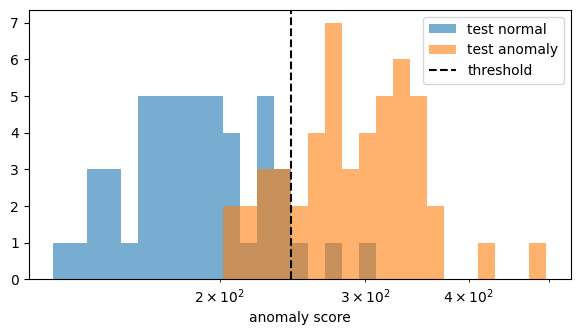

In [50]:
# 自分のデータを、本書のパイプライン（対数メル → 統計量 → マハラノビス距離）に流す
my_fe = make_logmel(n_fft=1024, hop=512, n_mels=64)    # 正常音が少ないので、メル数を減らして次元を抑える

def my_logmel(sub):
    paths = sorted(glob.glob(os.path.join(MY_DIR, sub, "*.wav")))
    return extract_logmel(paths, wave_fn=lambda p: load_wave(p, dur=MY_DUR), fe=my_fe), paths

lm_tr, p_tr = my_logmel("train/normal")
lm_no, p_no = my_logmel("test/normal")
lm_an, p_an = my_logmel("test/anomaly")
print(f"train normal {len(p_tr)}, test normal {len(p_no)}, test anomaly {len(p_an)}")

# 学習用の正常音の2割を取り分けておき、学習に使った音と使っていない音でスコアが大きく違わないかを確かめる
n_fit = int(len(p_tr) * 0.8)
my_score = fit_maha(clip_stats(lm_tr[:n_fit]))
s_fit, s_hold, s_no = my_score(clip_stats(lm_tr[:n_fit])), my_score(clip_stats(lm_tr[n_fit:])), my_score(clip_stats(lm_no))
print("median score of normal clips: used for fitting %.1f, held out %.1f, test %.1f" % (np.median(s_fit), np.median(s_hold), np.median(s_no)))
my_thr = np.quantile(s_hold, 0.95)
print("threshold (95%% point of held-out normal) %.1f -> false alarm rate on test normal %.2f" % (my_thr, (s_no > my_thr).mean()))
if len(p_an) > 0:
    s_an = my_score(clip_stats(lm_an))
    y = np.r_[np.zeros(len(s_no)), np.ones(len(s_an))]
    print("AUC %.3f  pAUC %.3f  detection rate at the threshold %.2f" % (roc_auc_score(y, np.r_[s_no, s_an]), roc_auc_score(y, np.r_[s_no, s_an], max_fpr=0.1), (s_an > my_thr).mean()))
    bins = np.geomspace(min(s_no.min(), s_an.min()), max(s_no.max(), s_an.max()), 30)
    plt.figure(figsize=(7, 3.5))
    plt.hist(s_no, bins, alpha=0.6, label="test normal"); plt.hist(s_an, bins, alpha=0.6, label="test anomaly")
    plt.axvline(my_thr, color="k", ls="--", label="threshold"); plt.xscale("log"); plt.xlabel("anomaly score"); plt.legend(); plt.show()

結果の読み方（合成音で作った仮のデータの場合）

- スコアの中央値は、学習に使った正常音で85.3、取り分けた正常音で184.8、テスト用の正常音で186.0
  - 学習に使った音のスコアは、使っていない音の半分以下である **学習に使った音のスコアからしきい値を決めてはいけない**理由がここにある
  - 取り分けた正常音とテスト用の正常音はほぼ同じなので、条件の変化は無いと判断できる
- 取り分けた正常音の95%点をしきい値にすると、テスト用の正常音の誤報率は0.06で、ほぼ狙いどおりである
- AUCは0.951、pAUCは0.840、しきい値での検知率は0.82

自分の録音に置き換えると、数値はこれとは大きく変わる まず上の2つの確認から始める

自分のデータでうまくいかないときに確かめること

- スペクトログラムを描いて、機械の音が見えているか 雑音しか映っていないなら、マイクを近づける
- 正常音と異常音を自分で聞いて、区別できるか 人が聞いて全くわからない差は、この規模の仕組みでは検知が難しい
- 窓長とメル数を変える（第2部を参照）
- 正常音を増やす 特に、別の日の録音を加える

より性能を求める場合は、第3部の他の手法に差し替える
- 個体が1台だけなら、識別型の補助タスクは作れない 事前学習済みモデルの埋め込みが第一の候補になる
- 複数の個体や複数の運転条件があるなら、それを当てる補助タスクを作れる

---

# 逐次処理と軽量化

## 流れてくる音を窓ごとに判定する

ここまでは、10秒のファイルを1つずつ判定してきた
現場では、マイクからの音が途切れなく流れてくる

- 音を短い**窓**に区切り、窓を少しずつずらしながら、窓ごとに異常スコアを出す
- 窓が短いほど、異常が起きてから警報までの遅れが小さい
- 窓が短いほど、1回の判定に使える情報が少なく、スコアが不安定になる

識別型のモデルは、もともと約2秒（64フレーム）の入力を受け取るように作ってある
これを0.5秒ずつずらして使えば、0.5秒ごとに新しいスコアが得られる
- 参照する正常音の埋め込みも、窓単位のものに作り直す クリップ全体で平均した埋め込みとは分布が違うためである

<img src="https://class.west.sd.keio.ac.jp/dataai/text/asd-streaming-windows.png" width=780>

上の図は、窓の区切り方を示している
- 約2秒の窓を0.5秒ずつずらすので、隣り合う窓は大きく重なる
- 1つの窓が終わるたびに、新しい異常スコアが1つ出る

In [51]:
# 窓ごとの異常スコアを計算する: 約2秒の窓を0.5秒ずつずらし、窓ごとに埋め込みを求めて正常音との距離を測る
WIN_HOP = 16    # 窓をずらすフレーム数（16フレーム = 約0.5秒）

@torch.no_grad()
def window_embeddings(lm, bs=64):
    # lm: (N, メル数, T)  戻り値: (N, 窓の数, 埋め込みの次元)
    out = []
    for i in range(0, len(lm), bs):
        x = ((lm[i:i + bs] - id_norm[0]) / id_norm[1]).to(device)
        crops = x.unfold(2, CROP, WIN_HOP).permute(0, 2, 1, 3)
        out.append(idnet(crops.flatten(0, 1))[1].view(*crops.shape[:2], -1).cpu())
    return torch.cat(out).numpy()

W = {}   # 個体 -> (検証用の窓スコア, テスト用の窓スコア, テスト用のラベル)
for u in UNITS:
    tr, va, te = rows_of("train", unit=u), rows_of("val", unit=u), rows_of("test", unit=u)
    bank = window_embeddings(LM[tr]).reshape(-1, id_emb.shape[1])       # 参照も窓単位の埋め込みにする
    score = lambda idx: knn_score(bank, window_embeddings(LM[idx]).reshape(-1, id_emb.shape[1])).reshape(len(idx), -1)
    W[u] = (score(va), score(te), meta.label.values[te])
print("windows per clip:", W[UNITS[0]][0].shape[1], " reference windows of the last unit:", len(bank))

windows per clip: 16  reference windows of the last unit: 13024


窓ごとのスコアが時間とともにどう動くかを見る
- 正常音6個、異常音3個、正常音3個をこの順につないで、約2分の流れを作る
- 異常音は、スコアが中くらいの、典型的なものを選ぶ

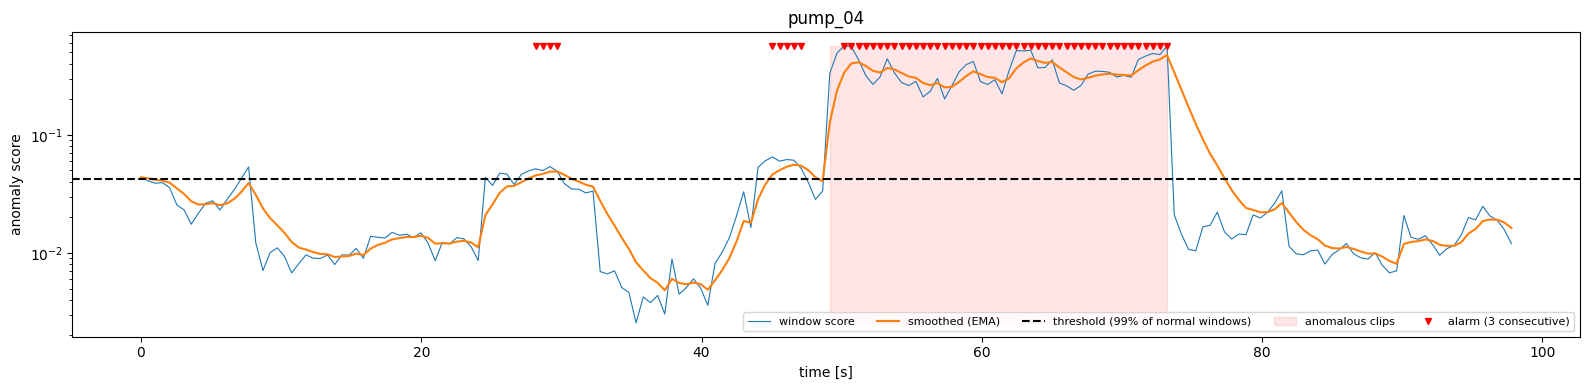

In [52]:
# 流れてくる音を模擬する: 正常6個、異常3個、正常3個のクリップを順につなぎ、窓ごとのスコアを時間順に並べる
def ema(s, alpha=0.3):
    # 指数移動平均による平滑化（最後の軸を時間とみなす）
    out = np.empty_like(s)
    out[..., 0] = s[..., 0]
    for t in range(1, s.shape[-1]):
        out[..., t] = alpha * s[..., t] + (1 - alpha) * out[..., t - 1]
    return out

def consecutive(over, k=3):
    # k回続けてしきい値を超えた時点でTrueにする
    c = np.cumsum(over, -1)
    run = c - np.maximum.accumulate(np.where(over, 0, c), -1)   # 連続して超えている回数
    return run >= k

u = "pump_04"
wv, wt, y = W[u]
an = np.where(y == 1)[0]
an = an[np.argsort(wt[an].mean(1))][len(an) // 2 - 1:len(an) // 2 + 2]      # スコアが中くらいの、典型的な異常音を3個選ぶ
order = np.r_[np.where(y == 0)[0][:6], an, np.where(y == 0)[0][6:9]]
stream, truth = wt[order].ravel(), np.repeat(y[order], wt.shape[1])
thr = np.quantile(wv, 0.99)
t_axis = np.arange(len(stream)) * WIN_HOP * HOP / SR
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(t_axis, stream, lw=0.8, label="window score")
ax.plot(t_axis, ema(stream), lw=1.5, label="smoothed (EMA)")
ax.axhline(thr, color="k", ls="--", label="threshold (99% of normal windows)")
ax.fill_between(t_axis, stream.min(), stream.max(), where=truth == 1, color="red", alpha=0.1, label="anomalous clips")
alarm = consecutive(stream > thr)
ax.plot(t_axis[alarm], np.full(alarm.sum(), stream.max()), "rv", ms=5, label="alarm (3 consecutive)")
ax.set_yscale("log"); ax.set_title(u)
ax.set_xlabel("time [s]"); ax.set_ylabel("anomaly score"); ax.legend(loc="lower right", ncol=5, fontsize=8)
plt.tight_layout(); plt.show()

図の読み方（個体 `pump_04`、縦軸は対数）

- 細い線が窓ごとのスコア、太い線がそれを平滑化したものである 赤く塗った区間が異常音である
- 異常音の区間に入ると、スコアは1〜2窓（約0.5〜1秒）のうちに、正常時の10倍程度まで上がり、警報（赤い三角）が出続ける
- 正常な区間でも、スコアは一定ではなく、10倍近い幅で上下する
- 正常な区間のうち、スコアがしきい値の近くまで上がった箇所（最初の数秒、30秒付近、異常音の直前）でも、警報が出ている **これらは誤報である**
  - しきい値は、正常な窓の99%点に置いてある それでも、約2分の間に数回の誤報が出る
- この個体は、第3部の評価で最も検知しやすかった個体である 他の個体では、ここまではっきりとは分かれない

## 誤報を抑える: 平滑化と連続検知

窓ごとのスコアは、正常な区間でも一瞬だけ跳ね上がることがある
1つの窓がしきい値を超えただけで警報を出すと、誤報が多くなる
機械の異常は、ふつう一瞬では終わらず、しばらく続く この性質を使う

- **平滑化**: スコアの移動平均をとってから、しきい値と比べる
  - ここでは指数移動平均（EMA） $\bar{s}_t = \alpha s_t + (1 - \alpha)\bar{s}_{t-1}$ を使う
  - 一瞬の跳ね上がりはならされ、続く上昇だけが残る
- **連続検知**: k回続けてしきい値を超えたときだけ警報を出す
  - 1回の誤報率が $p$ で、各回が独立なら、k回続く確率は $p^k$ になる
  - 実際には隣り合う窓は重なっていて独立ではないので、ここまでは下がらないが、それでも大きく減る
- どちらも、**警報が遅れる**という代償がある

<img src="https://class.west.sd.keio.ac.jp/dataai/text/asd-smoothing-consecutive.png" width=680>

上の図は、この2つの方法の働きを模式的に描いたものである（実測値ではない）
- 左の一瞬の跳ね上がりは、1つの窓だけで判定すると誤報になる 平滑化したスコアはしきい値に届かず、連続検知でも1回だけなので警報にならない
- 右の異常が続く区間では、数窓の遅れの後に警報が出る

規則ごとに、窓のしきい値を動かしながら、「正常な10秒の間に警報が出る割合」（誤報率）と「異常な10秒の間に警報が出る割合」（検知率）を測る
- 比較のために、16個の窓すべての平均で判定する規則も入れる これは10秒待ってから判定することに相当する

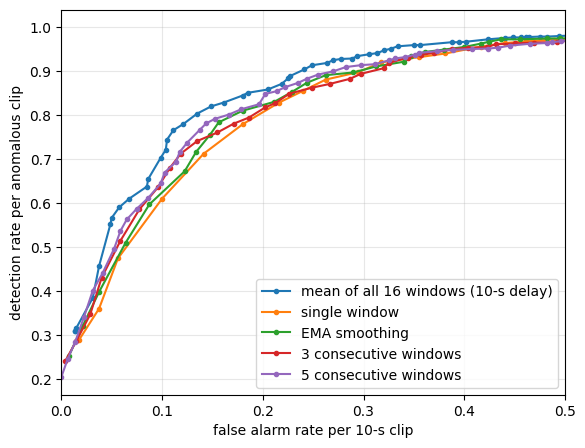

                               rule  fpr_at_q99  tpr_at_q99  tpr_at_fpr5
mean of all 16 windows (10-s delay)       0.015       0.317        0.566
                      single window       0.056       0.474        0.436
                      EMA smoothing       0.038       0.398        0.451
              3 consecutive windows       0.029       0.347        0.475
              5 consecutive windows       0.014       0.284        0.485


In [53]:
# 判定の規則を比べる: 窓のしきい値を動かして、クリップ単位の誤報率と検知率の関係を描く
def rule_curve(rule, qs=np.r_[np.linspace(0.5, 0.99, 50), 0.995, 0.999]):
    # rule(窓スコア, しきい値) -> 各窓で警報を出すか  1クリップ内で1回でも警報が出れば「異常と判定」とする
    pts = []
    for q in qs:
        f, t = [], []
        for u in UNITS:
            wv, wt, y = W[u]
            thr = np.quantile(rule.prep(wv), q)
            hit = rule(rule.prep(wt), thr).any(1)
            f.append(hit[y == 0].mean()); t.append(hit[y == 1].mean())
        pts.append((np.mean(f), np.mean(t)))
    return np.array(pts)

class Rule:
    def __init__(self, prep, decide): self.prep, self.decide = prep, decide
    def __call__(self, w, thr): return self.decide(w > thr)

rules = {"mean of all 16 windows (10-s delay)": Rule(lambda w: np.repeat(w.mean(-1, keepdims=True), w.shape[-1], -1), lambda o: o),
         "single window": Rule(lambda w: w, lambda o: o),
         "EMA smoothing": Rule(ema, lambda o: o),
         "3 consecutive windows": Rule(lambda w: w, lambda o: consecutive(o, 3)),
         "5 consecutive windows": Rule(lambda w: w, lambda o: consecutive(o, 5))}
plt.figure(figsize=(6.5, 5))
rule_rows = []
for name, rule in rules.items():
    c = rule_curve(rule)
    plt.plot(c[:, 0], c[:, 1], marker=".", label=name)
    i99 = 49   # 窓のしきい値を正常の99%点に置いたとき
    rule_rows.append(dict(rule=name, fpr_at_q99=c[i99, 0], tpr_at_q99=c[i99, 1],
                          tpr_at_fpr5=np.interp(0.05, c[::-1, 0], c[::-1, 1])))
plt.xlabel("false alarm rate per 10-s clip"); plt.ylabel("detection rate per anomalous clip"); plt.xlim(0, 0.5); plt.legend(); plt.grid(alpha=0.3)
plt.show()
print(pd.DataFrame(rule_rows).round(3).to_string(index=False))

結果の読み方

- 図は、窓のしきい値を動かしたときの、誤報率と検知率の関係である 左上にあるほどよい
- 表の `fpr_at_q99` と `tpr_at_q99` は、窓のしきい値を正常な窓の99%点に置いたときの値である
- **同じしきい値のままで、誤報が大きく減る**
  - 1つの窓で判定すると、正常な10秒のうち5.2%で警報が出る 1つの窓の誤報率が1%でも、10秒に16回判定するので、どれかが超える確率は高くなる
  - 3回連続にすると2.9%、5回連続にすると1.0%まで下がる
  - 代わりに、検知率も0.458から0.351、0.276へ下がる
- 誤報率を同じ5%にそろえて比べる（`tpr_at_fpr5`）と、検知率は、1つの窓で0.443、平滑化で0.455、3回連続で0.518、5回連続で0.511
  - 連続検知は、同じ誤報率のもとで検知率を少し上げる ただし、図の曲線はほぼ重なっており、差は大きくない
- 16個の窓すべての平均で判定すると、同じ誤報率での検知率は0.559で最も高い
  - 使う情報が多いほど、判定は安定する 代わりに、判定までに10秒かかる
- 連続検知の主な利点は、性能を大きく上げることではなく、**簡単な規則で、誤報の頻度を狙った水準まで下げられる**ことにある
  - 許せる誤報の回数から、kとしきい値を決める
  - どれだけの遅れを許せるかは、異常がどれだけ速く進むかで決まる 数時間かけて進む劣化なら、数分の遅れは問題にならない
- 同じ考え方は、G章の「音響イベント検出」の「しきい値と後処理」（中央値フィルタによる平滑化）でも使った

## 軽量化とエッジ機器への搭載

異常音検知は、機械のそばに置いた小さな機器（エッジ機器）で動かしたいことが多い
- 音をすべてサーバへ送ると、通信量が大きい 16kHz、16ビットで1日に約2.8GBになる
- 工場の音には会話が入ることがあり、外部へ送りたくない
- 通信が切れても監視を続けたい

機器の規模と、載せられるモデルの目安は次のとおりである

| 機器 | 資源の目安 | 載せられるもの |
| --- | --- | --- |
| マイコン（Cortex-Mなど） | メモリ数百kB、演算は整数が中心 | 統計量と距離計算、数万パラメータまでの小さなネットワーク |
| シングルボードコンピュータ（Raspberry Piなど） | メモリ数GB、CPU | 小さなCNN、AutoEncoder |
| GPU付きの組込み機器、サーバ | GPU | 事前学習済みの大きなモデル |

まず、本書で作ったモデルの大きさと、CPUでの処理時間を測る
- 処理時間は実行する機械によって大きく変わるので、モデル間の比を見る

In [54]:
# モデルの大きさと、CPUで10秒の音を処理するのにかかる時間を測る
def n_params(m):
    return sum(p.numel() for p in m.parameters())

@torch.no_grad()
def cpu_time(fn, n=3):
    fn()                              # 1回目は準備の時間が混ざるので捨てる
    t0 = time.perf_counter()
    for _ in range(n):
        fn()
    return (time.perf_counter() - t0) / n

one = LM[:1]
ae_cpu = DenseAE().eval(); ae_cpu.load_state_dict(ae_models["pump"][0].state_dict())
id_cpu = IDNet(len(UNITS)).eval(); id_cpu.load_state_dict(idnet.state_dict())
ast_cpu = ASTModel.from_pretrained(AST_NAME).eval()
x_ast = ast_fe([load_wave(meta.path[0])], sampling_rate=SR, return_tensors="pt").input_values
light_rows = [
    dict(model="DenseAE", params=n_params(ae_cpu), cpu_sec=cpu_time(lambda: ae_cpu(all_frame_vectors(one)[0]))),
    dict(model="IDNet (width 32)", params=n_params(id_cpu), cpu_sec=cpu_time(lambda: id_cpu(one.unfold(2, CROP, WIN_HOP).permute(0, 2, 1, 3)[0]))),
    dict(model="AST", params=n_params(ast_cpu), cpu_sec=cpu_time(lambda: ast_cpu(x_ast))),
]
print(pd.DataFrame(light_rows).to_string(index=False))
del ast_cpu

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

           model   params  cpu_sec
         DenseAE   234392 0.002600
IDNet (width 32)  1261096 0.071565
             AST 86187264 2.672192


- パラメータ数は、全結合のAutoEncoderが約23万、識別型のCNNが約126万、ASTが約8600万である
- CNNはASTの約1/70の大きさで、第3部ではASTより高い性能を出した
- ASTは、CPUでの処理時間もCNNより2桁長い（上の出力を参照 値は実行する機械によって変わる）
- 大きな事前学習済みモデルは、エッジ機器ではなく、サーバ側で使うのが現実的である

軽量化の方法は、大きく3つある

- **モデルを小さく作る**: 層の幅や深さを減らす 最も確実である
- **量子化**（quantization）: 重みを32ビットの浮動小数点数から8ビットの整数に変える 大きさが約1/4になり、整数演算の速い機器では速度も上がる
- **蒸留**（distillation）: 大きなモデルの出力を、小さなモデルにまねさせる

1つ目を試す CNNのチャネル数を1/4にして学習し直し、性能を比べる

In [55]:
# 軽量化の実験: CNNの幅を1/4にしたモデルを学習し直し、パラメータ数とAUCを比べる
t0 = time.time()
small, small_norm = train_idnet(LM[TR], unit_id[TR], width=8, log=False)
_, small_emb = idnet_outputs(small, small_norm, LM)
a_small = machine_auc(per_unit(small_emb, knn_fit))
a_big = results["ID classifier (emb+kNN)"].groupby("machine").auc.mean()
print(f"training: {time.time() - t0:.0f} s")
print(pd.DataFrame([dict(model="IDNet width 32", params=n_params(idnet), pump_auc=a_big["pump"], valve_auc=a_big["valve"]),
                    dict(model="IDNet width 8", params=n_params(small), pump_auc=a_small["pump"], valve_auc=a_small["valve"])]).round(3).to_string(index=False))

training: 41 s
         model  params  pump_auc  valve_auc
IDNet width 32 1261096     0.935      0.954
 IDNet width 8   86896     0.917      0.964


- チャネル数を1/4にすると、パラメータ数は約126万から約8.7万へ、**約1/15**になる
- AUCは、ポンプで0.932から0.919に少し下がり、バルブでは0.952から0.967に上がる 平均ではほぼ同じである
  - この差は、乱数シードを変えたときのゆらぎ（mixupの確認実験で見た0.006〜0.014）と同じくらいの大きさである 1回の学習では、どちらがよいとは言えない
- この課題では、もとのCNNは必要以上に大きかったことになる
- 8.7万パラメータは、8ビットに量子化すれば約87kBで、マイコンにも載る大きさである
- **まず小さなモデルを試し、足りなければ大きくする**という順序がよい

2つ目を試す AutoEncoderの全結合層を、8ビットの整数に量子化する
- PyTorchの動的量子化（dynamic quantization）を使う 学習し直す必要がなく、1行で済む
- 畳み込み層を量子化するには、代表的な入力を流して値の範囲を調べる手順（静的量子化）が要る ここでは扱わない

In [56]:
# 軽量化の実験: AutoEncoderの重みを8ビット整数に量子化し、ファイルの大きさとスコアの変化を確かめる
import io

def state_size_kb(m):
    buf = io.BytesIO(); torch.save(m.state_dict(), buf)
    return buf.getbuffer().nbytes / 1024

ae_q = torch.ao.quantization.quantize_dynamic(ae_cpu, {nn.Linear}, dtype=torch.qint8)
idx = rows_of("test", machine="pump")
mu_sd = ae_models["pump"][1]
with torch.no_grad():
    x = all_frame_vectors((LM[idx] - mu_sd[0]) / mu_sd[1])
    e_f = ((ae_cpu(x.flatten(0, 1)) - x.flatten(0, 1)) ** 2).mean(1).view(len(idx), -1).mean(1).numpy()
    e_q = ((ae_q(x.flatten(0, 1)) - x.flatten(0, 1)) ** 2).mean(1).view(len(idx), -1).mean(1).numpy()
y = meta.label.values[idx]
auc_by_unit = lambda e: np.mean([roc_auc_score(y[meta.unit.values[idx] == u], e[meta.unit.values[idx] == u]) for u in UNITS if u.startswith("pump")])
print(f"float32: {state_size_kb(ae_cpu):.0f} kB, AUC {auc_by_unit(e_f):.3f}")
print(f"int8   : {state_size_kb(ae_q):.0f} kB, AUC {auc_by_unit(e_q):.3f}")
print("correlation between scores: %.4f" % np.corrcoef(e_f, e_q)[0, 1])

/tmp/ipykernel_8917/4028645998.py:8: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  ae_q = torch.ao.quantization.quantize_dynamic(ae_cpu, {nn.Linear}, dtype=torch.qint8)


float32: 937 kB, AUC 0.722
int8   : 264 kB, AUC 0.722
correlation between scores: 1.0000


- 保存したときの大きさは、937kBから264kBへ、約1/4になる
- AUCは0.718と0.719で、変わらない 量子化の前後のスコアの相関は0.9999である
- 異常スコアは「大小の順序」さえ保たれればよいので、量子化による小さな誤差の影響を受けにくい
- ただし、スコアの値そのものは少し変わる **しきい値は、量子化した後のモデルで決め直す**

実際の機器に載せるときは、さらに次の点を決める

- **特徴量の計算も機器の上で行う** STFTとメルフィルタバンクは、マイコンでも実時間で計算できる
- モデルは、ONNXやTensorFlow Liteなど、機器の実行環境が読める形式に変換する
- 特徴量の計算が、学習時と機器の上とで**完全に同じ**であることを確かめる 窓関数や対数の底が違うだけで、ドメインシフトと同じことが起きる
- 機器では判定だけを行い、スコアと、しきい値を超えたときの音だけをサーバへ送る、という分担がよく使われる

---

# 運用

検知器を設置したら終わりではない
設置した後に続く仕事を、3つ挙げる

## 誤報と見逃しのコストからしきい値を決める

第3部では、許せる誤報の回数からしきい値を決めた
もう一歩進めて、**誤報と見逃しのコストを比べて**決めることもできる

- 誤報のコスト: 担当者が見に行く手間 ラインを止めて点検するなら、その間の生産の損失
- 見逃しのコスト: 故障による停止、修理、製品の不良、場合によっては事故

1回の判定あたりの期待コストは、次のように書ける

$$ \text{期待コスト} = (1 - \pi)\, \mathrm{FPR}\, C_{\mathrm{FP}} + \pi\, (1 - \mathrm{TPR})\, C_{\mathrm{FN}} $$

- $\pi$ は、1回の判定が異常である確率 $C_{\mathrm{FP}}$ と $C_{\mathrm{FN}}$ は誤報と見逃しのコストである
- これが最小になるしきい値を選ぶ
- 異常はまれ（$\pi$ が小さい）なので、見逃しのコストが誤報の何百倍もあって初めて、しきい値を下げる意味が出てくる

同じ考え方は、「MLライブラリの基礎」の章の「費用を考慮したしきい値の決定」でも扱った ここでは、異常がきわめてまれであるという点が加わる

テスト用のデータで、$\pi = 0.001$ と仮定して計算する
- 実際には $\pi$ もコストも正確にはわからない 桁を見積もって、しきい値がどの程度動くかを知るために使う

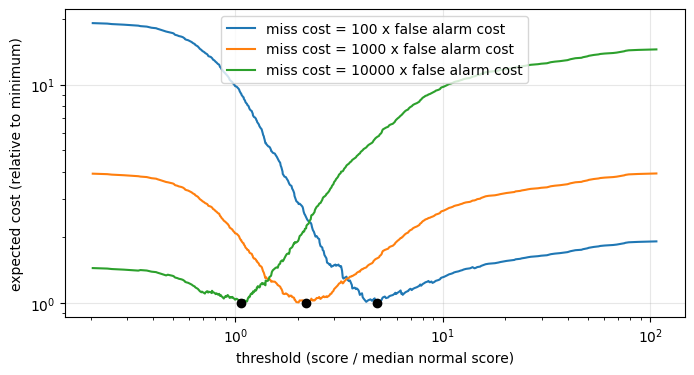

 cost_ratio  threshold   fpr  miss_rate
        100      4.838 0.012      0.397
       1000      2.192 0.115      0.140
      10000      1.059 0.476      0.021


In [57]:
# 誤報と見逃しのコストから、しきい値を決める
# 個体ごとにスコアの大きさが違うので、検証用の正常音の中央値で割ってそろえてから、全個体をまとめる
s_all = scores[BEST].copy()
for u in UNITS:
    s_all[meta.unit.values == u] /= np.median(s_all[rows_of("val", unit=u)])
te = rows_of("test"); y = meta.label.values[te]; s = s_all[te]
ths = np.quantile(s, np.linspace(0, 1, 400))
fpr = np.array([(s[y == 0] > t).mean() for t in ths]); fnr = np.array([(s[y == 1] <= t).mean() for t in ths])

P_ANOM = 0.001      # 1回の判定が異常である確率（仮定）
plt.figure(figsize=(8, 4))
cost_rows = []
for ratio in [100, 1000, 10000]:
    # 期待コスト = 誤報のコスト×誤報の確率 + 見逃しのコスト×見逃しの確率（誤報1回のコストを1とする）
    cost = (1 - P_ANOM) * fpr * 1 + P_ANOM * fnr * ratio
    i = cost.argmin()
    plt.plot(ths, cost / cost.min(), label=f"miss cost = {ratio} x false alarm cost")
    plt.plot(ths[i], 1, "ko")
    cost_rows.append(dict(cost_ratio=ratio, threshold=ths[i], fpr=fpr[i], miss_rate=fnr[i]))
plt.xscale("log"); plt.yscale("log"); plt.xlabel("threshold (score / median normal score)"); plt.ylabel("expected cost (relative to minimum)")
plt.legend(); plt.grid(alpha=0.3); plt.show()
print(pd.DataFrame(cost_rows).round(3).to_string(index=False))

結果の読み方

- 横軸のしきい値は、「正常音のスコアの中央値の何倍か」で表している 黒い点が、コストが最小になるしきい値である
- 見逃しのコストが誤報の100倍のとき、最適なしきい値は中央値の約5.5倍で、誤報率は1.0%、見逃し率は46%
  - 異常がまれなので、誤報を減らす方が全体のコストを下げる 見逃しが多くても、その方が得だという計算になる
- 1000倍のとき、しきい値は約2.3倍に下がり、誤報率8.8%、見逃し率17%
- 10000倍のとき、しきい値は約0.78倍で、誤報率は67% 正常音の3分の2に警報を出してでも、見逃しを避けるべきだ、という結論になる
- **最適なしきい値は、コストの比によって何倍も動く**
  - しきい値は、検知器の性能だけでは決まらない 「見逃すと何が起きるか」を現場の担当者と話し合って決めるものである
  - 誤報率67%という設定は、実際には運用できない その場合は、検知器を改良するか、別の種類のセンサを併用する

## しきい値の見直し

最初に決めたしきい値は、少ない検証用データから決めた仮の値である
モデルを公開した後の監視、段階的な切り替え（カナリア公開）といった運用の一般的な考え方は、「推論サービング」の章を参照
運用を始めたら、次の記録を取り、定期的に見直す

- **警報の記録**: いつ、スコアはいくつで、確認した結果は何だったか（本当の異常、誤報、原因不明）
- **正常時のスコアの分布**: 中央値や95%点が、週ごとにどう動いているか
- 誤報が多ければしきい値を上げる 本当の異常が低いスコアで起きていたら下げる
- 本当の異常の音が手に入ったら、必ず保存する 検知率を測れる貴重なデータである

<img src="https://class.west.sd.keio.ac.jp/dataai/text/asd-operation-cycle.png" width=660>

上の図は、設置した後に続く仕事の循環を示している 監視、警報、確認、記録、見直しを、止めずに回し続ける

## 正常の定義は時間とともに変わる

機械は、壊れていなくても少しずつ変わる
- 部品がなじむ、摩耗する、汚れがたまる、季節で気温が変わる
- 設置したときの「正常」から、音がゆっくり離れていく これを**経年変化**、あるいは概念ドリフト（concept drift）と呼ぶ
- 固定したモデルでは、正常な音のスコアが少しずつ上がり、やがて誤報が増える

<img src="https://class.west.sd.keio.ac.jp/dataai/text/asd-concept-drift.png" width=660>

上の図は、この様子を模式的に描いたものである
- 正常な音の位置（青）はゆっくり動き、固定したモデルが正常とみなす範囲（灰色）から外れていく
- 更新するモデル（橙）は、正常な音の動きを追いかける

対処は、**モデルを更新し続ける**ことである
ここでは、正常と判定した音を使って、正常の中心を少しずつ移していく方法を試す

実験の設定
- 正常音を時間順に並べたと考え、特徴量を、元の条件から `speed +3%` の条件へ、少しずつ移していく
- 固定したモデルと、更新するモデルで、正常音のスコアの推移を比べる
- 変化しきった後に異常音を入力し、検知できるかも比べる

    unit  far_fixed  far_updated  auc_fixed  auc_updated
 pump_00      0.200        0.167      0.784        0.808
 pump_02      0.406        0.130      0.866        0.820
 pump_04      0.150        0.083      0.792        0.917
 pump_06      0.177        0.161      0.660        0.699
valve_00      0.134        0.075      0.597        0.760
valve_02      0.111        0.056      0.779        0.833
valve_04      0.371        0.143      0.685        0.822
valve_06      0.317        0.183      0.614        0.645
mean: {'far_fixed': 0.233, 'far_updated': 0.125, 'auc_fixed': 0.722, 'auc_updated': 0.788}


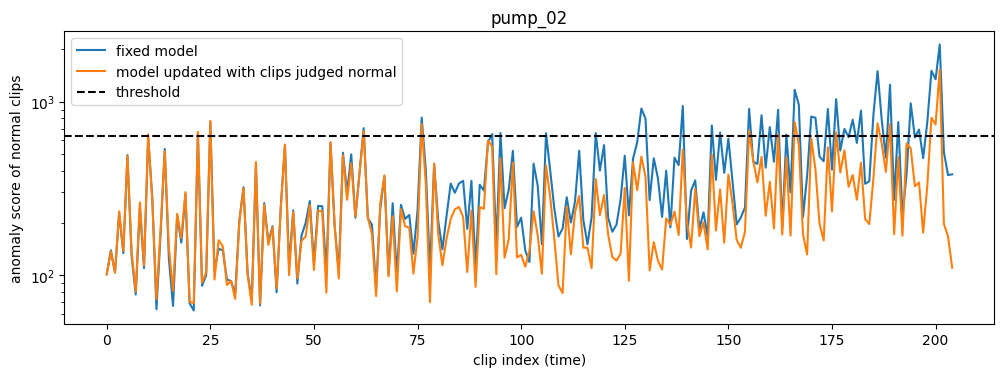

In [58]:
# 経年変化を模擬する: 正常な音がゆっくり変わっていくとき、固定したモデルと、更新するモデルを比べる
def drift_experiment(u, cond="speed +3%", beta=0.1, q=0.95, seed=SEED):
    rng = np.random.default_rng(seed)
    tr = rows_of("train", unit=u)
    seq = rng.permutation(np.r_[rows_of("val", unit=u), rows_of("test", unit=u)[meta.label.values[rows_of("test", unit=u)] == 0]])
    a = np.linspace(0, 1, len(seq))[:, None]
    Xt = X_stat[seq] + a * (X_shift[cond][seq] - X_stat[seq])      # 元の特徴量から、条件が変わった後の特徴量へ少しずつ移る
    score_fn = fit_maha(X_stat[tr])
    thr = np.quantile(score_fn(X_stat[rows_of("val", unit=u)]), q)
    s_fixed = score_fn(Xt)
    # 更新するモデル: 正常と判定したクリップを使い、正常の中心のずれを少しずつ追いかける
    delta = np.zeros(X_stat.shape[1]); s_adapt = []
    for x in Xt:
        s = score_fn((x - delta)[None])[0]
        s_adapt.append(s)
        if s < thr:
            delta = (1 - beta) * delta + beta * (x - X_stat[tr].mean(0))
    # 変化しきった後の異常音を、それぞれのモデルで検知できるか
    an = rows_of("test", unit=u)[meta.label.values[rows_of("test", unit=u)] == 1]
    tail = slice(len(seq) * 2 // 3, None)
    yy = np.r_[np.zeros(len(seq[tail])), np.ones(len(an))]
    auc_fixed = roc_auc_score(yy, np.r_[s_fixed[tail], score_fn(X_shift[cond][an])])
    auc_adapt = roc_auc_score(yy, np.r_[np.array(s_adapt)[tail], score_fn(X_shift[cond][an] - delta)])
    return s_fixed, np.array(s_adapt), thr, auc_fixed, auc_adapt

drift_rows = []
for uu in UNITS:
    sf_, sa_, th_, af_, aa_ = drift_experiment(uu)
    n3 = len(sf_) * 2 // 3
    drift_rows.append(dict(unit=uu, far_fixed=np.mean(sf_[n3:] > th_), far_updated=np.mean(sa_[n3:] > th_), auc_fixed=af_, auc_updated=aa_))
drift_df = pd.DataFrame(drift_rows)
print(drift_df.round(3).to_string(index=False))
print("mean:", drift_df.mean(numeric_only=True).round(3).to_dict())

u = drift_df.unit[drift_df.far_fixed.argmax()]      # 固定モデルの誤報が最も増えた個体を図にする
s_fixed, s_adapt, thr, auc_f, auc_a = drift_experiment(u)
plt.figure(figsize=(12, 3.8))
plt.plot(s_fixed, label="fixed model"); plt.plot(s_adapt, label="model updated with clips judged normal")
plt.axhline(thr, color="k", ls="--", label="threshold")
plt.yscale("log"); plt.title(u); plt.xlabel("clip index (time)"); plt.ylabel("anomaly score of normal clips"); plt.legend(); plt.show()

結果の読み方

- 表の `far_fixed` と `far_updated` は、変化の終盤（最後の1/3）での正常音の誤報率である
  - 固定したモデルでは、8個体の平均で0.233 設定した0.05の4倍以上に増える
  - 更新するモデルでは、平均0.125 半分近くに抑えられるが、0.05には戻らない
- 表の `auc_fixed` と `auc_updated` は、変化しきった後の正常音と異常音を分けられるかを表す
  - 固定したモデルの平均0.722に対し、更新するモデルは0.788
  - 正常の中心を追いかけることで、新しい条件での検知性能もある程度保たれる
  - ただし、すべての個体でよくなるわけではない（`pump_02` は0.866から0.820に下がる）
- 図は、固定したモデルの誤報が最も増えた個体である
  - 固定したモデル（青）のスコアは、時間とともに上がり続け、しきい値を超えることが増える
  - 更新するモデル（橙）のスコアは、それより低く保たれる

更新するモデルには、大きな落とし穴がある

- **ゆっくり進む故障も、「正常の変化」として取り込んでしまう**
  - 軸受の摩耗のように少しずつ進む異常は、経年変化と区別がつかない
  - 取り込み続けると、壊れる寸前の音まで「正常」になり、警報は最後まで出ない
- 更新を止める条件を決めておく
  - 設置時の基準からのずれの合計に上限を設け、超えたら人が確認する
  - 自動での更新はせず、保全作業の後など、正常だと確認できた時点でだけ更新する、という運用も多い
- 更新の前後のモデルと、そのときのデータを残しておく 後から「いつから変わったか」をたどれるようにするためである

経年変化と故障を、音だけで見分けることは難しい
最後は、**人が定期的に機械を確認する**ことと組み合わせるしかない
異常音検知は、人の点検を置き換えるものではなく、点検と点検の間を埋めるものだと考えるとよい

---

# まとめ

本テキストでは、機械の音から異常を見つける仕組みを、問題設定から運用まで通して作った

- **問題設定**
  - 異常の音は集まらず、未知の異常が来る だから、正常音だけで学習し、そこから外れたものを異常とする
  - スコアを作る部品と、しきい値を決める部品を分けて考える
- **音の見方**
  - 機械音は、回転数で決まる線と、欠陥が起こす衝撃でできている
  - 窓長とメル数は、見つけたい異常の性質に合わせて決める
  - 機械の知識で見る場所を絞る手法（エンベロープ解析）は狭く深く、データから学ぶ手法は広く浅い
- **手法の比較**（本テキストの実行結果）
  - 単純な統計量とマハラノビス距離が、平均AUC 0.799の堅実な基準になった
  - AutoEncoderの再構成誤差は、最初の実装では0.637〜0.673で、基準を下回った 異常も、別の機種の音も、復元できてしまう
    - 個体ごとにモデルを作り、音の性質に合ったスコアのまとめ方を選ぶと、基準を上回った 基準となる手法を公平に実装することは難しい
  - 個体を当てる補助タスクで学んだ埋め込みとk近傍法が、0.942で最もよかった
  - 学習なしの事前学習済みモデルは0.826〜0.831で、正常音が少ないときの有力な選択肢になる 個体のラベルで射影を足すと0.893まで上がった
  - 性能の高い識別型の手法ほど、条件の変化には敏感だった 検知の鋭さと、変化への強さは裏表である
  - mixupは、確信度のスコアには効いたが、埋め込みの距離には効かなかった 工夫が効くかどうかは、それが直す問題があるかどうかで決まる
  - AUCだけでなくpAUCを見る 平均だけでなく個体別に見る
- **現場に入れる**
  - 条件が変わると、誤報が急に増える 正規化、データ拡張、少数データでの適応を、変化の性質に応じて選ぶ
  - 誤報は、平滑化と連続検知で抑える 代わりに警報が遅れる
  - しきい値とモデルは、設置した後も見直し続ける

冒頭の言葉に戻る
AUCの数値を上げることが目的ではない
その数値が何を意味し、どこで崩れるかを理解して、現場で使える仕組みにすることが目的である

# 課題1（特徴量の設定）

バルブの音は突発音であり、標準の設定（`n_fft=1024`、`hop=512`）が最適とは限らない

1. 「実データで特徴量の設定を変える」のセルを参考に、`n_fft`、`hop`、`n_mels` の組合せを新たに3通り以上試し、バルブとポンプのAUCを表にまとめよ
2. 統計量に、帯域ごとの時間方向の最大値を加えた特徴量（384次元）を作り、同じ評価を行え
3. バルブで長い窓が有利になる理由を切り分けよ 本文では「周波数ビンが細かくなること」と「1フレームの中で長い時間が平均されること」の2つを挙げた 次の2つを実装して比べること
   - 長い窓（`n_fft=4096`）のまま、メル数を32に減らして周波数方向を粗くする
   - 標準の窓（`n_fft=1024`）のまま、対数メルを時間方向に4フレームずつ平均してから統計量を計算する
4. ポンプとバルブで最適な設定が異なるかを述べ、その理由を第2部の内容（定常音と突発音、周波数分解能と時間分解能）と上の結果に基づいて考察せよ 断定できない点は、そう書くこと

# 課題2（AutoEncoderの改良）

本テキストのAutoEncoderは、バルブでほとんど検知できなかった

1. 1つの音から得られる309個の再構成誤差のまとめ方として、平均と最大値のほかに、上位10%の平均を実装し、AUCを比べよ
2. 全結合のAutoEncoderを、畳み込みによるAutoEncoder（入力は128×64の区画）に置き換え、AUCを比べよ
3. 「再構成誤差の地図」を、改良の前後で同じ異常音について描き、何が変わったかを述べよ
4. それでも識別型の手法に及ばない場合、その理由を「なぜ異常も再構成できてしまうのか」の節に基づいて考察せよ

# 課題3（しきい値と誤報）

1. 「AST emb+Mahalanobis」のスコアについて、検証用データの90%点、95%点、99%点をしきい値にしたときの、テストでの誤報率と検知率を、個体別に表にまとめよ
2. 設定した誤報率と、テストで実際に得られた誤報率のずれを個体ごとに求め、ずれが生じる理由を検証用データの数と関係づけて説明せよ
3. 「誤報は1時間に1回まで」という要件を、窓ごとの判定と連続検知で満たすには、窓のしきい値とkをどう決めればよいか 「判定の規則を比べる」のセルを拡張して、要件を満たす設定を1つ示し、そのときの検知率を報告せよ

# 課題4（実践: 自分のデータまたは指定データで手法を改良する）

次のどちらかのデータを使い、異常音検知の仕組みを自分で改良して、結果を報告せよ

- **自分で用意した音**: 身の回りの機械の正常音と、安全な方法で作った異常音（「自分で録音したデータで試す」の節の注意を守ること）
- **指定データ**: DCASE 2020 Task 2 開発用データのうち、本テキストで使っていない機種（`fan`、`slider`、`ToyCar`、`ToyConveyor` のいずれか `MACHINES` を書き換えれば取得できる）

要件

1. データの説明を書け 自分の音の場合は、機械、マイク、サンプリング周波数、距離、クリップの長さと数、異常の作り方を記すこと
2. 基準として「統計量＋マハラノビス距離」のAUCとpAUCを測れ
3. 基準を上回ることを目指して、改良を2つ以上試せ 例: 特徴量の設定の変更、別の手法（識別型、事前学習済みモデル）への差し替え、スコアの組合せ、データ拡張、正規化
4. 試した手法すべてについて、AUCとpAUCを1つの表にまとめよ 改良が効かなかったものも省かずに載せること
5. 最もよかった手法について、検証用の正常音からしきい値を決め、テストでの誤報率と検知率を報告せよ
6. 異常と判定された音を1つ選び、根拠の可視化（再構成誤差の地図、または遮蔽による感度分析）を行い、何に反応したと考えられるかを述べよ
7. 考察を書け 何が効き、何が効かなかったか、それはなぜか この仕組みを実際にその機械の監視に使うとしたら、何が足りないか

# 参考文献

- Koizumi, Y. et al. (2020). "Description and Discussion on DCASE2020 Challenge Task2: Unsupervised Anomalous Sound Detection for Machine Condition Monitoring." DCASE Workshop 2020.
- DCASE 2020 Challenge Task 2 Development Dataset. https://zenodo.org/records/3678171
- Purohit, H. et al. (2019). "MIMII Dataset: Sound Dataset for Malfunctioning Industrial Machine Investigation and Inspection." DCASE Workshop 2019.
- Koizumi, Y. et al. (2019). "ToyADMOS: A Dataset of Miniature-Machine Operating Sounds for Anomalous Sound Detection." WASPAA 2019.
- Kawaguchi, Y. et al. (2021). "Description and Discussion on DCASE 2021 Challenge Task 2: Unsupervised Anomalous Sound Detection for Machine Condition Monitoring under Domain Shifted Conditions." DCASE Workshop 2021.
- Giri, R. et al. (2020). "Self-Supervised Classification for Detecting Anomalous Sounds." DCASE Workshop 2020.
- Gong, Y., Chung, Y.-A., Glass, J. (2021). "AST: Audio Spectrogram Transformer." Interspeech 2021.
- Gemmeke, J. F. et al. (2017). "Audio Set: An Ontology and Human-Labeled Dataset for Audio Events." ICASSP 2017.
- Chandola, V., Banerjee, A., Kumar, V. (2009). "Anomaly Detection: A Survey." ACM Computing Surveys.
- Liu, F. T., Ting, K. M., Zhou, Z.-H. (2008). "Isolation Forest." ICDM 2008.
- Ledoit, O., Wolf, M. (2004). "A Well-Conditioned Estimator for Large-Dimensional Covariance Matrices." Journal of Multivariate Analysis.
- Zhang, H. et al. (2018). "mixup: Beyond Empirical Risk Minimization." ICLR 2018.
- McClish, D. K. (1989). "Analyzing a Portion of the ROC Curve." Medical Decision Making.
- Randall, R. B., Antoni, J. (2011). "Rolling Element Bearing Diagnostics - A Tutorial." Mechanical Systems and Signal Processing.